## CLASSIFICATION COMPARISON

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define  root directories for the models
BASE_MODEL_DIR = "/final-data-base-results"
MC_DROPOUT_DIR = "/dropout-results"

# Define the exact JSON filenames based on  script's output
ID_METRICS_FILE = "summary_results.json" # Replace with actual prefix if different
OOD_PATIENTS = ["chb22", "chb23", "chb24"]

def load_and_format_metrics(json_path):
    """Loads JSON metrics and formats them as 'Mean ± Std' in percentages."""
    if not os.path.exists(json_path):
        print(f"Warning: File not found - {json_path}")
        return {}
        
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Multiply by 100 and format to 2 decimal places
    formatted = {
        "AUROC (%)": f"{data['final_mean_AUROC']*100:.2f} ± {data['final_AUROC_std']*100:.2f}",
        "F1-Score (%)": f"{data['final_mean_F1-score']*100:.2f} ± {data['final_F1-score_std']*100:.2f}",
        "Sensitivity (%)": f"{data['final_mean_Sensitivity']*100:.2f} ± {data['final_Sensitivity_std']*100:.2f}",
        "Specificity (%)": f"{data['final_Specificity']*100:.2f} ± {data['final_Specificity_std']*100:.2f}",
        "Balanced Acc (%)": f"{data['final_Balanced Accuracy']*100:.2f} ± {data['final_Balanced Accuracy_std']*100:.2f}"
    }
    return formatted

def build_metrics_tables():
    id_rows = []
    ood_rows = []
    
    models = {
        "Baseline": BASE_MODEL_DIR,
        "MC-Dropout": MC_DROPOUT_DIR
    }
    
    for model_name, base_path in models.items():
        # 1. Process ID Data
        id_json_path = os.path.join(base_path, "save_conf_metrics", ID_METRICS_FILE)
        id_metrics = load_and_format_metrics(id_json_path)
        if id_metrics:
            id_metrics["Model"] = model_name
            id_metrics["Evaluation"] = "ID (10-Fold)"
            id_rows.append(id_metrics)
            
        # 2. Process OOD Data
        for patient in OOD_PATIENTS:
            # e.g., summary_results_chb22.json
            ood_json_name = f"{ID_METRICS_FILE.replace('.json', '')}_{patient}.json" 
            ood_json_path = os.path.join(base_path, "save_conf_metrics_ood", ood_json_name)
            
            ood_metrics = load_and_format_metrics(ood_json_path)
            if ood_metrics:
                ood_metrics["Model"] = model_name
                ood_metrics["Evaluation"] = f"{patient}" # Simplified evaluation label for the OOD table
                ood_rows.append(ood_metrics)

    # Define column order
    cols = ["Model", "Evaluation", "AUROC (%)", "F1-Score (%)", "Sensitivity (%)", "Specificity (%)", "Balanced Acc (%)"]
    
    # Create DataFrames
    id_df = pd.DataFrame(id_rows)[cols] if id_rows else pd.DataFrame(columns=cols)
    ood_df = pd.DataFrame(ood_rows)[cols] if ood_rows else pd.DataFrame(columns=cols)
    
    # Optional: Sort OOD table by Patient then Model to make comparisons easier
    if not ood_df.empty:
        ood_df = ood_df.sort_values(by=["Evaluation", "Model"]).reset_index(drop=True)
    
    return id_df, ood_df

# Run and display the tables
id_metrics_df, ood_metrics_df = build_metrics_tables()

print("="*80)
print("TABLE 1: IN-DISTRIBUTION (ID) CLASSIFICATION PERFORMANCE")
print("="*80)
print(id_metrics_df.to_markdown(index=False))
print("\n")

print("="*80)
print("TABLE 2: OUT-OF-DISTRIBUTION (OOD) CLASSIFICATION PERFORMANCE")
print("="*80)
print(ood_metrics_df.to_markdown(index=False))

TABLE 1: IN-DISTRIBUTION (ID) CLASSIFICATION PERFORMANCE
| Model      | Evaluation   | AUROC (%)    | F1-Score (%)   | Sensitivity (%)   | Specificity (%)   | Balanced Acc (%)   |
|:-----------|:-------------|:-------------|:---------------|:------------------|:------------------|:-------------------|
| Baseline   | ID (10-Fold) | 95.26 ± 0.62 | 84.78 ± 1.67   | 84.78 ± 1.67      | 92.39 ± 0.83      | 85.84 ± 1.55       |
| MC-Dropout | ID (10-Fold) | 91.39 ± 0.56 | 76.75 ± 1.30   | 76.75 ± 1.30      | 88.37 ± 0.65      | 78.47 ± 1.14       |


TABLE 2: OUT-OF-DISTRIBUTION (OOD) CLASSIFICATION PERFORMANCE
| Model      | Evaluation   | AUROC (%)    | F1-Score (%)   | Sensitivity (%)   | Specificity (%)   | Balanced Acc (%)   |
|:-----------|:-------------|:-------------|:---------------|:------------------|:------------------|:-------------------|
| Baseline   | chb22        | 73.51 ± 2.79 | 54.86 ± 2.53   | 54.86 ± 2.53      | 77.43 ± 1.27      | 59.12 ± 2.29       |
| MC-Dropout | chb

## Confusion matrix

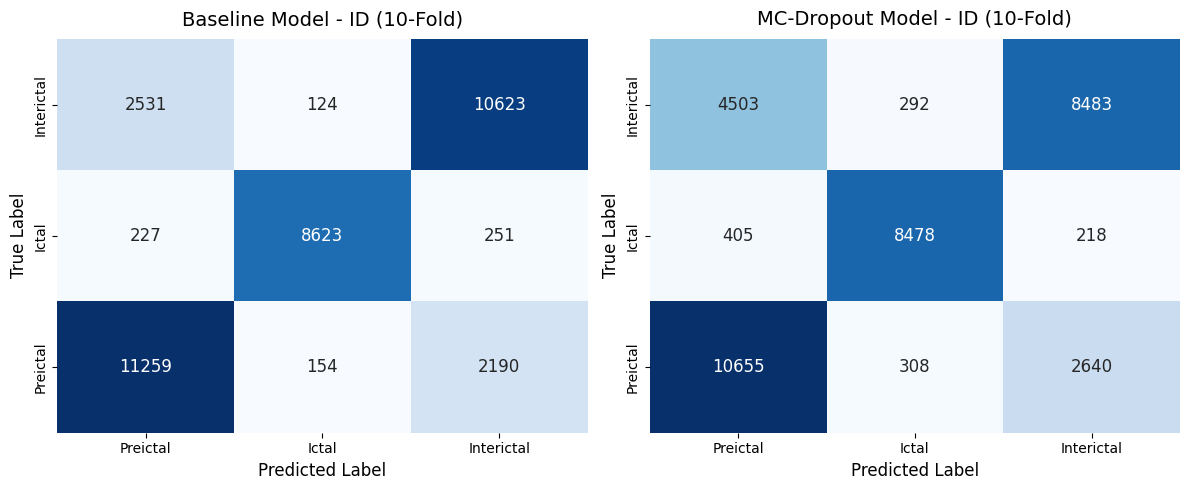

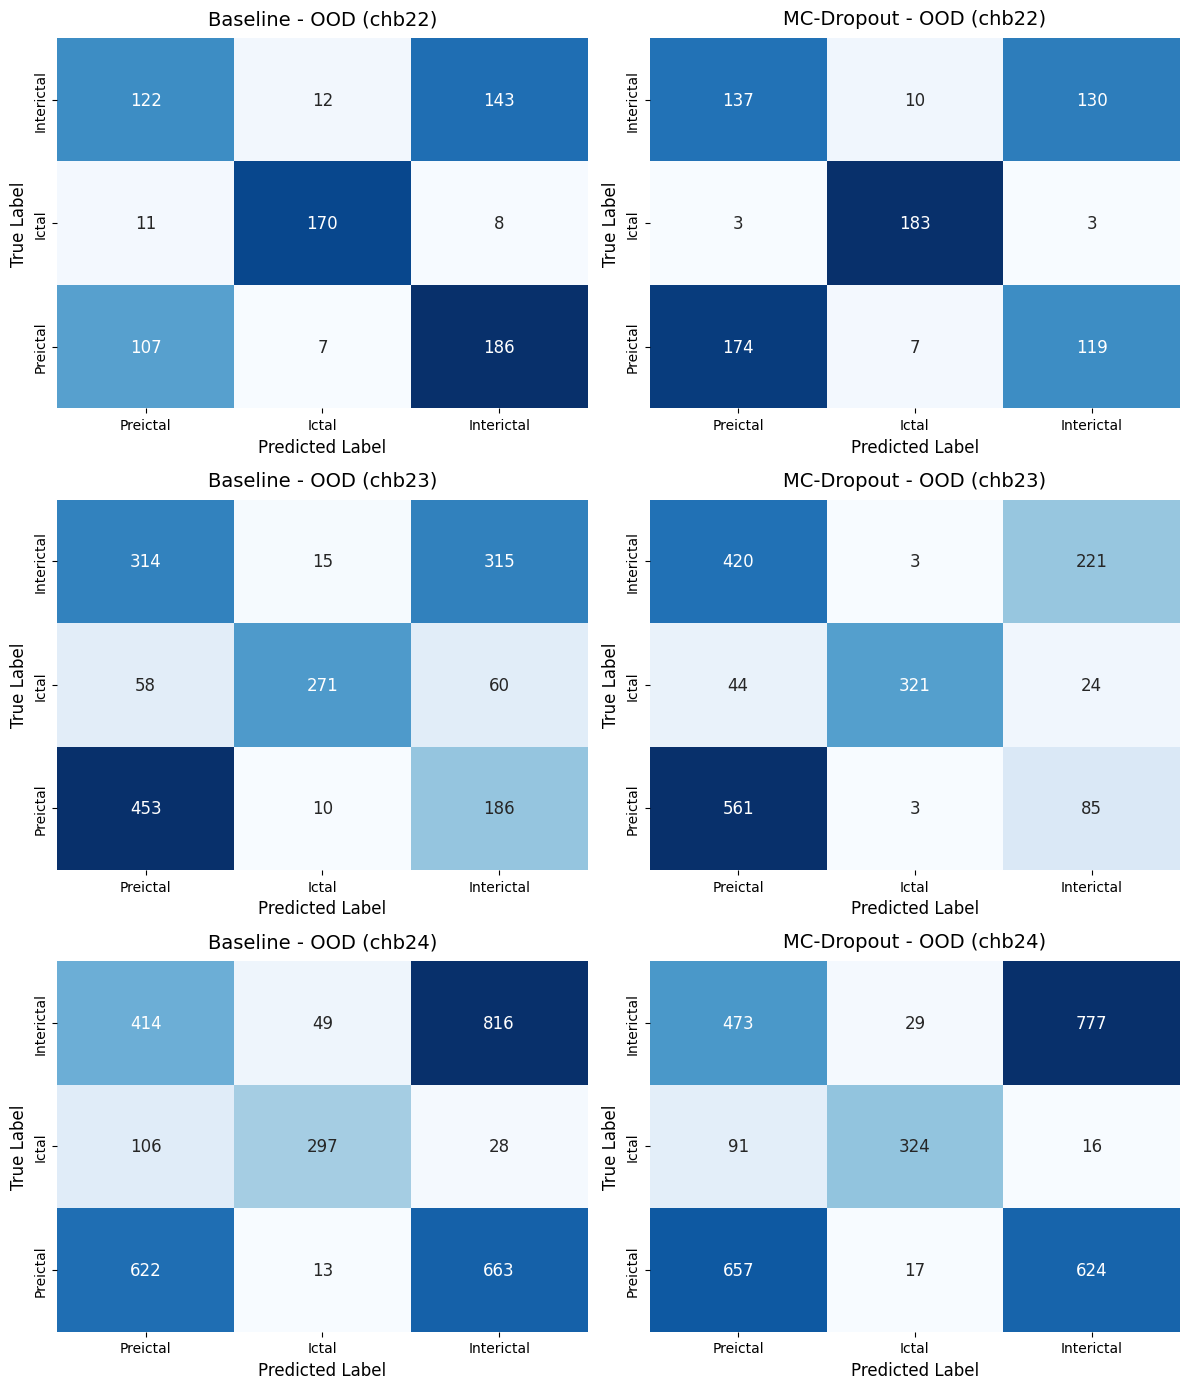

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define  root directories for the models
BASE_MODEL_DIR = "/final-data-base-results"
MC_DROPOUT_DIR = "/dropout-results"

# OOD Patients
OOD_PATIENTS = ["chb22", "chb23", "chb24"]

# File name
ID_CM_FILE = "summary_conf_matrix.npy"

# Desired display order
X_LABELS = ['Preictal', 'Ictal', 'Interictal']
Y_LABELS = ['Interictal', 'Ictal', 'Preictal']

# Row order for display:
# actual class indices are [0=Preictal, 1=Ictal, 2=Interictal]
# we want rows shown as [2, 1, 0]
ROW_ORDER = [2, 1, 0]

# Column order stays as [0, 1, 2]
COL_ORDER = [0, 1, 2]


def normalize_matrix_exact(cm):
    """
    Normalizes a 10x aggregated confusion matrix to the exact 1x scale.
    Uses the Largest Remainder Method per row to ensure no samples are lost.
    """
    cm_norm = np.zeros_like(cm, dtype=int)
    for i in range(cm.shape[0]):
        true_row_sum = cm[i].sum() // 10
        target = cm[i] / 10.0
        row_norm = np.floor(target).astype(int)
        remainder = true_row_sum - row_norm.sum()

        if remainder > 0:
            fractions = target - row_norm
            indices = np.argsort(fractions)[::-1]
            for j in range(int(remainder)):
                row_norm[indices[j]] += 1

        cm_norm[i] = row_norm
    return cm_norm


def plot_heatmap(cm, ax, title):
    """Plot confusion matrix with custom row/column ordering."""
    cm_disp = cm[np.ix_(ROW_ORDER, COL_ORDER)]

    sns.heatmap(
        cm_disp,
        annot=True,
        fmt='g',
        cmap='Blues',
        ax=ax,
        xticklabels=X_LABELS,
        yticklabels=Y_LABELS,
        cbar=False,
        annot_kws={"size": 12}
    )
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)


def plot_id_confusion_matrices():
    """Plots ID matrices side-by-side (Baseline vs MC-Dropout)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    base_cm_path = os.path.join(BASE_MODEL_DIR, "save_conf_metrics", ID_CM_FILE)
    mc_cm_path = os.path.join(MC_DROPOUT_DIR, "save_conf_metrics", ID_CM_FILE)

    if os.path.exists(base_cm_path):
        cm_base = np.load(base_cm_path)
        plot_heatmap(cm_base, axes[0], "Baseline Model - ID (10-Fold)")

    if os.path.exists(mc_cm_path):
        cm_mc = np.load(mc_cm_path)
        plot_heatmap(cm_mc, axes[1], "MC-Dropout Model - ID (10-Fold)")

    plt.tight_layout()
    plt.show()


def plot_ood_confusion_matrices():
    """Plots OOD matrices in a grid (Rows: Patients, Cols: Models)."""
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))

    for i, patient in enumerate(OOD_PATIENTS):
        ood_cm_name = f"{ID_CM_FILE.replace('.npy', '')}_{patient}.npy"
        base_cm_path = os.path.join(BASE_MODEL_DIR, "save_conf_metrics_ood", ood_cm_name)
        mc_cm_path = os.path.join(MC_DROPOUT_DIR, "save_conf_metrics_ood", ood_cm_name)

        if os.path.exists(base_cm_path):
            cm_base = np.load(base_cm_path)
            cm_base = normalize_matrix_exact(cm_base)
            plot_heatmap(cm_base, axes[i, 0], f"Baseline - OOD ({patient})")

        if os.path.exists(mc_cm_path):
            cm_mc = np.load(mc_cm_path)
            cm_mc = normalize_matrix_exact(cm_mc)
            plot_heatmap(cm_mc, axes[i, 1], f"MC-Dropout - OOD ({patient})")

    plt.tight_layout()
    plt.show()


plot_id_confusion_matrices()
plot_ood_confusion_matrices()

## UNCERTAINTY COMPARISON

In [ ]:
import os
import json
import pandas as pd

# Define  root directories
BASE_MODEL_DIR = "/final-data-base-results"
MC_DROPOUT_DIR = "/dropout-results"

# Define filenames
ID_UNC_FILE = "summary_unc_results.json"
OOD_PATIENTS = ["chb22", "chb23", "chb24"]

def load_and_format_unc_metrics(json_path):
    """Loads JSON metrics and formats them as 'Mean ± Std' to 3 decimal places."""
    if not os.path.exists(json_path):
        return {}
        
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    formatted = {
        "ECE (↓)": f"{data['final_mean_ECE']:.3f} ± {data['final_ECE_std']:.3f}",
        "NLL (↓)": f"{data['final_mean_NLL']:.3f} ± {data['final_NLL_std']:.3f}",
        "AURC (↓)": f"{data['final_mean_AURC']:.3f} ± {data['final_AURC_std']:.3f}",
        "Total Ent.": f"{data['final_mean_Total_Entropy']:.3f} ± {data['final_Total_Entropy_std']:.3f}",
        "Aleatoric Ent.": f"{data['final_mean_Aleatoric_Entropy']:.3f} ± {data['final_Aleatoric_Entropy_std']:.3f}",
        "Epistemic Ent.": f"{data['final_mean_Epistemic_Entropy']:.3f} ± {data['final_Epistemic_Entropy_std']:.3f}"
    }
    return formatted

def build_uncertainty_tables():
    id_rows, ood_rows = [], []
    models = {"Baseline": BASE_MODEL_DIR, "MC-Dropout": MC_DROPOUT_DIR}
    
    for model_name, base_path in models.items():
        # 1. Process ID Data
        id_json_path = os.path.join(base_path, "save_unc_metrics", ID_UNC_FILE)
        id_metrics = load_and_format_unc_metrics(id_json_path)
        if id_metrics:
            id_metrics["Model"] = model_name
            id_metrics["Evaluation"] = "ID (10-Fold)"
            id_rows.append(id_metrics)
            
        # 2. Process OOD Data
        for patient in OOD_PATIENTS:
            ood_json_name = f"{ID_UNC_FILE.replace('.json', '')}_{patient}.json" 
            ood_json_path = os.path.join(base_path, "save_unc_metrics_ood", ood_json_name)
            ood_metrics = load_and_format_unc_metrics(ood_json_path)
            if ood_metrics:
                ood_metrics["Model"] = model_name
                ood_metrics["Evaluation"] = patient
                ood_rows.append(ood_metrics)

    cols = ["Model", "Evaluation", "ECE (↓)", "NLL (↓)", "AURC (↓)", "Total Ent.", "Aleatoric Ent.", "Epistemic Ent."]
    
    id_df = pd.DataFrame(id_rows)[cols] if id_rows else pd.DataFrame(columns=cols)
    ood_df = pd.DataFrame(ood_rows)[cols] if ood_rows else pd.DataFrame(columns=cols)
    
    if not ood_df.empty:
        ood_df = ood_df.sort_values(by=["Evaluation", "Model"]).reset_index(drop=True)
    
    return id_df, ood_df

id_unc_df, ood_unc_df = build_uncertainty_tables()

print("="*100)
print("TABLE 3: IN-DISTRIBUTION (ID) UNCERTAINTY & CALIBRATION")
print("="*100)
print(id_unc_df.to_markdown(index=False))
print("\n")

print("="*100)
print("TABLE 4: OUT-OF-DISTRIBUTION (OOD) UNCERTAINTY & CALIBRATION")
print("="*100)
print(ood_unc_df.to_markdown(index=False))

TABLE 3: IN-DISTRIBUTION (ID) UNCERTAINTY & CALIBRATION
| Model      | Evaluation   | ECE (↓)       | NLL (↓)       | AURC (↓)      | Total Ent.    | Aleatoric Ent.   | Epistemic Ent.   |
|:-----------|:-------------|:--------------|:--------------|:--------------|:--------------|:-----------------|:-----------------|
| Baseline   | ID (10-Fold) | 0.022 ± 0.006 | 0.411 ± 0.018 | 0.045 ± 0.006 | 0.298 ± 0.040 | 0.298 ± 0.040    | 0.000 ± 0.000    |
| MC-Dropout | ID (10-Fold) | 0.038 ± 0.011 | 0.496 ± 0.016 | 0.085 ± 0.006 | 0.536 ± 0.022 | 0.486 ± 0.026    | 0.050 ± 0.004    |


TABLE 4: OUT-OF-DISTRIBUTION (OOD) UNCERTAINTY & CALIBRATION
| Model      | Evaluation   | ECE (↓)       | NLL (↓)       | AURC (↓)      | Total Ent.    | Aleatoric Ent.   | Epistemic Ent.   |
|:-----------|:-------------|:--------------|:--------------|:--------------|:--------------|:-----------------|:-----------------|
| Baseline   | chb22        | 0.309 ± 0.032 | 1.533 ± 0.257 | 0.358 ± 0.068 | 0.328 ± 0.0

Found 10 files matching '*per_sample_data.npz' in save_unc_metrics
Found 10 files matching '*per_sample_data.npz' in save_unc_metrics


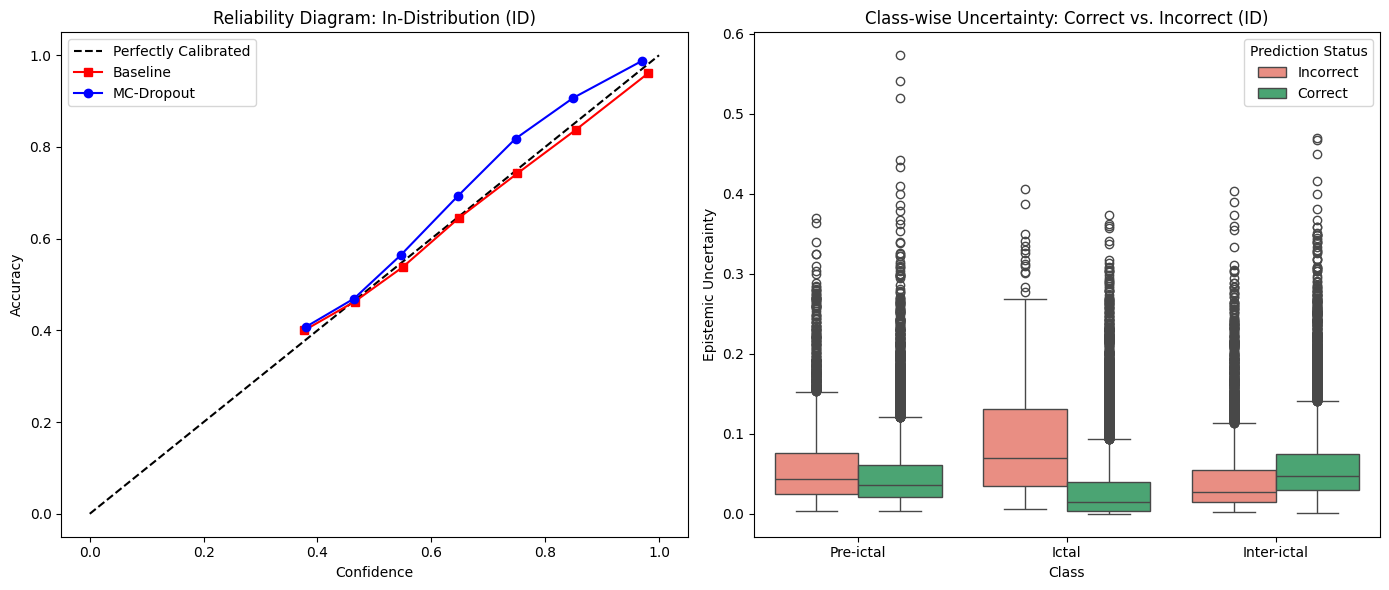

Found 10 files matching '*chb22*per_sample_data.npz' in save_unc_metrics_ood
Found 10 files matching '*chb22*per_sample_data.npz' in save_unc_metrics_ood
Found 10 files matching '*chb23*per_sample_data.npz' in save_unc_metrics_ood
Found 10 files matching '*chb23*per_sample_data.npz' in save_unc_metrics_ood
Found 10 files matching '*chb24*per_sample_data.npz' in save_unc_metrics_ood
Found 10 files matching '*chb24*per_sample_data.npz' in save_unc_metrics_ood


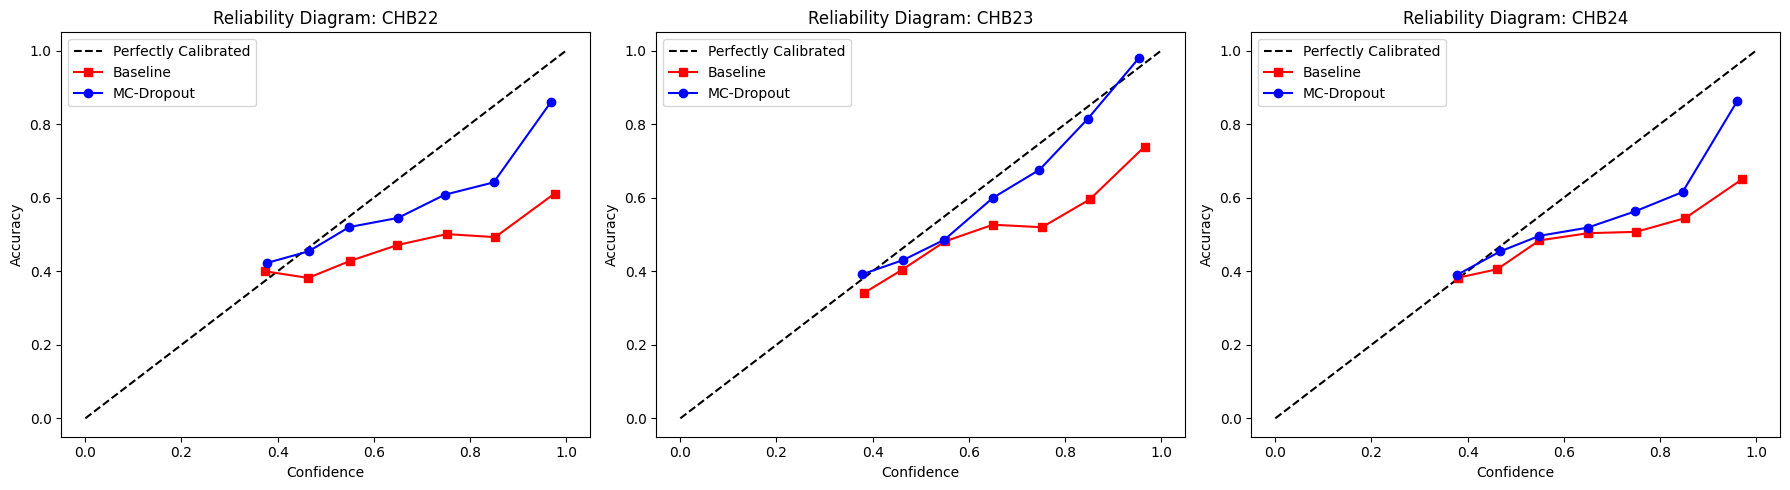

Found 10 files matching '*chb22*per_sample_data.npz' in save_unc_metrics_ood
Found 10 files matching '*chb23*per_sample_data.npz' in save_unc_metrics_ood
Found 10 files matching '*chb24*per_sample_data.npz' in save_unc_metrics_ood


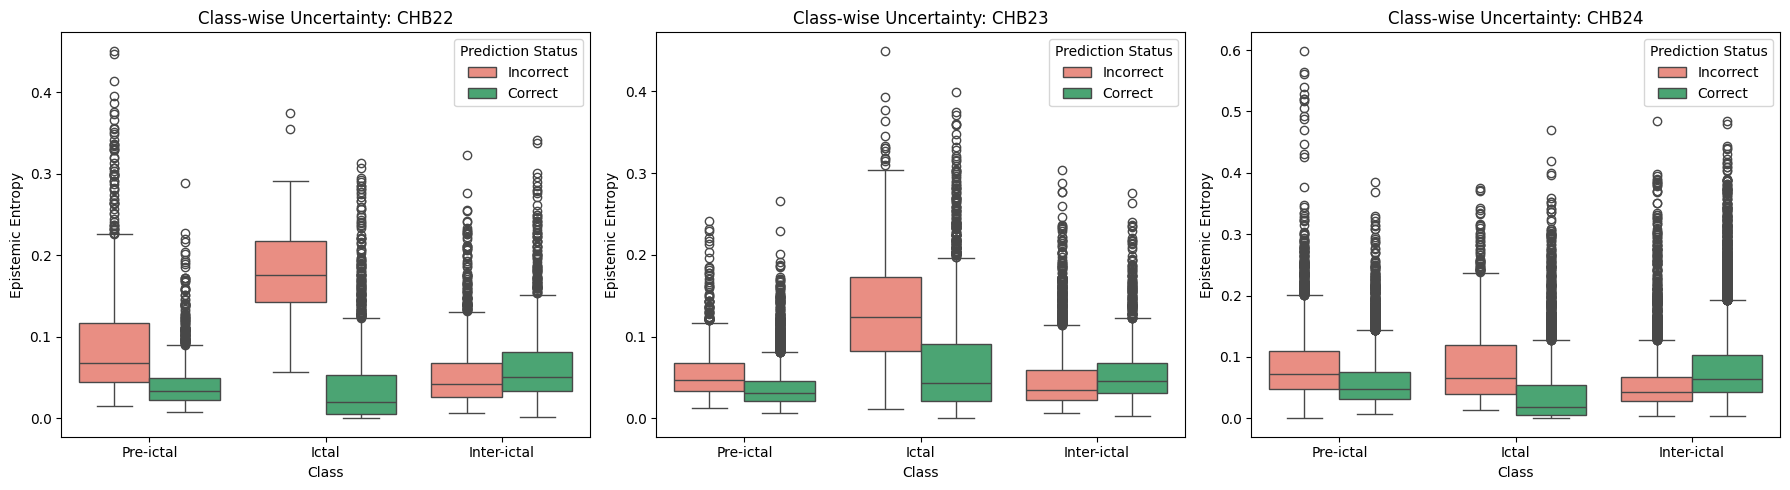

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define root directories
BASE_MODEL_DIR = "/final-data-base-results"
MC_DROPOUT_DIR = "/dropout-results"
OOD_PATIENTS = ["chb22", "chb23", "chb24"]
CLASS_NAMES = {0: "Pre-ictal", 1: "Ictal", 2: "Inter-ictal"}

def aggregate_npz_data(directory, file_pattern):
    # Finds and concatenates npz files, extracting relevant metrics
    search_path = os.path.join(directory, "**", file_pattern)
    files = glob.glob(search_path, recursive=True)
    
    if not files:
        print(f"Warning: No files found matching {search_path}")
        return None
        
    print(f"Found {len(files)} files matching '{file_pattern}' in {os.path.basename(directory)}")
    
    all_confidence, all_is_correct, all_epistemic, all_true_labels = [], [], [], []
    
    for f in files:
        with np.load(f) as data:
            all_confidence.extend(data['confidence'])
            all_is_correct.extend(data['is_correct'])
            all_true_labels.extend(data['true_labels'])
            if 'epistemic_entropy' in data:
                all_epistemic.extend(data['epistemic_entropy'])
                
    return {
        'confidence': np.array(all_confidence),
        'is_correct': np.array(all_is_correct),
        'true_labels': np.array(all_true_labels),
        'epistemic_entropy': np.array(all_epistemic) if all_epistemic else None
    }

def calc_calibration_curve(y_true, y_prob, n_bins=10):
    # Calculates accuracy and confidence for binning in reliability diagrams
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    
    # Ensure exactly 1.0 falls into the last bin
    binids = np.clip(binids, 0, n_bins - 1)
    
    bin_accs, bin_confs = [], []
    for b in range(n_bins):
        mask = binids == b
        if np.any(mask):
            bin_accs.append(y_true[mask].mean())
            bin_confs.append(y_prob[mask].mean())
    return np.array(bin_accs), np.array(bin_confs)
    
def plot_id_metrics():
    # Plots ID Reliability Diagram and Class-wise Epistemic Uncertainty Boxplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    base_id = aggregate_npz_data(os.path.join(BASE_MODEL_DIR, "save_unc_metrics"), "*per_sample_data.npz")
    mc_id = aggregate_npz_data(os.path.join(MC_DROPOUT_DIR, "save_unc_metrics"), "*per_sample_data.npz")
    
    # Ax 0: Reliability Diagram
    axes[0].plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
    if base_id:
        acc, conf = calc_calibration_curve(base_id['is_correct'], base_id['confidence'])
        axes[0].plot(conf, acc, 's-', label="Baseline", color="red")
    if mc_id:
        acc, conf = calc_calibration_curve(mc_id['is_correct'], mc_id['confidence'])
        axes[0].plot(conf, acc, 'o-', label="MC-Dropout", color="blue")
        
    axes[0].set_title("Reliability Diagram: In-Distribution (ID)")
    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    
    # Ax 1: Epistemic Uncertainty Boxplot
    if mc_id and mc_id['epistemic_entropy'] is not None:
        data_list = []
        for ent, corr, label in zip(mc_id['epistemic_entropy'], mc_id['is_correct'], mc_id['true_labels']):
            data_list.append({
                "Epistemic Entropy": ent, 
                "Prediction": "Correct" if corr else "Incorrect", 
                "Class": CLASS_NAMES.get(label, "Unknown")
            })
        df_id = pd.DataFrame(data_list)
        sns.boxplot(data=df_id, x="Class", y="Epistemic Entropy",hue_order=["Incorrect", "Correct"], hue="Prediction", palette={"Correct": "mediumseagreen", "Incorrect": "salmon"}, ax=axes[1])
        axes[1].set_title("Class-wise Uncertainty: Correct vs. Incorrect (ID)")
        axes[1].set_ylabel("Epistemic Uncertainty")
        axes[1].legend(title="Prediction Status")

    plt.tight_layout()
    plt.show()

def plot_ood_reliability_diagrams():
    # Plots Reliability Diagram for each OOD patient separately (1x3 layout)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, pat in enumerate(OOD_PATIENTS):
        pat_pattern = f"*{pat}*per_sample_data.npz"
        b_data = aggregate_npz_data(os.path.join(BASE_MODEL_DIR, "save_unc_metrics_ood"), pat_pattern)
        m_data = aggregate_npz_data(os.path.join(MC_DROPOUT_DIR, "save_unc_metrics_ood"), pat_pattern)
        
        axes[idx].plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
        if b_data:
            acc, conf = calc_calibration_curve(b_data['is_correct'], b_data['confidence'])
            axes[idx].plot(conf, acc, 's-', label="Baseline", color="red")
        if m_data:
            acc, conf = calc_calibration_curve(m_data['is_correct'], m_data['confidence'])
            axes[idx].plot(conf, acc, 'o-', label="MC-Dropout", color="blue")

        axes[idx].set_title(f"Reliability Diagram: {pat.upper()}")
        axes[idx].set_xlabel("Confidence")
        axes[idx].set_ylabel("Accuracy")
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

def plot_ood_epistemic_uncertainty():
    # Plots Epistemic Uncertainty Boxplot for each OOD patient separately (1x3 layout)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, pat in enumerate(OOD_PATIENTS):
        pat_pattern = f"*{pat}*per_sample_data.npz"
        m_data = aggregate_npz_data(os.path.join(MC_DROPOUT_DIR, "save_unc_metrics_ood"), pat_pattern)

        if m_data and m_data['epistemic_entropy'] is not None:
            data_list = []
            for ent, corr, label in zip(m_data['epistemic_entropy'], m_data['is_correct'], m_data['true_labels']):
                data_list.append({
                    "Epistemic Entropy": ent, 
                    "Prediction": "Correct" if corr else "Incorrect", 
                    "Class": CLASS_NAMES.get(label, "Unknown")
                })
            df_ood = pd.DataFrame(data_list)
            if not df_ood.empty:
                sns.boxplot(data=df_ood, x="Class", y="Epistemic Entropy", hue="Prediction", hue_order=["Incorrect", "Correct"], palette={"Correct": "mediumseagreen", "Incorrect": "salmon"}, ax=axes[idx])
                
        axes[idx].set_title(f"Class-wise Uncertainty: {pat.upper()}")
        axes[idx].set_ylabel("Epistemic Entropy")
        axes[idx].set_xlabel("Class")
        axes[idx].legend(title="Prediction Status")

    plt.tight_layout()
    plt.show()

# Execute Plots
plot_id_metrics()
plot_ood_reliability_diagrams()
plot_ood_epistemic_uncertainty()

## Defining optimal Epistemic Threshold

Found 10 ID files. Concatenating data...
Total ID Samples: 35982
Correct ID Samples Used for Threshold: 27616
Optimal Epistemic Threshold (95th Percentile): 0.1483899914


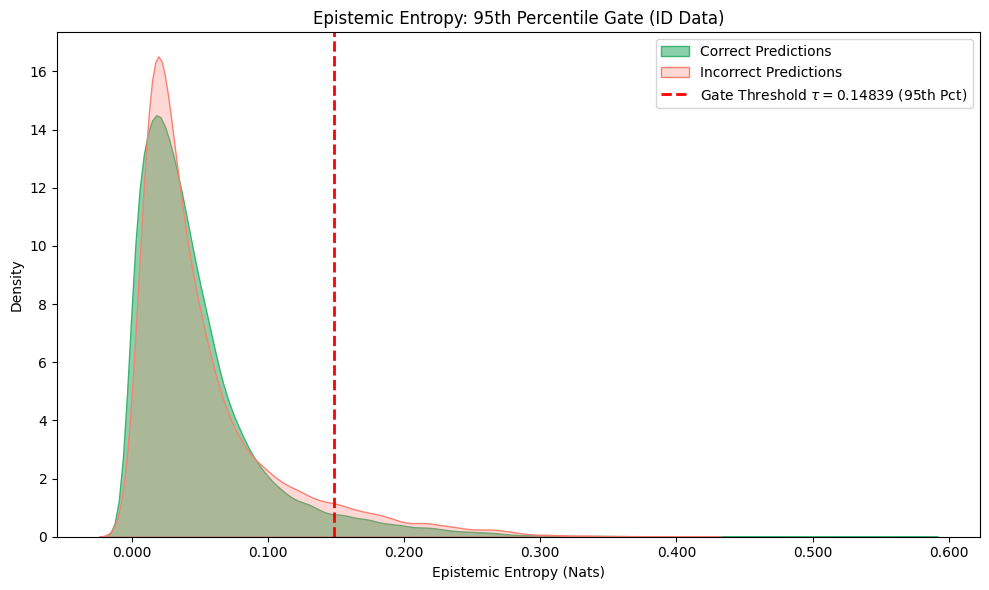

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def define_percentile_epistemic_threshold(base_dir="save_unc_metrics", target_percentile=95):
    """
    Concatenates ID data across all folds, isolates CORRECT predictions, 
    and calculates the specified percentile threshold for epistemic entropy.
    """
    search_pattern = os.path.join(base_dir, "fold_*", "per_sample_data.npz")
    files = glob.glob(search_pattern)
    
    if not files:
        raise FileNotFoundError(f"No ID files found matching {search_pattern}")
        
    print(f"Found {len(files)} ID files. Concatenating data...")
    
    all_is_correct, all_epistemic = [], []
    
    # Load and concatenate (Enforcing float64 for maximum precision)
    for f in files:
        with np.load(f) as data:
            all_is_correct.append(data['is_correct'])
            all_epistemic.append(data['epistemic_entropy'].astype(np.float64))
            
    is_correct = np.concatenate(all_is_correct)
    epistemic = np.concatenate(all_epistemic)
    
    # Isolate only the correct predictions
    correct_epistemic = epistemic[is_correct]
    
    # Calculate the exact percentile
    best_tau = np.percentile(correct_epistemic, target_percentile)
    
    print(f"Total ID Samples: {len(epistemic)}")
    print(f"Correct ID Samples Used for Threshold: {len(correct_epistemic)}")
    print(f"Optimal Epistemic Threshold ({target_percentile}th Percentile): {best_tau:.10f}")
    
    # Visualize
    plot_percentile_analysis(epistemic, is_correct, best_tau, target_percentile)
    
    return best_tau

def plot_percentile_analysis(epistemic, is_correct, tau, target_percentile):
    """Plots the density distribution focusing on the percentile cutoff."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot both distributions for context, but highlight the logic
    sns.kdeplot(epistemic[is_correct], fill=True, label="Correct Predictions", ax=ax, color="mediumseagreen", alpha=0.6)
    sns.kdeplot(epistemic[~is_correct], fill=True, label="Incorrect Predictions", ax=ax, color="salmon", alpha=0.3)
    
    # Draw the gate
    ax.axvline(tau, color='red', linestyle='--', lw=2, 
               label=f'Gate Threshold $\\tau = {tau:.5f}$ ({target_percentile}th Pct)')
    
    ax.set_title(f'Epistemic Entropy: {target_percentile}th Percentile Gate (ID Data)')
    ax.set_xlabel('Epistemic Entropy (Nats)')
    ax.set_ylabel('Density')
    ax.legend()
    
    # Lock ticks to 3 decimal places for precision
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    MC_DROPOUT_METRICS_DIR = "/dropout-results/save_unc_metrics" 
    
    optimal_tau = define_percentile_epistemic_threshold(base_dir=MC_DROPOUT_METRICS_DIR, target_percentile=95)
    
    # Save the exact threshold (10 decimal places)
    with open("epistemic_threshold.txt", "w") as f:
        f.write(f"{optimal_tau:.10f}")

## Attention Maks

In [26]:
! pip install torch_geometric==2.4.0

## Attention Masks ID

In [ ]:
import os
import json
import numpy as np
import scipy.stats as stats
import pandas as pd


# ==========================================
# Configuration and Constants
# ==========================================
DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_full"
DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics"

THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/attention_correct_analysis_id"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= threshold).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(ungated_list, retained_list, dropped_list, save_dir, count_correct, count_retained):
    """Calculates and saves topology correlations as Pandas DataFrames."""
    classes = ["Inter-Ictal", "Pre-Ictal", "Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of correct predictions that passed the uncertainty gate
        correct_count = count_correct[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, correct_count)) * 100:.1f}%"
        
        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_matrix_correlation(ungated_list[i], retained_list[i], threshold=0.5)
        pearson_rd, spearman_rd = compute_matrix_correlation(retained_list[i], dropped_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Ungated vs Gated (Retained)": round(pearson_ur, 4),
            "Gated (Retained) vs Gated (Dropped)": round(pearson_rd, 4),
            "Retained %": ret_pct
        }
            
        spearman_dict[cls] = {
            "Ungated vs Gated (Retained)": round(spearman_ur, 4),
            "Gated (Retained) vs Gated (Dropped)": round(spearman_rd, 4),
            "Retained %": ret_pct
        }

    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print("PEARSON CORRELATION METRICS (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print("SPEARMAN CORRELATION METRICS (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs
    df_pearson.to_csv(os.path.join(save_dir, "pearson_metrics.csv"))
    df_spearman.to_csv(os.path.join(save_dir, "spearman_metrics.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, "topology_correlation_metrics.txt"), 'w') as f:
        f.write("Topology Shift Quantification Metrics (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

def process_mc_dropout(att_dir, unc_dir, threshold_file, target_file="test_data.json", unc_file="per_sample_data.npz"):
    """Loads MC Dropout samples, processes total ungated averages, and splits by Uncertainty Gate."""
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty.")
        
    tau = float(content)
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")

    # Dictionaries for Edge Accumulation grouped by True Label (0:Pre, 1:Ict, 2:Inter)
    ungated_dicts = {0: {}, 1: {}, 2: {}}
    retained_dicts = {0: {}, 1: {}, 2: {}}
    dropped_dicts = {0: {}, 1: {}, 2: {}}

    # Counters for normalization
    count_correct = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = [f for f in os.listdir(att_dir) if f.startswith("fold_")]
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(json_path) or not os.path.exists(npz_path):
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        epi_arr = unc_data["epistemic_entropy"]
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            pred_label = pred_labels[i]
            
            # Enforce Correctness
            if pred_label != true_label: 
                continue
                
            count_correct[true_label] += 1
            is_retained = (epi_arr[i] < tau)
            
            # Update retention counters
            if is_retained:
                count_retained[true_label] += 1
            else:
                count_dropped[true_label] += 1
                
            # Accumulate Edges
            for idx in range(len(masks)):
                u = edges[0][idx]
                v = edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                # Accumulate baseline (Ungated) metrics
                ungated_dicts[true_label][edge_tup] = ungated_dicts[true_label].get(edge_tup, 0) + val
                
                # Split by gate
                if is_retained:
                    retained_dicts[true_label][edge_tup] = retained_dicts[true_label].get(edge_tup, 0) + val
                else:
                    dropped_dicts[true_label][edge_tup] = dropped_dicts[true_label].get(edge_tup, 0) + val

    # Calculate final averages (Order: Inter=2, Pre=0, Ict=1)
    final_ungated = [
        {k: v / max(1, count_correct[2]) for k, v in ungated_dicts[2].items()},
        {k: v / max(1, count_correct[0]) for k, v in ungated_dicts[0].items()},
        {k: v / max(1, count_correct[1]) for k, v in ungated_dicts[1].items()}
    ]

    final_retained = [
        {k: v / max(1, count_retained[2]) for k, v in retained_dicts[2].items()},
        {k: v / max(1, count_retained[0]) for k, v in retained_dicts[0].items()},
        {k: v / max(1, count_retained[1]) for k, v in retained_dicts[1].items()}
    ]
    
    final_dropped = [
        {k: v / max(1, count_dropped[2]) for k, v in dropped_dicts[2].items()},
        {k: v / max(1, count_dropped[0]) for k, v in dropped_dicts[0].items()},
        {k: v / max(1, count_dropped[1]) for k, v in dropped_dicts[1].items()}
    ]
    
    return final_ungated, final_retained, final_dropped, count_correct, count_retained

# ==========================================
# 3. EXECUTION PIPELINE
# ==========================================

if __name__ == "__main__":
    
    print("\nProcessing MC Dropout data (Ungated vs Gated)...")
    try:
        ungated_masks, retained_masks, dropped_masks, count_correct, count_retained = process_mc_dropout(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC,
            threshold_file=THRESHOLD_FILE,
            target_file="test_data.json",
            unc_file="per_sample_data.npz"
        )
        
        # Calculate and save metrics strictly for ID Data
        df_pearson, df_spearman = save_topology_metrics(
            ungated_list=ungated_masks,
            retained_list=retained_masks, 
            dropped_list=dropped_masks, 
            save_dir=SAVE_DIR,
            count_correct=count_correct,
            count_retained=count_retained
        )
        
    except Exception as e:
        print(f"Error processing MC Dropout: {e}")


Processing MC Dropout data (Ungated vs Gated)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS (Threshold = 0.5)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                       0.9972                              -0.1581      93.7%
Pre-Ictal                         0.9986                              -0.1113      95.8%
Ictal                             0.9997                               0.1232      95.3%

SPEARMAN CORRELATION METRICS (Threshold = 0.5)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                       0.9965                               0.3466      93.7%
Pre-Ictal                         1.0000                               0.3992      95.8%
Ictal                             0.9971                               0.7085      95.3%


Topology metrics saved as tables to: /metrics/attention_correct_analysis_id


## Attention Mask ID Incorrect

In [ ]:
import os
import json
import numpy as np
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION AND CONSTANTS
# ==========================================

DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_full"
DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics"

THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/attention_incorrect_analysis_id"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= threshold).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(ungated_list, retained_list, dropped_list, save_dir, count_incorrect, count_retained):
    """Calculates and saves topology correlations as Pandas DataFrames including the retained percentage."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of incorrect predictions that passed the uncertainty gate
        incorrect_count = count_incorrect[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, incorrect_count)) * 100:.1f}%"
        
        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_matrix_correlation(ungated_list[i], retained_list[i], threshold=0.5)
        pearson_rd, spearman_rd = compute_matrix_correlation(retained_list[i], dropped_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Ungated vs Retained": round(pearson_ur, 4),
            "Incorrect (Retained) vs Incorrect (Dropped)": round(pearson_rd, 4),
            "Retained %": ret_pct
        }
            
        spearman_dict[cls] = {
            "Ungated vs Retained": round(spearman_ur, 4),
            "Incorrect (Retained) vs Incorrect (Dropped)": round(spearman_rd, 4),
            "Retained %": ret_pct
        }

    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print("PEARSON CORRELATION METRICS (INCORRECT PREDS - ID DATA) (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print("SPEARMAN CORRELATION METRICS (INCORRECT PREDS - ID DATA) (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs
    df_pearson.to_csv(os.path.join(save_dir, "pearson_metrics_incorrect_ID.csv"))
    df_spearman.to_csv(os.path.join(save_dir, "spearman_metrics_incorrect_ID.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, "topology_correlation_metrics_incorrect_ID.txt"), 'w') as f:
        f.write("Topology Shift Quantification Metrics (Incorrect Preds - ID Data) (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

def process_mc_dropout_incorrect(att_dir, unc_dir, threshold_file, target_file="test_data.json", unc_file="per_sample_data.npz"):
    """Loads MC Dropout samples, aligns with NPZ metrics, and filters INCORRECT predictions by Uncertainty Gate."""
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty!")
        
    tau = float(content)
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")

    # Dictionaries for Edge Accumulation grouped by Predict Label (0:Pre, 1:Ict, 2:Inter)
    ungated_dicts = {0: {}, 1: {}, 2: {}}
    retained_dicts = {0: {}, 1: {}, 2: {}}
    dropped_dicts = {0: {}, 1: {}, 2: {}}

    # Counters for normalization
    count_incorrect = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = [f for f in os.listdir(att_dir) if f.startswith("fold_")]
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(json_path) or not os.path.exists(npz_path):
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        epi_arr = unc_data["epistemic_entropy"]
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            pred_label = pred_labels[i]
            
            # Enforce incorrectness constraint
            if pred_label == true_label: 
                continue
                
            count_incorrect[pred_label] += 1
            is_retained = (epi_arr[i] < tau)
            
            # Update retention counters
            if is_retained:
                count_retained[pred_label] += 1
            else:
                count_dropped[pred_label] += 1
                
            # Accumulate Edges
            for idx in range(len(masks)):
                u = edges[0][idx]
                v = edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                # Accumulate baseline (Ungated) metrics
                ungated_dicts[pred_label][edge_tup] = ungated_dicts[pred_label].get(edge_tup, 0) + val
                
                # Split by gate
                if is_retained:
                    retained_dicts[pred_label][edge_tup] = retained_dicts[pred_label].get(edge_tup, 0) + val
                else:
                    dropped_dicts[pred_label][edge_tup] = dropped_dicts[pred_label].get(edge_tup, 0) + val

    # Calculate final averages (Order: Inter=2, Pre=0, Ict=1)
    final_ungated = [
        {k: v / max(1, count_incorrect[2]) for k, v in ungated_dicts[2].items()},
        {k: v / max(1, count_incorrect[0]) for k, v in ungated_dicts[0].items()},
        {k: v / max(1, count_incorrect[1]) for k, v in ungated_dicts[1].items()}
    ]

    final_retained = [
        {k: v / max(1, count_retained[2]) for k, v in retained_dicts[2].items()},
        {k: v / max(1, count_retained[0]) for k, v in retained_dicts[0].items()},
        {k: v / max(1, count_retained[1]) for k, v in retained_dicts[1].items()}
    ]
    
    final_dropped = [
        {k: v / max(1, count_dropped[2]) for k, v in dropped_dicts[2].items()},
        {k: v / max(1, count_dropped[0]) for k, v in dropped_dicts[0].items()},
        {k: v / max(1, count_dropped[1]) for k, v in dropped_dicts[1].items()}
    ]
    
    return final_ungated, final_retained, final_dropped, count_incorrect, count_retained

# ==========================================
# 3. EXECUTION PIPELINE
# ==========================================

if __name__ == "__main__":
    
    print("\nProcessing Incorrect Predictions for MC Dropout data...")
    try:
        ungated_masks, retained_masks, dropped_masks, count_incorrect, count_retained = process_mc_dropout_incorrect(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC,
            threshold_file=THRESHOLD_FILE,
            target_file="test_data.json",
            unc_file="per_sample_data.npz"
        )
        
        # Calculate and save metrics strictly for ID Data
        df_pearson, df_spearman = save_topology_metrics(
            ungated_list=ungated_masks,
            retained_list=retained_masks, 
            dropped_list=dropped_masks, 
            save_dir=SAVE_DIR,
            count_incorrect=count_incorrect,
            count_retained=count_retained
        )
        
    except Exception as e:
        print(f"Error processing MC Dropout: {e}")


Processing Incorrect Predictions for MC Dropout data...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS (INCORRECT PREDS - ID DATA) (Threshold = 0.5)
                   Ungated vs Retained  Incorrect (Retained) vs Incorrect (Dropped) Retained %
Pred: Inter-Ictal               0.6479                                      -0.2347      93.9%
Pred: Pre-Ictal                 0.6294                                      -0.0935      96.2%
Pred: Ictal                     0.1056                                      -0.1105      55.3%

SPEARMAN CORRELATION METRICS (INCORRECT PREDS - ID DATA) (Threshold = 0.5)
                   Ungated vs Retained  Incorrect (Retained) vs Incorrect (Dropped) Retained %
Pred: Inter-Ictal               0.9966                                       0.3931      93.9%
Pred: Pre-Ictal                 0.9860                                       0.4361      96.2%
Pred: Ictal                     0.8307                             

## Attention masks- ID, Ungated(All samples) vs Unagted (Correct) and Unaged (All samples) vs Ungated (Incorrect)


Processing All/Correct/Incorrect splits for MC Dropout data...

PEARSON CORRELATION METRICS (UNGATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct)
Pred: Inter-Ictal                                      0.9651                                        0.1628                                    0.1406
Pred: Pre-Ictal                                        0.6097                                        0.0071                                   -0.0262
Pred: Ictal                                            0.5592                                       -0.2924                                   -0.3513

SPEARMAN CORRELATION METRICS (UNGATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct
Pred: Inter-Ic

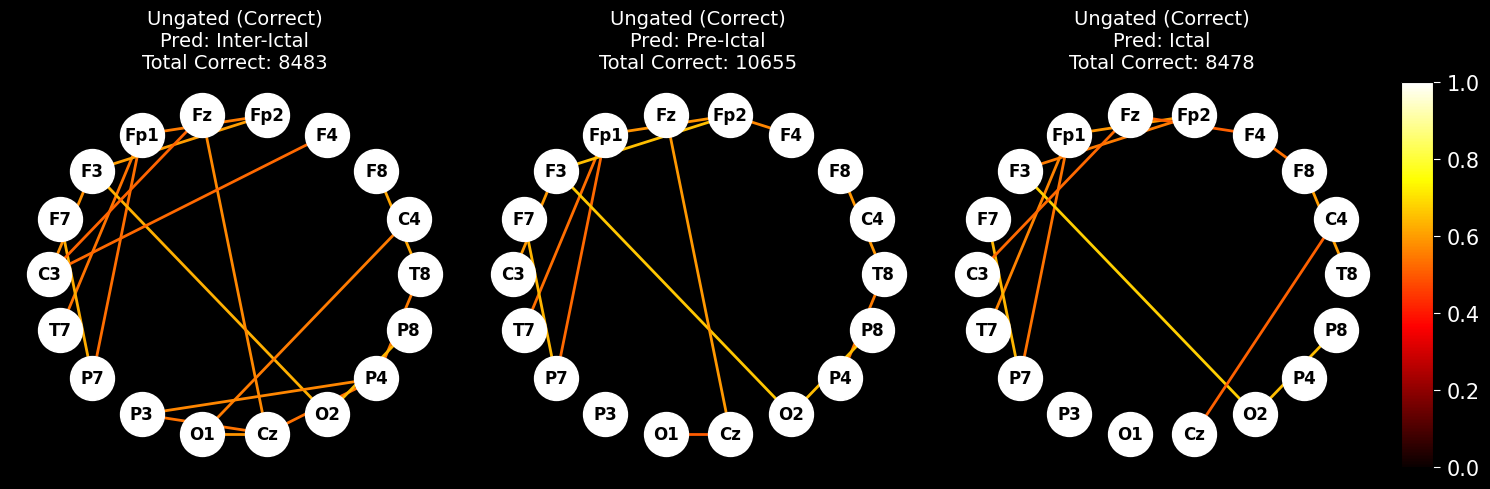

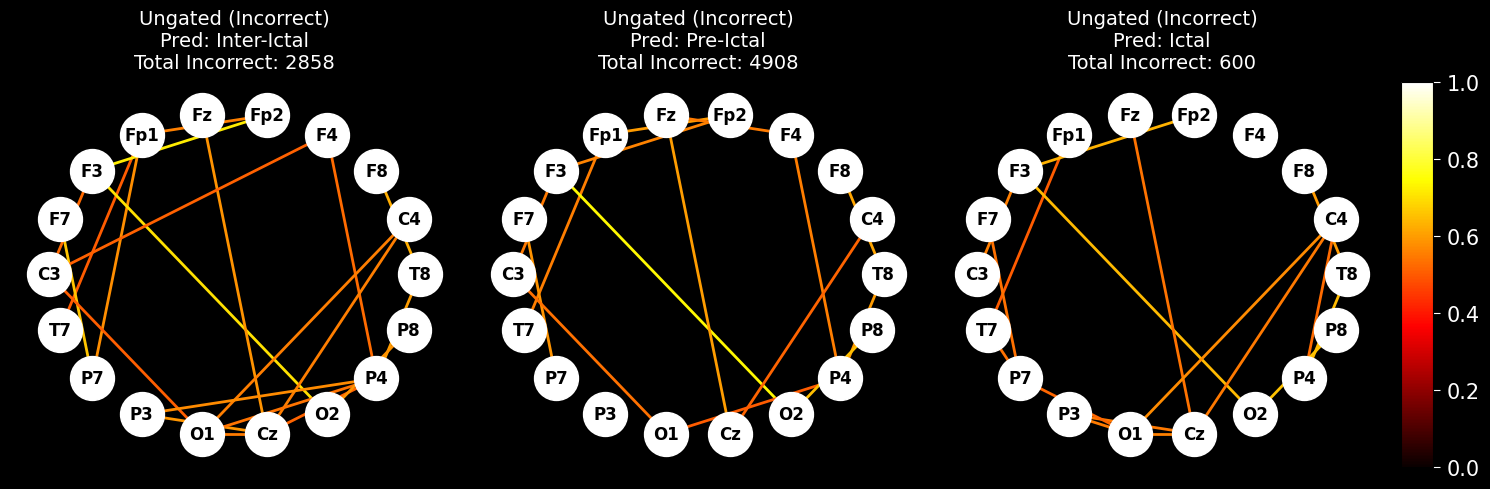

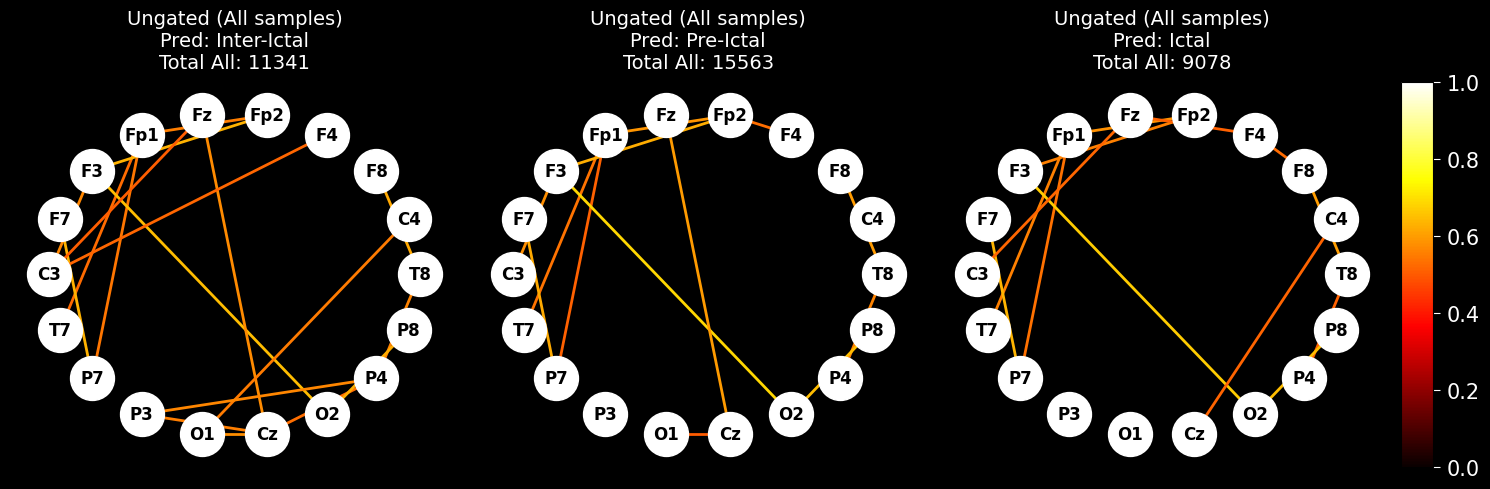

In [ ]:
import os
import json
import ast
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import torch_geometric
import scipy.stats as stats  
import pandas as pd          

# ==========================================
# 1. GRAPH HELPER FUNCTIONS & MAPPINGS
# ==========================================

def create_graph_from_dict(input_dict, self_loops=False, threshold=0.0):
    """Helper function to create a graph from a dictionary of edges."""
    g = nx.Graph()
    nodes = np.arange(18)
    g.add_nodes_from(nodes)
    for edge, value in input_dict.items():
        if value < threshold:
            continue
        if self_loops:
            g.add_edge(*edge, strength=value)
        else:
            if edge[0] != edge[1]:
                g.add_edge(*edge, strength=value)
    return g

def reverse_dict(d):
    return {v: k for k, v in d.items()}

# Channel Setup
ch_names_current = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "T7", "C3", "Cz", "C4", "T8", "P7", "P3", "P4", "P8", "O1", "O2"]
ch_dict_current = {ch_name: idx for idx, ch_name in enumerate(ch_names_current)}
ch_names_target = ["T8", "C4", "F8", "F4", "Fp2", "Fz", "Fp1", "F3", "F7", "C3", "T7", "P7", "P3", "O1", "Cz", "O2", "P4", "P8"]

ch_dict_target = reverse_dict({ch_name: ch_dict_current[ch_name] for ch_name in ch_names_target})
ch_dict_current_rev = reverse_dict(ch_dict_current)
channel_mapping = reverse_dict(dict(zip(ch_dict_current_rev.keys(), ch_dict_target.keys())))
custom_labels = {n: ch_names_current[n] for n in range(len(ch_names_current))}

# ==========================================
# 2. RENDER PIPELINE
# ==========================================

def render_attention_graphs(masks_list, save_path, title_prefix="", subtitles=None):
    """Renders the ISBI layout (Interictal, Preictal, Ictal) and saves the figure."""
    fig, axes = plt.subplots(ncols=4, nrows=1, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1, 0.07]})
    axes = axes.ravel()
    cmap = plt.cm.hot
    
    titles = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    if subtitles is None:
        subtitles = ["", "", ""]
        
    for n, dict_att in enumerate(masks_list):
        torch_geometric.seed_everything(42)
        g = create_graph_from_dict(dict_att, threshold=0.5)
        edge_opacities = [strength for strength in nx.get_edge_attributes(g, "strength").values()]
        
        pos_circular = nx.circular_layout(g)
        pos_custom = {idx: pos_circular[channel_mapping[idx]] for idx in range(len(ch_names_current))}
        
        nx.draw(
            g,
            with_labels=True,
            labels=custom_labels,
            pos=pos_custom,
            font_weight="bold",
            edge_color=edge_opacities,
            width=2,
            node_size=1000,
            node_color="white",
            edge_cmap=cmap,
            ax=axes[n],
            edge_vmin=0,
            edge_vmax=1,
        )
        # Add subtitle (counts) to the graph titles
        full_title = f"{title_prefix}\n{titles[n]}\n{subtitles[n]}" if subtitles[n] else f"{title_prefix}\n{titles[n]}"
        axes[n].set_title(full_title, color="white", fontsize=14, pad=10)

    # Colorbar configuration
    cax = axes[-1]
    colorbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=cax)
    color = "white"
    colorbar.ax.yaxis.set_tick_params(color=color, labelcolor=color, size=5, labelrotation=0)
    colorbar.ax.tick_params(axis='y', which='major', pad=5, labelsize=15)
    
    fig.set_facecolor("black")
    fig.tight_layout()
    
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, facecolor=fig.get_facecolor())
    plt.show()

# ==========================================
# 3. TOPOLOGY SHIFT QUANTIFICATION
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= 0.5).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(all_list, correct_list, incorrect_list, save_dir):
    """Calculates and saves topology correlations as Pandas DataFrames."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_correct_all, s_correct_all = compute_matrix_correlation(correct_list[i], all_list[i], threshold=0.5)
        p_incorrect_all, s_incorrect_all = compute_matrix_correlation(incorrect_list[i], all_list[i], threshold=0.5)
        p_incorrect_correct, s_incorrect_correct = compute_matrix_correlation(incorrect_list[i], correct_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Ungated (Correct) vs Ungated (All samples)": round(p_correct_all, 4),
            "Ungated (Incorrect) vs Ungated (All samples)": round(p_incorrect_all, 4),
            "Ungated (Incorrect) vs Ungated (Correct)": round(p_incorrect_correct, 4)
        }
        
        spearman_dict[cls] = {
            "Ungated (Correct) vs Ungated (All samples)": round(s_correct_all, 4),
            "Ungated (Incorrect) vs Ungated (All samples)": round(s_incorrect_all, 4),
            "Ungated (Incorrect) vs Ungated (Correct": round(s_incorrect_correct, 4)
        }
    
    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print("PEARSON CORRELATION METRICS (UNGATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print("SPEARMAN CORRELATION METRICS (UNGATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs
    df_pearson.to_csv(os.path.join(save_dir, "pearson_metrics_ungated_analysis.csv"))
    df_spearman.to_csv(os.path.join(save_dir, "spearman_metrics_ungated_analysis.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, "topology_correlation_metrics_ungated_analysis.txt"), 'w') as f:
        f.write("Topology Shift Quantification Metrics (Ungated Analysis) (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

# ==========================================
# 4. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_samples(att_dir, unc_dir, target_file="test_data.json", unc_file="per_sample_data.npz"):
    """Loads MC Dropout samples and splits them purely by correctness (All, Correct, Incorrect)."""
    folds = [f for f in os.listdir(att_dir) if f.startswith("fold_")]
    
    # Dictionaries for Edge Accumulation grouped by Predict Label (0:Pre, 1:Ict, 2:Inter)
    all_dicts = {0: {}, 1: {}, 2: {}}
    correct_dicts = {0: {}, 1: {}, 2: {}}
    incorrect_dicts = {0: {}, 1: {}, 2: {}}
    
    # Counters for normalization
    count_all = {0: 0, 1: 0, 2: 0}
    count_correct = {0: 0, 1: 0, 2: 0}
    count_incorrect = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        if not os.path.exists(json_path) or not os.path.exists(npz_path):
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            
            # Predict label directly from aligned NPZ
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            
            # Update Counts
            count_all[pred_label] += 1
            if is_correct:
                count_correct[pred_label] += 1
            else:
                count_incorrect[pred_label] += 1
                
            # Accumulate Edges
            for idx in range(len(masks)):
                u, v = edges[0][idx], edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                # All Samples
                all_dicts[pred_label][edge_tup] = all_dicts[pred_label].get(edge_tup, 0) + val
                
                # Correct vs Incorrect Split
                if is_correct:
                    correct_dicts[pred_label][edge_tup] = correct_dicts[pred_label].get(edge_tup, 0) + val
                else:
                    incorrect_dicts[pred_label][edge_tup] = incorrect_dicts[pred_label].get(edge_tup, 0) + val

    # Calculate final averages (Order: Inter=2, Pre=0, Ict=1)
    final_all = [
        {k: v / max(1, count_all[2]) for k, v in all_dicts[2].items()},
        {k: v / max(1, count_all[0]) for k, v in all_dicts[0].items()},
        {k: v / max(1, count_all[1]) for k, v in all_dicts[1].items()}
    ]

    final_correct = [
        {k: v / max(1, count_correct[2]) for k, v in correct_dicts[2].items()},
        {k: v / max(1, count_correct[0]) for k, v in correct_dicts[0].items()},
        {k: v / max(1, count_correct[1]) for k, v in correct_dicts[1].items()}
    ]
    
    final_incorrect = [
        {k: v / max(1, count_incorrect[2]) for k, v in incorrect_dicts[2].items()},
        {k: v / max(1, count_incorrect[0]) for k, v in incorrect_dicts[0].items()},
        {k: v / max(1, count_incorrect[1]) for k, v in incorrect_dicts[1].items()}
    ]
    
    # Formatting Subtitles for the plots [Inter, Pre, Ict]
    all_stats = [
        f"Total All: {count_all[2]}" if count_all[2] > 0 else "N/A",
        f"Total All: {count_all[0]}" if count_all[0] > 0 else "N/A",
        f"Total All: {count_all[1]}" if count_all[1] > 0 else "N/A"
    ]

    correct_stats = [
        f"Total Correct: {count_correct[2]}" if count_correct[2] > 0 else "N/A",
        f"Total Correct: {count_correct[0]}" if count_correct[0] > 0 else "N/A",
        f"Total Correct: {count_correct[1]}" if count_correct[1] > 0 else "N/A"
    ]
    
    incorrect_stats = [
        f"Total Incorrect: {count_incorrect[2]}" if count_incorrect[2] > 0 else "N/A",
        f"Total Incorrect: {count_incorrect[0]}" if count_incorrect[0] > 0 else "N/A",
        f"Total Incorrect: {count_incorrect[1]}" if count_incorrect[1] > 0 else "N/A"
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# 5. EXECUTION
# ==========================================

if __name__ == "__main__":
    # --- CONFIGURATION ---
    DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_full"
    DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics"
    
    SAVE_DIR_PLOTS = "/plots/attention_ungated_analysis_id"
    
    print("\nProcessing All/Correct/Incorrect splits for MC Dropout data...")
    try:
        all_masks, correct_masks, incorrect_masks, all_stats, correct_stats, incorrect_stats = process_mc_dropout_samples(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC,
            target_file="test_data.json",
            unc_file="per_sample_data.npz"
        )
        
        # Calculate and save metrics 
        df_pearson, df_spearman = save_topology_metrics(
            all_masks,
            correct_masks, 
            incorrect_masks, 
            SAVE_DIR_PLOTS
        )

        
        # Plot 1: Ungated (Correct)
        render_attention_graphs(
            correct_masks, 
            save_path=f"{SAVE_DIR_PLOTS}/connectivity_ungated_correct.pdf",
            title_prefix="Ungated (Correct)",
            subtitles=correct_stats
        )
        
        # Plot 2: Ungated (Incorrect)
        render_attention_graphs(
            incorrect_masks, 
            save_path=f"{SAVE_DIR_PLOTS}/connectivity_ungated_incorrect.pdf",
            title_prefix="Ungated (Incorrect)",
            subtitles=incorrect_stats
        )

        # Plot 3: Ungated (All samples)
        render_attention_graphs(
            all_masks, 
            save_path=f"{SAVE_DIR_PLOTS}/connectivity_ungated_all.pdf",
            title_prefix="Ungated (All samples)",
            subtitles=all_stats
        )
        
        
    except Exception as e:
        print(f"Error processing MC Dropout: {e}")

## Attention Masks - ID, Gated (All samples) vs Gated (Correct) and Gated (All samples) vs Gated (Incorrect)


Processing All/Correct/Incorrect splits for MC Dropout data...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS (GATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal                                  0.5843                                    0.1201                                0.0624
Pred: Pre-Ictal                                    0.6123                                    0.0014                               -0.0287
Pred: Ictal                                        0.5707                                   -0.3100                               -0.3623

SPEARMAN CORRELATION METRICS (GATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal

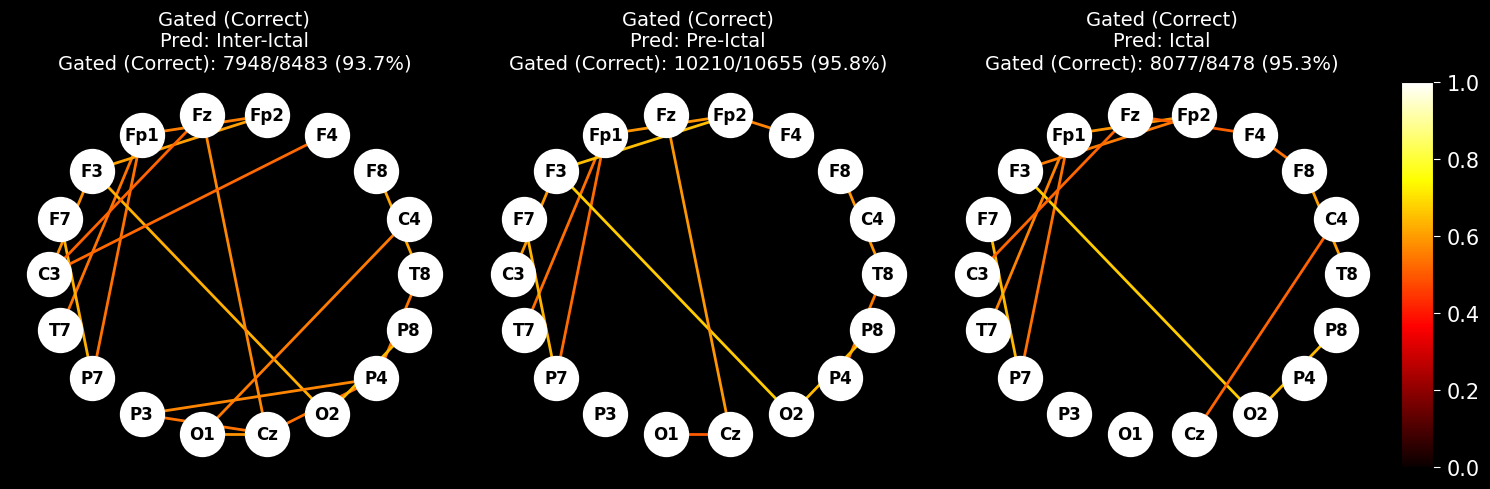

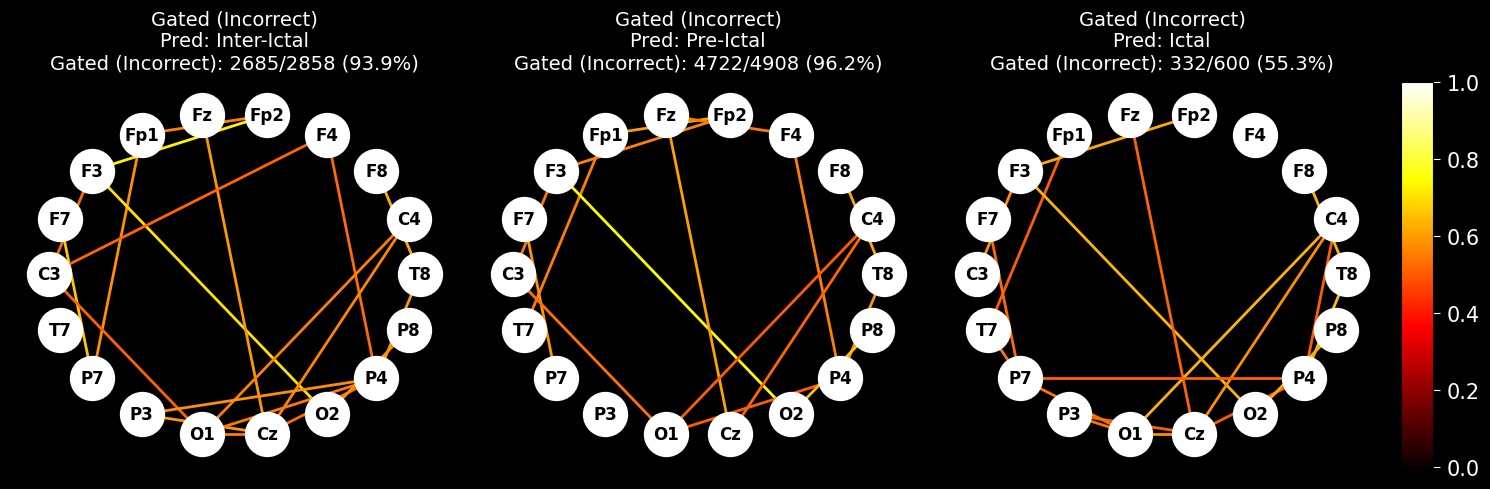

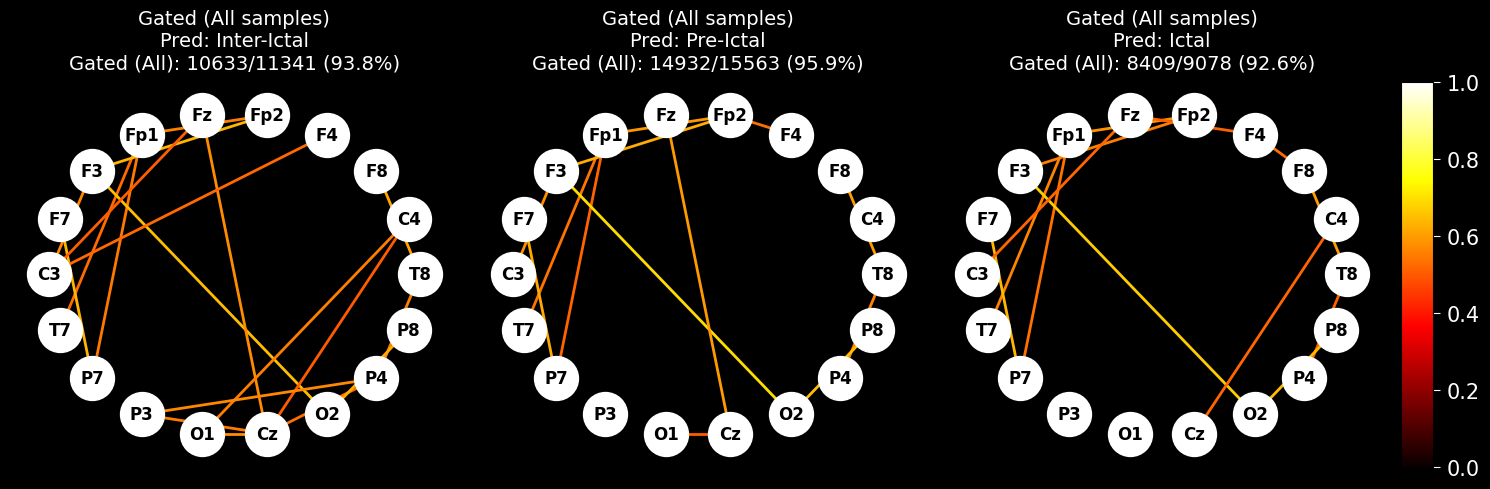

In [ ]:
import os
import json
import ast
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import torch_geometric
import scipy.stats as stats  
import pandas as pd          

# ==========================================
# 1. GRAPH HELPER FUNCTIONS & MAPPINGS
# ==========================================

def create_graph_from_dict(input_dict, self_loops=False, threshold=0.0):
    """Helper function to create a graph from a dictionary of edges."""
    g = nx.Graph()
    nodes = np.arange(18)
    g.add_nodes_from(nodes)
    for edge, value in input_dict.items():
        if value < threshold:
            continue
        if self_loops:
            g.add_edge(*edge, strength=value)
        else:
            if edge[0] != edge[1]:
                g.add_edge(*edge, strength=value)
    return g

def reverse_dict(d):
    return {v: k for k, v in d.items()}

# Channel Setup
ch_names_current = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "T7", "C3", "Cz", "C4", "T8", "P7", "P3", "P4", "P8", "O1", "O2"]
ch_dict_current = {ch_name: idx for idx, ch_name in enumerate(ch_names_current)}
ch_names_target = ["T8", "C4", "F8", "F4", "Fp2", "Fz", "Fp1", "F3", "F7", "C3", "T7", "P7", "P3", "O1", "Cz", "O2", "P4", "P8"]

ch_dict_target = reverse_dict({ch_name: ch_dict_current[ch_name] for ch_name in ch_names_target})
ch_dict_current_rev = reverse_dict(ch_dict_current)
channel_mapping = reverse_dict(dict(zip(ch_dict_current_rev.keys(), ch_dict_target.keys())))
custom_labels = {n: ch_names_current[n] for n in range(len(ch_names_current))}

# ==========================================
# 2. RENDER PIPELINE
# ==========================================

def render_attention_graphs(masks_list, save_path, title_prefix="", subtitles=None):
    """Renders the ISBI layout (Interictal, Preictal, Ictal) and saves the figure."""
    fig, axes = plt.subplots(ncols=4, nrows=1, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1, 0.07]})
    axes = axes.ravel()
    cmap = plt.cm.hot
    
    titles = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    if subtitles is None:
        subtitles = ["", "", ""]
        
    for n, dict_att in enumerate(masks_list):
        torch_geometric.seed_everything(42)
        g = create_graph_from_dict(dict_att, threshold=0.5)
        edge_opacities = [strength for strength in nx.get_edge_attributes(g, "strength").values()]
        
        pos_circular = nx.circular_layout(g)
        pos_custom = {idx: pos_circular[channel_mapping[idx]] for idx in range(len(ch_names_current))}
        
        nx.draw(
            g,
            with_labels=True,
            labels=custom_labels,
            pos=pos_custom,
            font_weight="bold",
            edge_color=edge_opacities,
            width=2,
            node_size=1000,
            node_color="white",
            edge_cmap=cmap,
            ax=axes[n],
            edge_vmin=0,
            edge_vmax=1,
        )
        # Add subtitle (counts) to the graph titles
        full_title = f"{title_prefix}\n{titles[n]}\n{subtitles[n]}" if subtitles[n] else f"{title_prefix}\n{titles[n]}"
        axes[n].set_title(full_title, color="white", fontsize=14, pad=10)

    # Colorbar configuration
    cax = axes[-1]
    colorbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=cax)
    color = "white"
    colorbar.ax.yaxis.set_tick_params(color=color, labelcolor=color, size=5, labelrotation=0)
    colorbar.ax.tick_params(axis='y', which='major', pad=5, labelsize=15)
    
    fig.set_facecolor("black")
    fig.tight_layout()
    
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, facecolor=fig.get_facecolor())
    plt.show()

# ==========================================
# 3. TOPOLOGY SHIFT QUANTIFICATION
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= 0.5).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(all_list, correct_list, incorrect_list, save_dir):
    """Calculates and saves topology correlations as Pandas DataFrames."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_correct_all, s_correct_all = compute_matrix_correlation(correct_list[i], all_list[i], threshold=0.5)
        p_incorrect_all, s_incorrect_all = compute_matrix_correlation(incorrect_list[i], all_list[i], threshold=0.5)
        p_incorrect_correct, s_incorrect_correct = compute_matrix_correlation(incorrect_list[i], correct_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Gated (Correct) vs Gated (All samples)": round(p_correct_all, 4),
            "Gated (Incorrect) vs Gated (All samples)": round(p_incorrect_all, 4),
            "Gated (Incorrect) vs Gated (Correct)": round(p_incorrect_correct, 4)
        }
        
        spearman_dict[cls] = {
            "Gated (Correct) vs Gated (All samples)": round(s_correct_all, 4),
            "Gated (Incorrect) vs Gated (All samples)": round(s_incorrect_all, 4),
            "Gated (Incorrect) vs Gated (Correct)": round(s_incorrect_correct, 4)
        }
    
    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print("PEARSON CORRELATION METRICS (GATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print("SPEARMAN CORRELATION METRICS (GATED: ALL vs CORRECT vs INCORRECT) (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs
    df_pearson.to_csv(os.path.join(save_dir, "pearson_metrics_gated_analysis.csv"))
    df_spearman.to_csv(os.path.join(save_dir, "spearman_metrics_gated_analysis.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, "topology_correlation_metrics_gated_analysis.txt"), 'w') as f:
        f.write("Topology Shift Quantification Metrics (Gated Analysis) (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

# ==========================================
# 4. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_samples(att_dir, unc_dir, threshold_file, target_file="test_data.json", unc_file="per_sample_data.npz"):
    """Loads MC Dropout samples, applies Uncertainty Gate, and splits by correctness (All, Correct, Incorrect)."""
    if not os.path.exists(threshold_file):
        raise FileNotFoundError(f"Cannot find threshold file at: {threshold_file}")
        
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        if not content:
            raise ValueError(f"The file {threshold_file} is empty!")
        tau = float(content)
        
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")

    folds = [f for f in os.listdir(att_dir) if f.startswith("fold_")]
    
    # Dictionaries for Edge Accumulation grouped by Predict Label (0:Pre, 1:Ict, 2:Inter)
    all_dicts = {0: {}, 1: {}, 2: {}}
    correct_dicts = {0: {}, 1: {}, 2: {}}
    incorrect_dicts = {0: {}, 1: {}, 2: {}}
    
    # Counters for normalization
    count_total_all = {0: 0, 1: 0, 2: 0}
    count_total_correct = {0: 0, 1: 0, 2: 0}
    count_total_incorrect = {0: 0, 1: 0, 2: 0}
    
    count_retained_all = {0: 0, 1: 0, 2: 0}
    count_retained_correct = {0: 0, 1: 0, 2: 0}
    count_retained_incorrect = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        if not os.path.exists(json_path) or not os.path.exists(npz_path):
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        pred_labels = unc_data["pred_labels"]
        epistemic_arr = unc_data["epistemic_entropy"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            
            # Predict label directly from aligned NPZ
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            is_retained = (epistemic_arr[i] < tau)
            
            # Update Total Counts
            count_total_all[pred_label] += 1
            if is_correct:
                count_total_correct[pred_label] += 1
            else:
                count_total_incorrect[pred_label] += 1
                
            # Skip accumulating if gated out
            if not is_retained:
                continue
                
            # Update Retained Counts
            count_retained_all[pred_label] += 1
            if is_correct:
                count_retained_correct[pred_label] += 1
            else:
                count_retained_incorrect[pred_label] += 1
                
            # Accumulate Edges for Gated Samples
            for idx in range(len(masks)):
                u, v = edges[0][idx], edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                all_dicts[pred_label][edge_tup] = all_dicts[pred_label].get(edge_tup, 0) + val
                
                if is_correct:
                    correct_dicts[pred_label][edge_tup] = correct_dicts[pred_label].get(edge_tup, 0) + val
                else:
                    incorrect_dicts[pred_label][edge_tup] = incorrect_dicts[pred_label].get(edge_tup, 0) + val

    # Calculate final averages for GATED elements (Order: Inter=2, Pre=0, Ict=1)
    final_all = [
        {k: v / max(1, count_retained_all[2]) for k, v in all_dicts[2].items()},
        {k: v / max(1, count_retained_all[0]) for k, v in all_dicts[0].items()},
        {k: v / max(1, count_retained_all[1]) for k, v in all_dicts[1].items()}
    ]

    final_correct = [
        {k: v / max(1, count_retained_correct[2]) for k, v in correct_dicts[2].items()},
        {k: v / max(1, count_retained_correct[0]) for k, v in correct_dicts[0].items()},
        {k: v / max(1, count_retained_correct[1]) for k, v in correct_dicts[1].items()}
    ]
    
    final_incorrect = [
        {k: v / max(1, count_retained_incorrect[2]) for k, v in incorrect_dicts[2].items()},
        {k: v / max(1, count_retained_incorrect[0]) for k, v in incorrect_dicts[0].items()},
        {k: v / max(1, count_retained_incorrect[1]) for k, v in incorrect_dicts[1].items()}
    ]
    
    # Formatting Subtitles for the plots [Inter, Pre, Ict] showing retention ratios
    all_stats = [
        f"Gated (All): {count_retained_all[2]}/{max(1, count_total_all[2])} ({(count_retained_all[2]/max(1, count_total_all[2]))*100:.1f}%)" if count_total_all[2] > 0 else "N/A",
        f"Gated (All): {count_retained_all[0]}/{max(1, count_total_all[0])} ({(count_retained_all[0]/max(1, count_total_all[0]))*100:.1f}%)" if count_total_all[0] > 0 else "N/A",
        f"Gated (All): {count_retained_all[1]}/{max(1, count_total_all[1])} ({(count_retained_all[1]/max(1, count_total_all[1]))*100:.1f}%)" if count_total_all[1] > 0 else "N/A"
    ]

    correct_stats = [
        f"Gated (Correct): {count_retained_correct[2]}/{max(1, count_total_correct[2])} ({(count_retained_correct[2]/max(1, count_total_correct[2]))*100:.1f}%)" if count_total_correct[2] > 0 else "N/A",
        f"Gated (Correct): {count_retained_correct[0]}/{max(1, count_total_correct[0])} ({(count_retained_correct[0]/max(1, count_total_correct[0]))*100:.1f}%)" if count_total_correct[0] > 0 else "N/A",
        f"Gated (Correct): {count_retained_correct[1]}/{max(1, count_total_correct[1])} ({(count_retained_correct[1]/max(1, count_total_correct[1]))*100:.1f}%)" if count_total_correct[1] > 0 else "N/A"
    ]
    
    incorrect_stats = [
        f"Gated (Incorrect): {count_retained_incorrect[2]}/{max(1, count_total_incorrect[2])} ({(count_retained_incorrect[2]/max(1, count_total_incorrect[2]))*100:.1f}%)" if count_total_incorrect[2] > 0 else "N/A",
        f"Gated (Incorrect): {count_retained_incorrect[0]}/{max(1, count_total_incorrect[0])} ({(count_retained_incorrect[0]/max(1, count_total_incorrect[0]))*100:.1f}%)" if count_total_incorrect[0] > 0 else "N/A",
        f"Gated (Incorrect): {count_retained_incorrect[1]}/{max(1, count_total_incorrect[1])} ({(count_retained_incorrect[1]/max(1, count_total_incorrect[1]))*100:.1f}%)" if count_total_incorrect[1] > 0 else "N/A"
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# 5. EXECUTION
# ==========================================

if __name__ == "__main__":
    # --- CONFIGURATION ---
    DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_full"
    DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics"
    
    THRESHOLD_FILE = "/epistemic_threshold.txt"
    SAVE_DIR_PLOTS = "/plots/attention_gated_analysis_id"
    
    print("\nProcessing All/Correct/Incorrect splits for MC Dropout data...")
    try:
        all_masks, correct_masks, incorrect_masks, all_stats, correct_stats, incorrect_stats = process_mc_dropout_samples(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC,
            threshold_file=THRESHOLD_FILE,
            target_file="test_data.json",
            unc_file="per_sample_data.npz"
        )
        
        # Calculate and save metrics 
        df_pearson, df_spearman = save_topology_metrics(
            all_masks,
            correct_masks, 
            incorrect_masks, 
            SAVE_DIR_PLOTS
        )

        # Plot 1: Gated (Correct)
        render_attention_graphs(
            correct_masks, 
            save_path=f"{SAVE_DIR_PLOTS}/connectivity_gated_correct.pdf",
            title_prefix="Gated (Correct)",
            subtitles=correct_stats
        )
        
        # Plot 2: Gated (Incorrect)
        render_attention_graphs(
            incorrect_masks, 
            save_path=f"{SAVE_DIR_PLOTS}/connectivity_gated_incorrect.pdf",
            title_prefix="Gated (Incorrect)",
            subtitles=incorrect_stats
        )

        # Plot 3: Gated (All samples)
        render_attention_graphs(
            all_masks, 
            save_path=f"{SAVE_DIR_PLOTS}/connectivity_gated_all.pdf",
            title_prefix="Gated (All samples)",
            subtitles=all_stats
        )
        
    except Exception as e:
        print(f"Error processing MC Dropout: {e}")

## Attention Masks OOD

In [ ]:
import os
import json
import numpy as np
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION AND CONSTANTS
# ==========================================

DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_ood_full"
DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics_ood"

THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/attention_ood_correct"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= threshold).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(ungated_list, retained_list, dropped_list, save_dir, patient, count_correct, count_retained):
    """Calculates and saves topology correlations as Pandas DataFrames per patient, including Retained %."""
    classes = ["Inter-Ictal", "Pre-Ictal", "Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of correct predictions that passed the uncertainty gate
        correct_count = count_correct[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, correct_count)) * 100:.1f}%"
        
        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_matrix_correlation(ungated_list[i], retained_list[i], threshold=0.5)
        pearson_rd, spearman_rd = compute_matrix_correlation(retained_list[i], dropped_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Ungated vs Gated (Retained)": round(pearson_ur, 4),
            "Gated (Retained) vs Gated (Dropped)": round(pearson_rd, 4),
            "Retained %": ret_pct
        }
            
        spearman_dict[cls] = {
            "Ungated vs Gated (Retained)": round(spearman_ur, 4),
            "Gated (Retained) vs Gated (Dropped)": round(spearman_rd, 4),
            "Retained %": ret_pct
        }

    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_{patient}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_{patient}.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, f"topology_correlation_metrics_{patient}.txt"), 'w') as f:
        f.write(f"Topology Shift Quantification Metrics - {patient.upper()} (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir} for {patient}")
    
    return df_pearson, df_spearman

# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_ood(att_dir, unc_dir, threshold_file, patient):
    """
    Pools data across folds, filters for correct predictions, splits by predicted class 
    and uncertainty, averages the masks, and returns the pooled dictionaries.
    """
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty!")
        
    tau = float(content)
    print(f"Applying Aggregation Gate with threshold tau = {tau:.10f}")

    # Dictionaries for Edge Accumulation grouped by True Label (0:Pre, 1:Ict, 2:Inter)
    ungated_dicts = {0: {}, 1: {}, 2: {}}
    retained_dicts = {0: {}, 1: {}, 2: {}}
    dropped_dicts = {0: {}, 1: {}, 2: {}}

    # Counters for normalization
    count_correct = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = sorted([f for f in os.listdir(att_dir) if f.startswith("fold_")])
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, f"{patient}.json")
        npz_path = os.path.join(unc_dir, fold, f"{patient}_per_sample_data.npz")
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(json_path) or not os.path.exists(npz_path): 
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        epi_arr = unc_data["epistemic_entropy"]
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            pred_label = pred_labels[i]
            
            # Filter specifically for correct predictions
            if pred_label != true_label: 
                continue
                
            count_correct[true_label] += 1
            is_retained = (epi_arr[i] < tau)
            
            # Update retention counters
            if is_retained:
                count_retained[true_label] += 1
            else:
                count_dropped[true_label] += 1
                
            # Accumulate Edges
            for idx in range(len(masks)):
                u = edges[0][idx]
                v = edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                # Accumulate baseline (Ungated) metrics
                ungated_dicts[true_label][edge_tup] = ungated_dicts[true_label].get(edge_tup, 0) + val
                
                # Split by gate
                if is_retained:
                    retained_dicts[true_label][edge_tup] = retained_dicts[true_label].get(edge_tup, 0) + val
                else:
                    dropped_dicts[true_label][edge_tup] = dropped_dicts[true_label].get(edge_tup, 0) + val

    # Calculate final averages (Order: Inter=2, Pre=0, Ict=1)
    final_ungated = [
        {k: v / max(1, count_correct[2]) for k, v in ungated_dicts[2].items()},
        {k: v / max(1, count_correct[0]) for k, v in ungated_dicts[0].items()},
        {k: v / max(1, count_correct[1]) for k, v in ungated_dicts[1].items()}
    ]

    final_retained = [
        {k: v / max(1, count_retained[2]) for k, v in retained_dicts[2].items()},
        {k: v / max(1, count_retained[0]) for k, v in retained_dicts[0].items()},
        {k: v / max(1, count_retained[1]) for k, v in retained_dicts[1].items()}
    ]
    
    final_dropped = [
        {k: v / max(1, count_dropped[2]) for k, v in dropped_dicts[2].items()},
        {k: v / max(1, count_dropped[0]) for k, v in dropped_dicts[0].items()},
        {k: v / max(1, count_dropped[1]) for k, v in dropped_dicts[1].items()}
    ]
    
    return final_ungated, final_retained, final_dropped, count_correct, count_retained

# ==========================================
# 4. EXECUTION PIPELINE
# ==========================================

def run_analysis(att_dir, unc_dir, threshold_file, patient, save_dir):
    """
    Constructs the necessary file paths and triggers the extraction and saving pipeline 
    for a specific dataset or patient.
    """
    print(f"\n{'='*50}\nProcessing OOD Patient: {patient}\n{'='*50}")

    try:
        ungated_masks, retained_masks, dropped_masks, count_correct, count_retained = process_mc_dropout_ood(
            att_dir=att_dir, 
            unc_dir=unc_dir,
            threshold_file=threshold_file,
            patient=patient
        )
        
        if ungated_masks is not None:
            save_topology_metrics(
                ungated_list=ungated_masks, 
                retained_list=retained_masks, 
                dropped_list=dropped_masks, 
                save_dir=save_dir, 
                patient=patient,
                count_correct=count_correct,
                count_retained=count_retained
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {patient}: {e}")

if __name__ == "__main__":
    
    # Execute the analysis strictly over the Out-Of-Distribution patient list
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    
    for patient in OOD_PATIENTS:
        run_analysis(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC, 
            threshold_file=THRESHOLD_FILE, 
            patient=patient,
            save_dir=SAVE_DIR
        )


Processing OOD Patient: chb22
Applying Aggregation Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS - CHB22 (Threshold = 0.5)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                       0.5583                              -0.0202      92.7%
Pre-Ictal                         1.0000                               0.5346      98.6%
Ictal                             0.9992                               0.2995      94.8%

SPEARMAN CORRELATION METRICS - CHB22 (Threshold = 0.5)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                       0.9636                               0.2915      92.7%
Pre-Ictal                         0.9995                               0.7475      98.6%
Ictal                             0.9957                               0.5837      94.8%


Topology metrics saved as tables to: /metrics/attention_ood_correct for chb22

Proce

## Attention Graph- OOD Incorrect Predictions

In [ ]:
import os
import json
import numpy as np
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION AND CONSTANTS
# ==========================================

DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_ood_full"
DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics_ood"

THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/attention_incorrect_ood"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= threshold).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(ungated_list, retained_list, dropped_list, save_dir, patient, count_incorrect, count_retained):
    """Calculates and saves topology correlations as Pandas DataFrames per patient, including Retained %."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of incorrect predictions that passed the uncertainty gate
        incorrect_count = count_incorrect[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, incorrect_count)) * 100:.1f}%"
        
        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_matrix_correlation(ungated_list[i], retained_list[i], threshold=0.5)
        pearson_rd, spearman_rd = compute_matrix_correlation(retained_list[i], dropped_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Ungated vs Retained": round(pearson_ur, 4),
            "Retained vs  Dropped": round(pearson_rd, 4),
            "Retained %": ret_pct
        }
            
        spearman_dict[cls] = {
            "Ungated vs Retained": round(spearman_ur, 4),
            "Retained vs  Dropped": round(spearman_rd, 4),
            "Retained %": ret_pct
        }

    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS (INCORRECT PREDS) - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS (INCORRECT PREDS) - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_incorrect_{patient}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_incorrect_{patient}.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, f"topology_correlation_metrics_incorrect_{patient}.txt"), 'w') as f:
        f.write(f"Topology Shift Quantification Metrics (Incorrect Preds) - {patient.upper()} (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir} for {patient}")
    
    return df_pearson, df_spearman

# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_incorrect(att_dir, unc_dir, threshold_file, patient):
    """
    Pools data across folds, filters for incorrect predictions, splits by predicted class 
    and uncertainty, averages the masks, and returns the pooled dictionaries.
    """
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty!")
        
    tau = float(content)
    print(f"Analyzing INCORRECT samples with uncertainty gate tau = {tau:.10f}")

    # Dictionaries for Edge Accumulation grouped by Predict Label (0:Pre, 1:Ict, 2:Inter)
    ungated_dicts = {0: {}, 1: {}, 2: {}}
    retained_dicts = {0: {}, 1: {}, 2: {}}
    dropped_dicts = {0: {}, 1: {}, 2: {}}

    # Counters for normalization
    count_incorrect = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = sorted([f for f in os.listdir(att_dir) if f.startswith("fold_")])
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, f"{patient}.json")
        npz_path = os.path.join(unc_dir, fold, f"{patient}_per_sample_data.npz")
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(json_path) or not os.path.exists(npz_path): 
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        epi_arr = unc_data["epistemic_entropy"]
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            pred_label = pred_labels[i]
            
            # Filter specifically for incorrect predictions
            if true_label == pred_label: 
                continue
                
            count_incorrect[pred_label] += 1
            is_retained = (epi_arr[i] < tau)
            
            # Update retention counters
            if is_retained:
                count_retained[pred_label] += 1
            else:
                count_dropped[pred_label] += 1
                
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            
            # Accumulate Edges
            for idx in range(len(masks)):
                u = edges[0][idx]
                v = edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                # Accumulate baseline (Ungated) metrics
                ungated_dicts[pred_label][edge_tup] = ungated_dicts[pred_label].get(edge_tup, 0) + val
                
                # Split by gate
                if is_retained:
                    retained_dicts[pred_label][edge_tup] = retained_dicts[pred_label].get(edge_tup, 0) + val
                else:
                    dropped_dicts[pred_label][edge_tup] = dropped_dicts[pred_label].get(edge_tup, 0) + val

    # Calculate final averages (Order: Inter=2, Pre=0, Ict=1)
    final_ungated = [
        {k: v / max(1, count_incorrect[2]) for k, v in ungated_dicts[2].items()},
        {k: v / max(1, count_incorrect[0]) for k, v in ungated_dicts[0].items()},
        {k: v / max(1, count_incorrect[1]) for k, v in ungated_dicts[1].items()}
    ]

    final_retained = [
        {k: v / max(1, count_retained[2]) for k, v in retained_dicts[2].items()},
        {k: v / max(1, count_retained[0]) for k, v in retained_dicts[0].items()},
        {k: v / max(1, count_retained[1]) for k, v in retained_dicts[1].items()}
    ]
    
    final_dropped = [
        {k: v / max(1, count_dropped[2]) for k, v in dropped_dicts[2].items()},
        {k: v / max(1, count_dropped[0]) for k, v in dropped_dicts[0].items()},
        {k: v / max(1, count_dropped[1]) for k, v in dropped_dicts[1].items()}
    ]
    
    return final_ungated, final_retained, final_dropped, count_incorrect, count_retained

# ==========================================
# 4. EXECUTION PIPELINE
# ==========================================

def run_incorrect_analysis(att_dir, unc_dir, threshold_file, patient, save_dir):
    """
    Constructs the necessary file paths and triggers the extraction and saving pipeline 
    for a specific dataset or patient.
    """
    print(f"\n{'='*50}\nAnalyzing INCORRECT Predictions: {patient}\n{'='*50}")

    try:
        ungated_masks, retained_masks, dropped_masks, count_incorrect, count_retained = process_mc_dropout_incorrect(
            att_dir=att_dir, 
            unc_dir=unc_dir,
            threshold_file=threshold_file,
            patient=patient
        )
        
        if ungated_masks is not None:
            save_topology_metrics(
                ungated_list=ungated_masks, 
                retained_list=retained_masks, 
                dropped_list=dropped_masks, 
                save_dir=save_dir, 
                patient=patient,
                count_incorrect=count_incorrect,
                count_retained=count_retained
            )
            
    except Exception as e:
        print(f"Error processing incorrect analysis for {patient}: {e}")

if __name__ == "__main__":
    
    # Execute the analysis strictly over the Out-Of-Distribution patient list
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    
    for patient in OOD_PATIENTS:
        run_incorrect_analysis(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC, 
            threshold_file=THRESHOLD_FILE, 
            patient=patient,
            save_dir=SAVE_DIR
        )


Analyzing INCORRECT Predictions: chb22
Analyzing INCORRECT samples with uncertainty gate tau = 0.1483899914

PEARSON CORRELATION METRICS (INCORRECT PREDS) - CHB22 (Threshold = 0.5)
                   Ungated vs Retained  Retained vs  Dropped Retained %
Pred: Inter-Ictal               0.7894                0.4284      83.6%
Pred: Pre-Ictal                 0.8350               -0.1523      96.8%
Pred: Ictal                     0.6004                0.1117      67.7%

SPEARMAN CORRELATION METRICS (INCORRECT PREDS) - CHB22 (Threshold = 0.5)
                   Ungated vs Retained  Retained vs  Dropped Retained %
Pred: Inter-Ictal               0.9766                0.7067      83.6%
Pred: Pre-Ictal                 0.9946                0.0577      96.8%
Pred: Ictal                     0.8679                0.3649      67.7%


Topology metrics saved as tables to: /metrics/attention_incorrect_ood for chb22

Analyzing INCORRECT Predictions: chb23
Analyzing INCORRECT samples with uncertainty g

## Attention Masks - OOD (all samples) Ungated


Analyzing Ungated Predictions: chb22
Processing Ungated samples for patient chb22

PEARSON CORRELATION METRICS (UNGATED ANALYSIS) - CHB22 (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct)
Pred: Inter-Ictal                                      0.5456                                        0.5760                                    0.1580
Pred: Pre-Ictal                                        0.7987                                        0.3973                                    0.3182
Pred: Ictal                                            0.8408                                       -0.3139                                   -0.3621

SPEARMAN CORRELATION METRICS (UNGATED ANALYSIS) - CHB22 (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct)
Pred: Inter-Ictal 

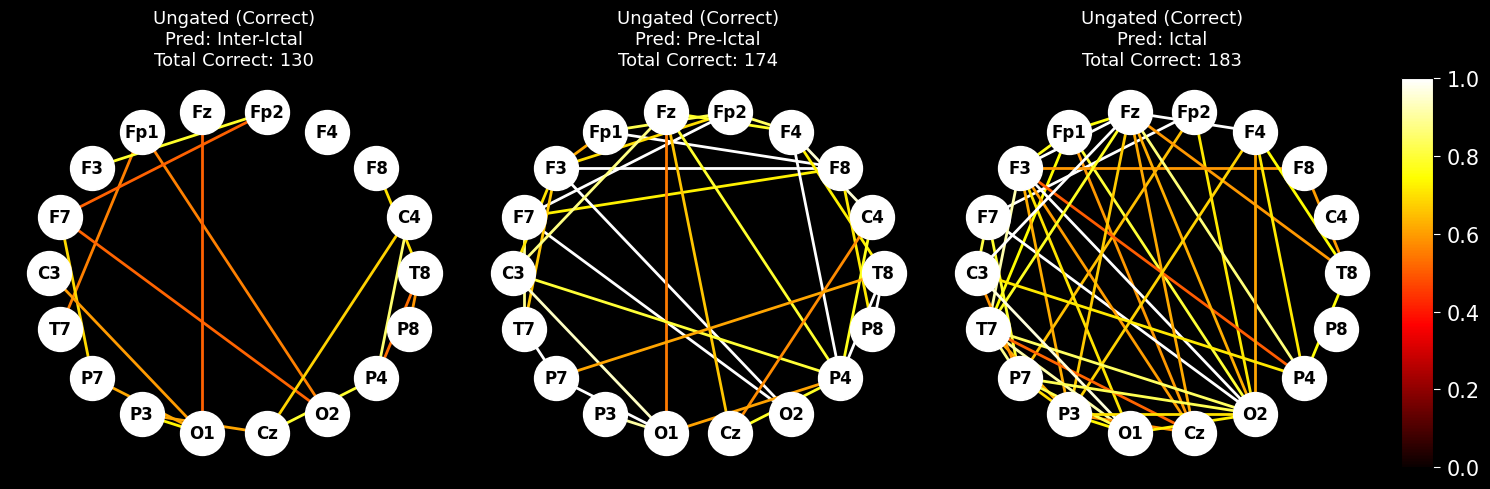

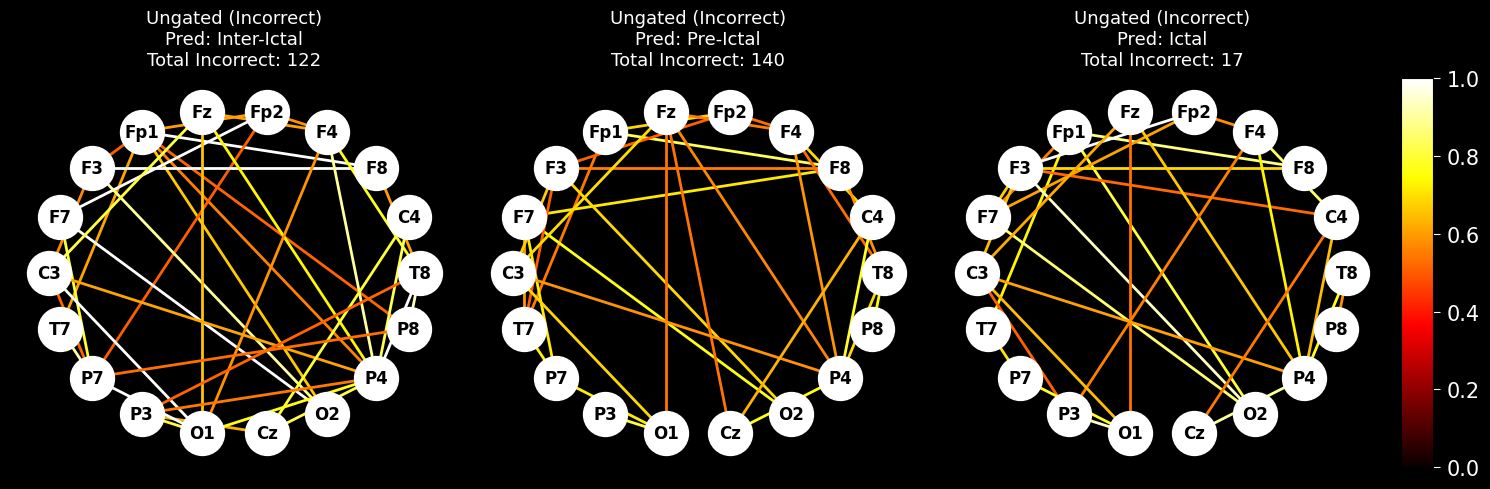

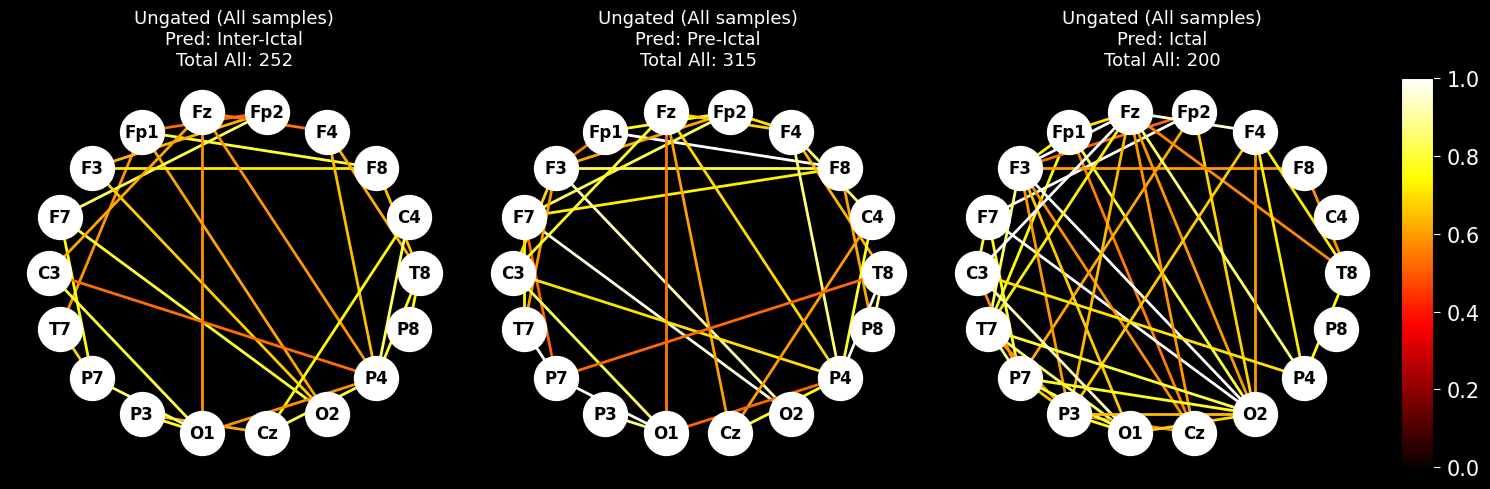


Analyzing Ungated Predictions: chb23
Processing Ungated samples for patient chb23

PEARSON CORRELATION METRICS (UNGATED ANALYSIS) - CHB23 (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct)
Pred: Inter-Ictal                                      0.0502                                        0.3876                                   -0.2383
Pred: Pre-Ictal                                        0.8197                                        0.3145                                    0.1924
Pred: Ictal                                            0.9994                                       -0.0487                                   -0.0586

SPEARMAN CORRELATION METRICS (UNGATED ANALYSIS) - CHB23 (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct)
Pred: Inter-Ictal 

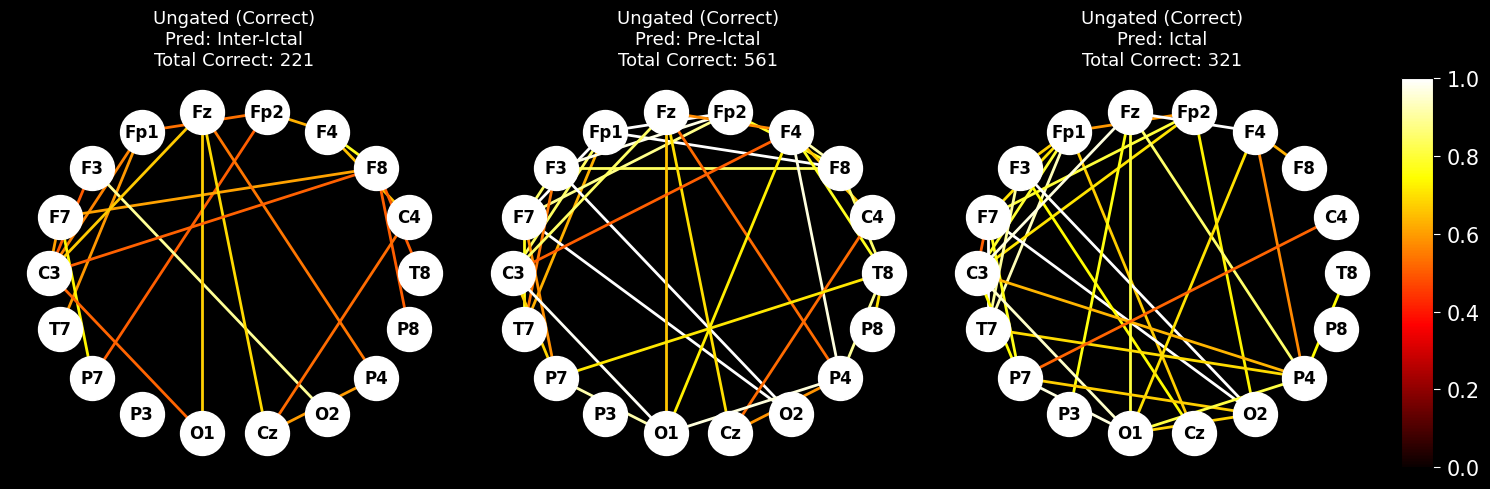

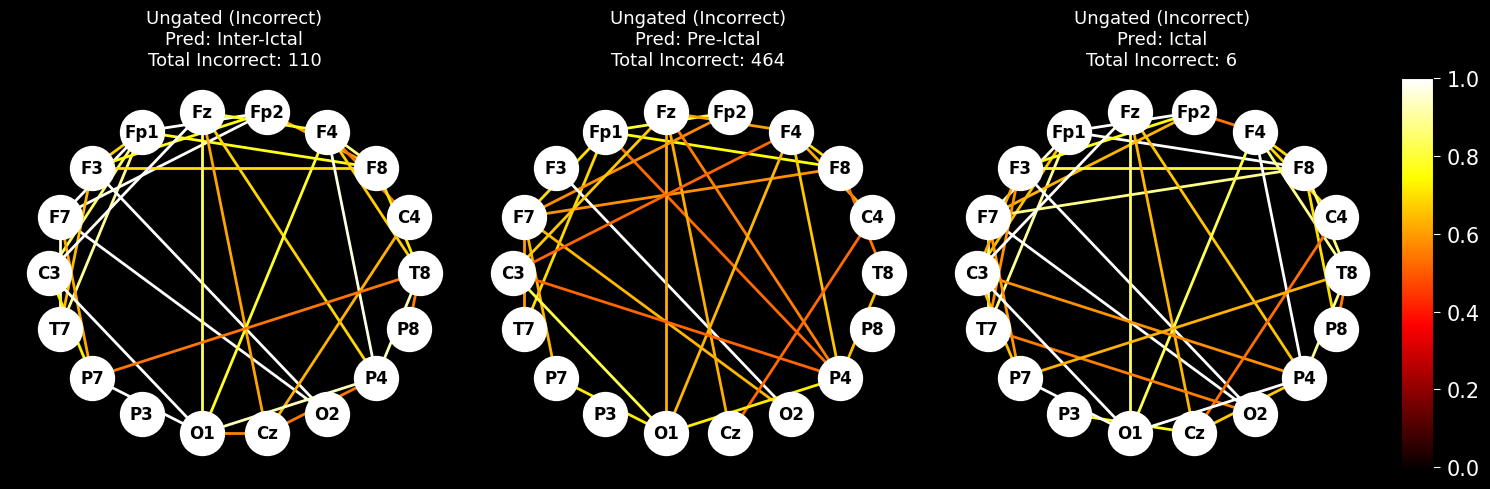

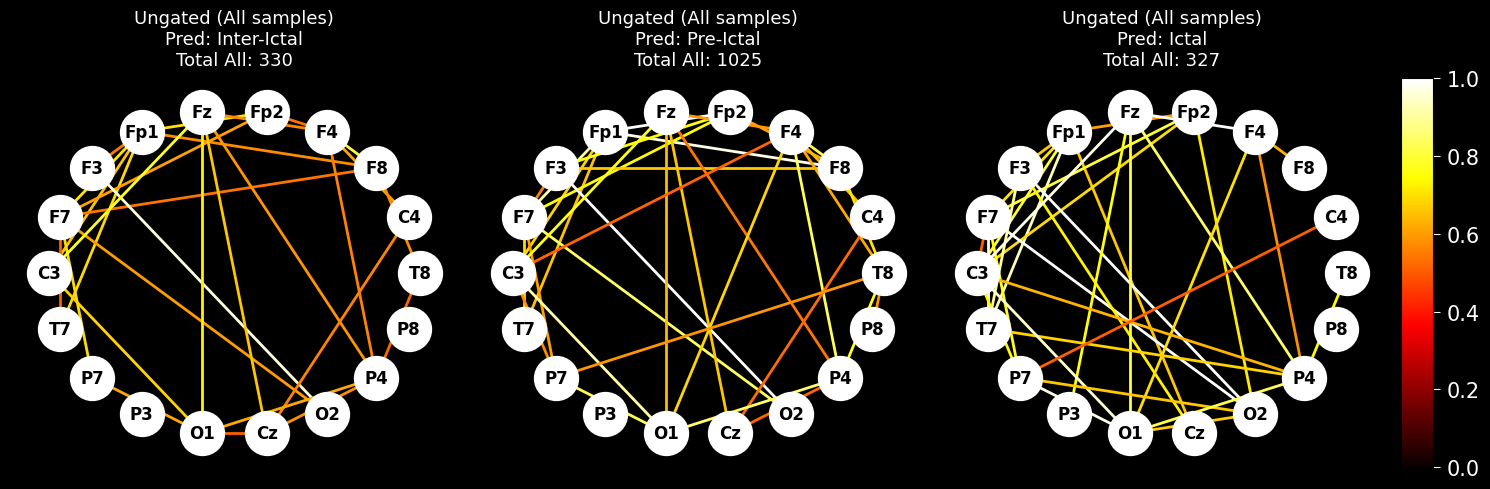


Analyzing Ungated Predictions: chb24
Processing Ungated samples for patient chb24

PEARSON CORRELATION METRICS (UNGATED ANALYSIS) - CHB24 (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct)
Pred: Inter-Ictal                                      0.4699                                        0.5134                                    0.2704
Pred: Pre-Ictal                                        0.4301                                        0.2863                                    0.0691
Pred: Ictal                                            0.6448                                       -0.2225                                   -0.3078

SPEARMAN CORRELATION METRICS (UNGATED ANALYSIS) - CHB24 (Threshold = 0.5)
                   Ungated (Correct) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (All samples)  Ungated (Incorrect) vs Ungated (Correct)
Pred: Inter-Ictal 

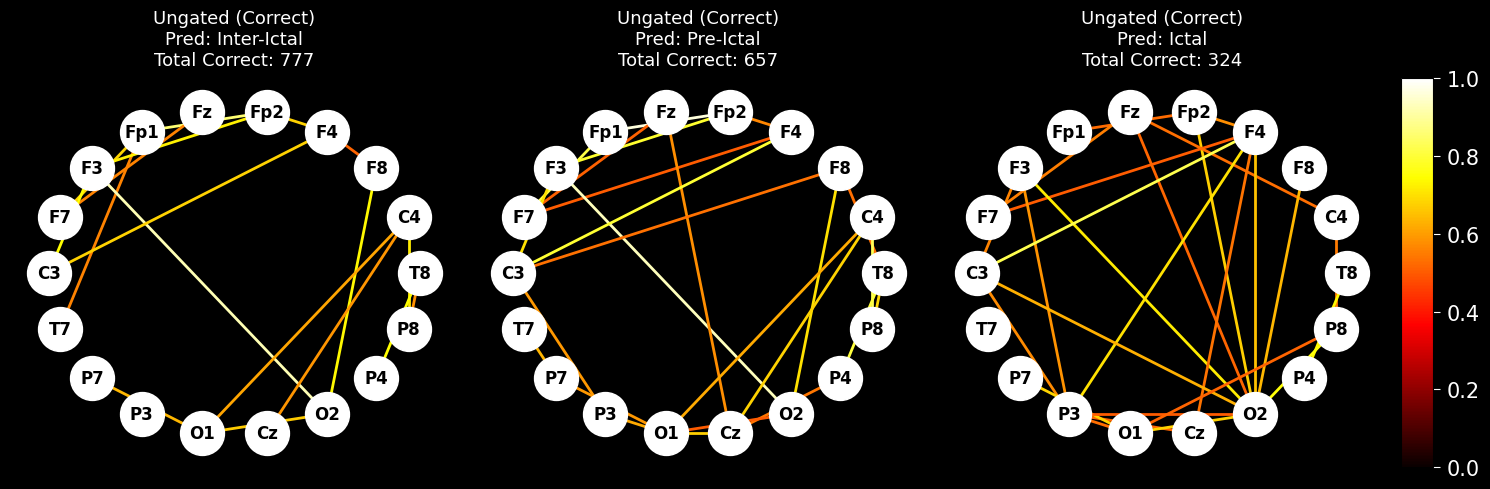

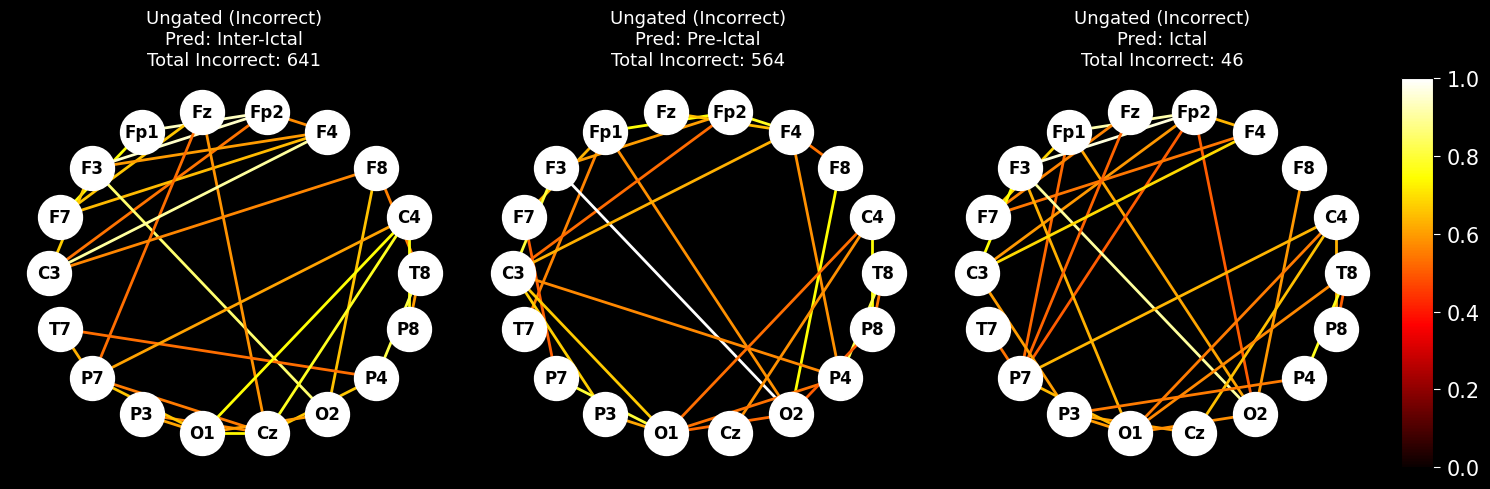

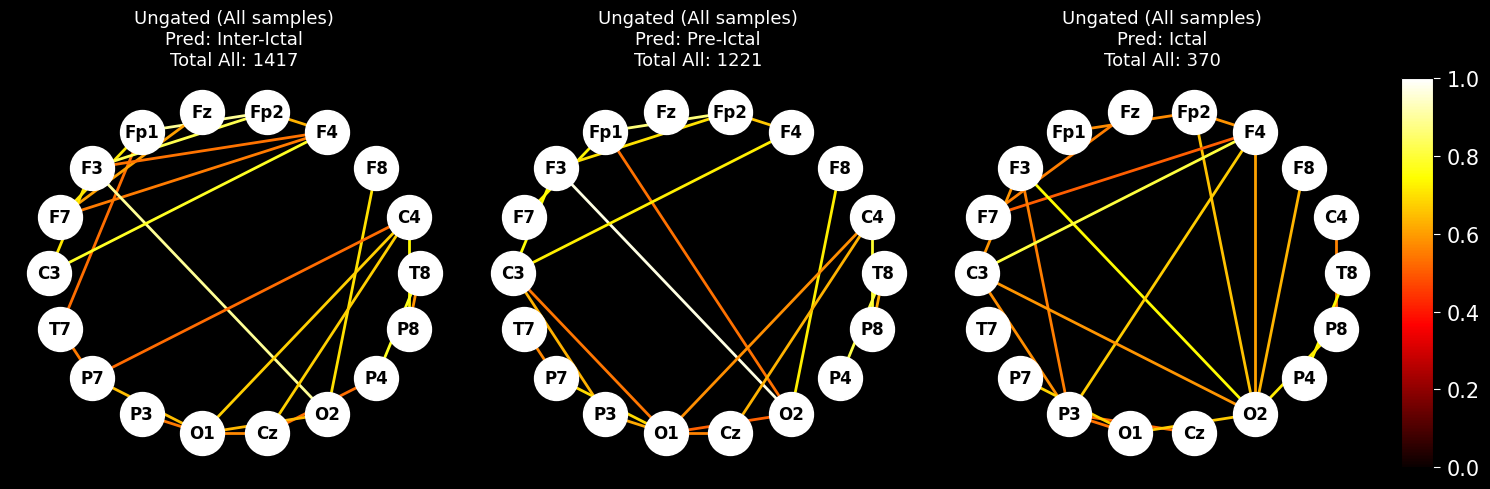

In [ ]:
import os
import json
import ast
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import torch_geometric
import scipy.stats as stats  
import pandas as pd          

# ==========================================
# 1. GRAPH HELPER FUNCTIONS & MAPPINGS
# ==========================================

def create_graph_from_dict(input_dict, self_loops=False, threshold=0.0):
    """Helper function to create a graph from a dictionary of edges."""
    g = nx.Graph()
    nodes = np.arange(18)
    g.add_nodes_from(nodes)
    for edge, value in input_dict.items():
        if value < threshold:
            continue
        if self_loops:
            g.add_edge(*edge, strength=value)
        else:
            if edge[0] != edge[1]:
                g.add_edge(*edge, strength=value)
    return g

def reverse_dict(d):
    return {v: k for k, v in d.items()}

# Channel Setup
ch_names_current = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "T7", "C3", "Cz", "C4", "T8", "P7", "P3", "P4", "P8", "O1", "O2"]
ch_dict_current = {ch_name: idx for idx, ch_name in enumerate(ch_names_current)}
ch_names_target = ["T8", "C4", "F8", "F4", "Fp2", "Fz", "Fp1", "F3", "F7", "C3", "T7", "P7", "P3", "O1", "Cz", "O2", "P4", "P8"]

ch_dict_target = reverse_dict({ch_name: ch_dict_current[ch_name] for ch_name in ch_names_target})
ch_dict_current_rev = reverse_dict(ch_dict_current)
channel_mapping = reverse_dict(dict(zip(ch_dict_current_rev.keys(), ch_dict_target.keys())))
custom_labels = {n: ch_names_current[n] for n in range(len(ch_names_current))}

# ==========================================
# 2. RENDER PIPELINE
# ==========================================

def render_attention_graphs(masks_list, save_path, title_prefix="", subtitles=None):
    """Renders the ISBI layout (Interictal, Preictal, Ictal) and saves the figure."""
    fig, axes = plt.subplots(ncols=4, nrows=1, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1, 0.07]})
    axes = axes.ravel()
    cmap = plt.cm.hot
    
    titles = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    if subtitles is None:
        subtitles = ["", "", ""]
        
    for n, dict_att in enumerate(masks_list):
        torch_geometric.seed_everything(42)
        g = create_graph_from_dict(dict_att, threshold=0.5)
        edge_opacities = [strength for strength in nx.get_edge_attributes(g, "strength").values()]
        
        pos_circular = nx.circular_layout(g)
        pos_custom = {idx: pos_circular[channel_mapping[idx]] for idx in range(len(ch_names_current))}
        
        nx.draw(
            g,
            with_labels=True,
            labels=custom_labels,
            pos=pos_custom,
            font_weight="bold",
            edge_color=edge_opacities,
            width=2,
            node_size=1000,
            node_color="white",
            edge_cmap=cmap,
            ax=axes[n],
            edge_vmin=0,
            edge_vmax=1,
        )
        full_title = f"{title_prefix}\n{titles[n]}\n{subtitles[n]}" if subtitles[n] else f"{title_prefix}\n{titles[n]}"
        axes[n].set_title(full_title, color="white", fontsize=13, pad=10)

    cax = axes[-1]
    colorbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=cax)
    color = "white"
    colorbar.ax.yaxis.set_tick_params(color=color, labelcolor=color, size=5, labelrotation=0)
    colorbar.ax.tick_params(axis='y', which='major', pad=5, labelsize=15)
    
    fig.set_facecolor("black")
    fig.tight_layout()
    
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, facecolor=fig.get_facecolor())
    plt.show()

# ==========================================
# 3. TOPOLOGY SHIFT QUANTIFICATION
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= 0.5).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(all_list, correct_list, incorrect_list, save_dir, patient):
    """Calculates and saves topology correlations as Pandas DataFrames per patient."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_correct_all, s_correct_all = compute_matrix_correlation(correct_list[i], all_list[i], threshold=0.5)
        p_incorrect_all, s_incorrect_all = compute_matrix_correlation(incorrect_list[i], all_list[i], threshold=0.5)
        p_incorrect_correct, s_incorrect_correct = compute_matrix_correlation(incorrect_list[i], correct_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Ungated (Correct) vs Ungated (All samples)": round(p_correct_all, 4),
            "Ungated (Incorrect) vs Ungated (All samples)": round(p_incorrect_all, 4),
            "Ungated (Incorrect) vs Ungated (Correct)": round(p_incorrect_correct, 4)
        }
        
        spearman_dict[cls] = {
            "Ungated (Correct) vs Ungated (All samples)": round(s_correct_all, 4),
            "Ungated (Incorrect) vs Ungated (All samples)": round(s_incorrect_all, 4),
            "Ungated (Incorrect) vs Ungated (Correct)": round(s_incorrect_correct, 4)
        }
    
    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS (UNGATED ANALYSIS) - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS (UNGATED ANALYSIS) - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs with patient name
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_ungated_{patient}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_ungated_{patient}.csv"))
    
    # Save as a formatted text file with patient name
    with open(os.path.join(save_dir, f"topology_correlation_metrics_ungated_{patient}.txt"), 'w') as f:
        f.write(f"Topology Shift Quantification Metrics (Ungated Analysis) - {patient.upper()} (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir} for {patient}")
    
    return df_pearson, df_spearman

# ==========================================
# 4. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_samples(att_dir, unc_dir, patient):
    """
    Loads MC Dropout samples and splits them purely by correctness without uncertainty gating.
    Averages the masks and divides counts appropriately.
    """
    print(f"Processing Ungated samples for patient {patient}")

    folds = sorted([f for f in os.listdir(att_dir) if f.startswith("fold_")])
    
    # Dictionaries for Edge Accumulation grouped by Predict Label (0:Pre, 1:Ict, 2:Inter)
    all_dicts = {0: {}, 1: {}, 2: {}}
    correct_dicts = {0: {}, 1: {}, 2: {}}
    incorrect_dicts = {0: {}, 1: {}, 2: {}}
    
    # Counters for normalization
    count_all = {0: 0, 1: 0, 2: 0}
    count_correct = {0: 0, 1: 0, 2: 0}
    count_incorrect = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, f"{patient}.json")
        npz_path = os.path.join(unc_dir, fold, f"{patient}_per_sample_data.npz")
        
        if not os.path.exists(json_path) or not os.path.exists(npz_path):
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            
            # Group by predicted label (from NPZ)
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            
            # Update Counts
            count_all[pred_label] += 1
            if is_correct:
                count_correct[pred_label] += 1
            else:
                count_incorrect[pred_label] += 1
                
            # Accumulate Edges for Ungated Samples
            for idx in range(len(masks)):
                u, v = edges[0][idx], edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                all_dicts[pred_label][edge_tup] = all_dicts[pred_label].get(edge_tup, 0) + val
                
                if is_correct:
                    correct_dicts[pred_label][edge_tup] = correct_dicts[pred_label].get(edge_tup, 0) + val
                else:
                    incorrect_dicts[pred_label][edge_tup] = incorrect_dicts[pred_label].get(edge_tup, 0) + val

    # Calculate final averages for UNGATED elements
    final_all = [
        {k: v / max(1, count_all[2]) for k, v in all_dicts[2].items()},
        {k: v / max(1, count_all[0]) for k, v in all_dicts[0].items()},
        {k: v / max(1, count_all[1]) for k, v in all_dicts[1].items()}
    ]

    final_correct = [
        {k: v / max(1, count_correct[2]) for k, v in correct_dicts[2].items()},
        {k: v / max(1, count_correct[0]) for k, v in correct_dicts[0].items()},
        {k: v / max(1, count_correct[1]) for k, v in correct_dicts[1].items()}
    ]
    
    final_incorrect = [
        {k: v / max(1, count_incorrect[2]) for k, v in incorrect_dicts[2].items()},
        {k: v / max(1, count_incorrect[0]) for k, v in incorrect_dicts[0].items()},
        {k: v / max(1, count_incorrect[1]) for k, v in incorrect_dicts[1].items()}
    ]
    
    # -------------------------------------------------------------------------
    # SCALE LOGIC: Apply 10x division scaling for OOD counts
    # -------------------------------------------------------------------------
    def scale_down(num): 
        return math.floor((num / 10.0) + 0.5)
    
    all_stats = [
        f"Total All: {scale_down(count_all[2])}" if count_all[2] > 0 else "N/A",
        f"Total All: {scale_down(count_all[0])}" if count_all[0] > 0 else "N/A",
        f"Total All: {scale_down(count_all[1])}" if count_all[1] > 0 else "N/A"
    ]

    correct_stats = [
        f"Total Correct: {scale_down(count_correct[2])}" if count_correct[2] > 0 else "N/A",
        f"Total Correct: {scale_down(count_correct[0])}" if count_correct[0] > 0 else "N/A",
        f"Total Correct: {scale_down(count_correct[1])}" if count_correct[1] > 0 else "N/A"
    ]
    
    incorrect_stats = [
        f"Total Incorrect: {scale_down(count_incorrect[2])}" if count_incorrect[2] > 0 else "N/A",
        f"Total Incorrect: {scale_down(count_incorrect[0])}" if count_incorrect[0] > 0 else "N/A",
        f"Total Incorrect: {scale_down(count_incorrect[1])}" if count_incorrect[1] > 0 else "N/A"
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# 5. EXECUTION PIPELINE
# ==========================================

def run_analysis(att_dir, unc_dir, patient, save_dir):
    print(f"\n{'='*50}\nAnalyzing Ungated Predictions: {patient}\n{'='*50}")

    try:
        all_masks, correct_masks, incorrect_masks, all_stats, correct_stats, incorrect_stats = process_mc_dropout_samples(
            att_dir=att_dir, 
            unc_dir=unc_dir,
            patient=patient
        )
        
        if all_masks is not None:
            df_pearson, df_spearman = save_topology_metrics(
                all_masks, 
                correct_masks, 
                incorrect_masks, 
                save_dir, 
                patient
            )

            # Plot 1: Ungated (Correct)
            render_attention_graphs(
                correct_masks, 
                save_path=f"{save_dir}/connectivity_ungated_correct_{patient}.pdf",
                title_prefix="Ungated (Correct)",
                subtitles=correct_stats
            )
            
            # Plot 2: Ungated (Incorrect)
            render_attention_graphs(
                incorrect_masks, 
                save_path=f"{save_dir}/connectivity_ungated_incorrect_{patient}.pdf",
                title_prefix="Ungated (Incorrect)",
                subtitles=incorrect_stats
            )
            
            # Plot 3: Ungated (All Samples)
            render_attention_graphs(
                all_masks, 
                save_path=f"{save_dir}/connectivity_ungated_all_{patient}.pdf",
                title_prefix="Ungated (All samples)",
                subtitles=all_stats
            )
            
    except Exception as e:
        print(f"Error processing analysis for {patient}: {e}")


if __name__ == "__main__":
    # --- CONFIGURATION ---
    DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_ood_full"
    DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics_ood"
    
    SAVE_DIR_PLOTS = "/plots/attention_ungated_analysis_ood"
    
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    
    for patient in OOD_PATIENTS:
        run_analysis(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC, 
            patient=patient,
            save_dir=SAVE_DIR_PLOTS
        )

## Attention Masks - OOD (all samples) Gated


Analyzing Gated Predictions: chb22
Applying Uncertainty Gate tau = 0.1483899914 for patient chb22

PEARSON CORRELATION METRICS (GATED ANALYSIS) - CHB22 (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal                                  0.2868                                    0.6107                                0.0493
Pred: Pre-Ictal                                    0.7984                                    0.3670                                0.2965
Pred: Ictal                                        0.8441                                   -0.3317                               -0.3731

SPEARMAN CORRELATION METRICS (GATED ANALYSIS) - CHB22 (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal                                  0.4536         

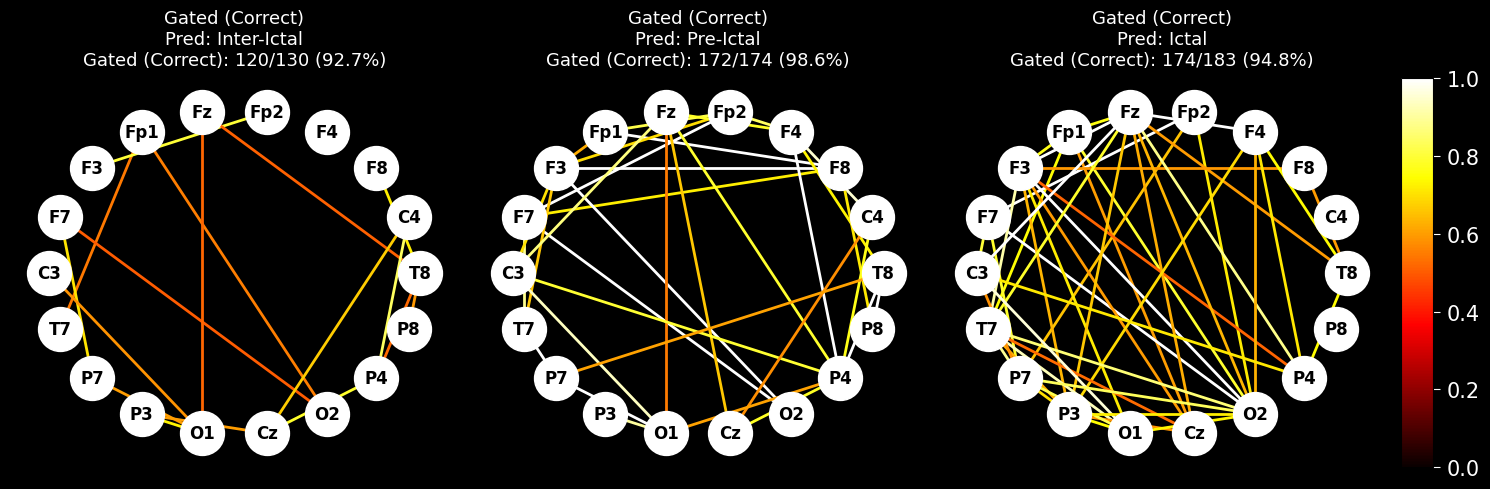

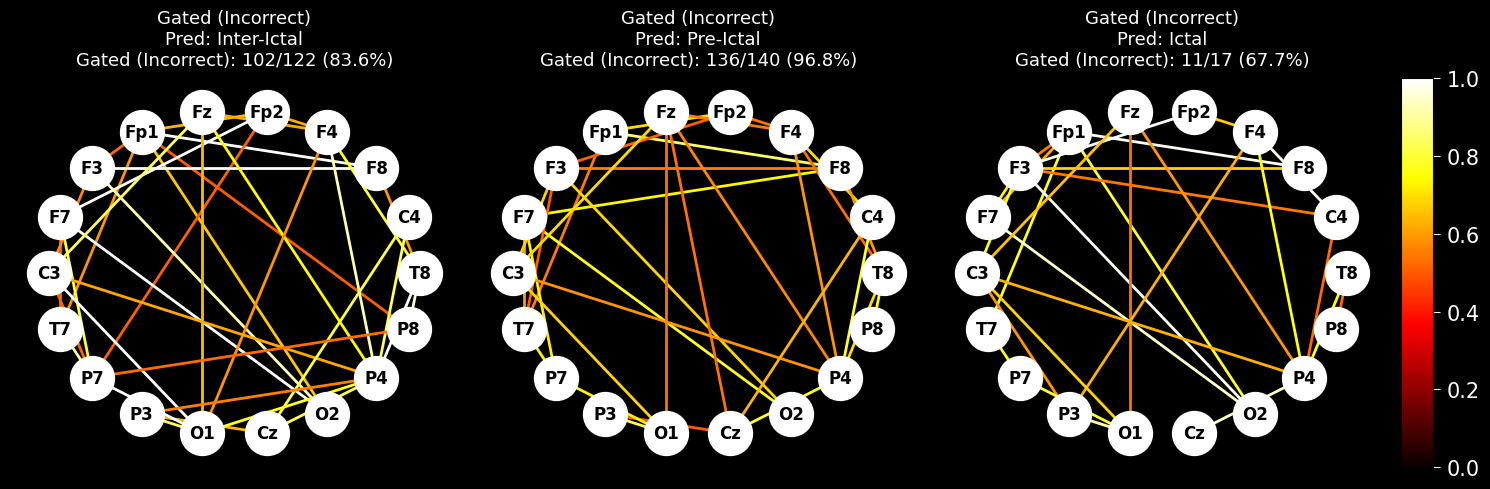

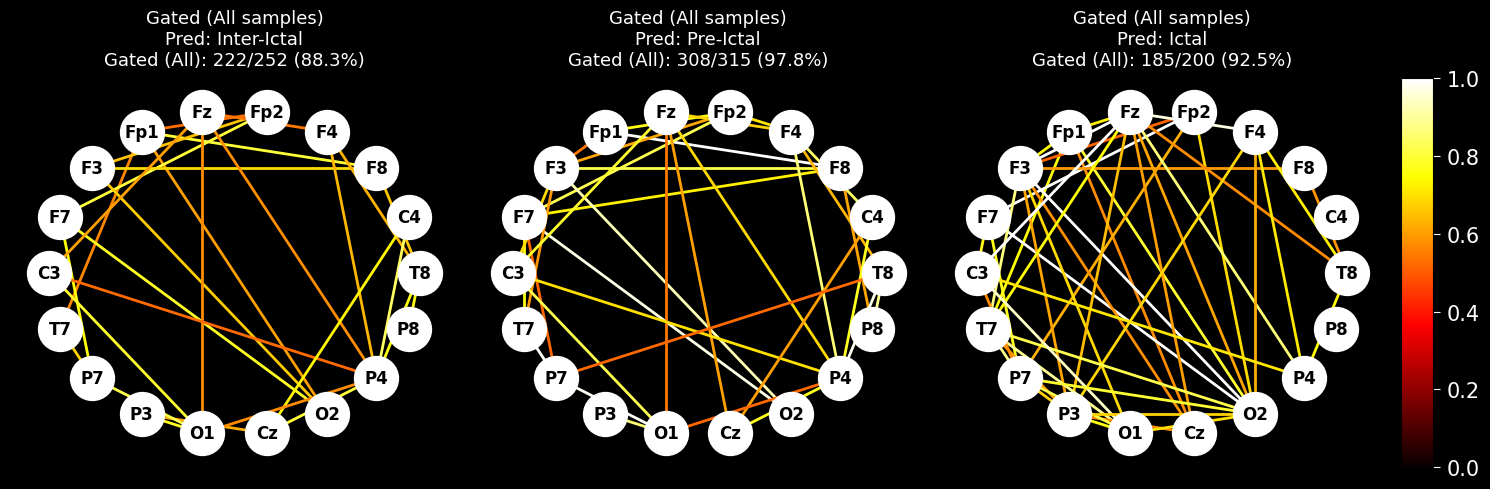


Analyzing Gated Predictions: chb23
Applying Uncertainty Gate tau = 0.1483899914 for patient chb23

PEARSON CORRELATION METRICS (GATED ANALYSIS) - CHB23 (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal                                  0.0608                                    0.3434                               -0.2341
Pred: Pre-Ictal                                    0.8234                                    0.3330                                0.2294
Pred: Ictal                                        0.9996                                   -0.0234                               -0.0313

SPEARMAN CORRELATION METRICS (GATED ANALYSIS) - CHB23 (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal                                  0.4422         

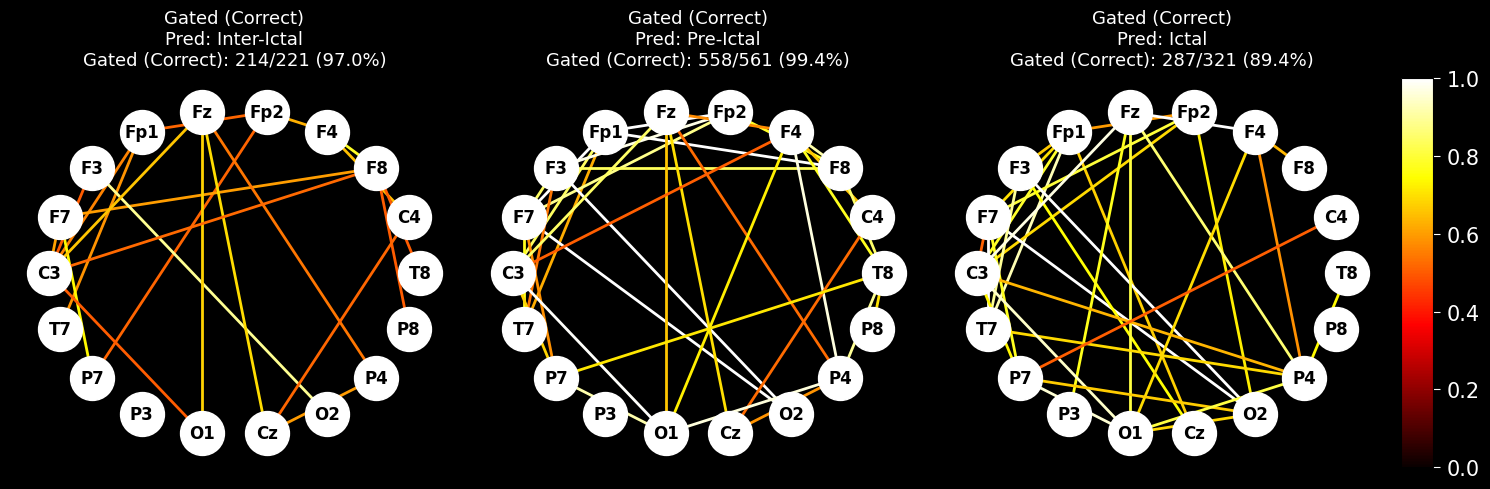

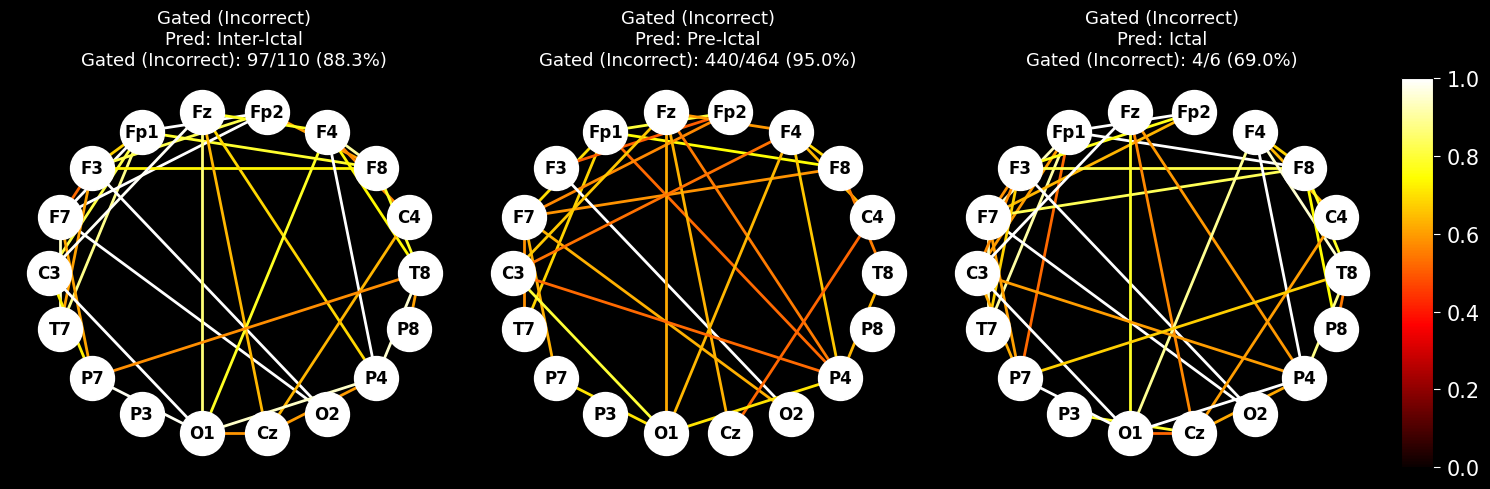

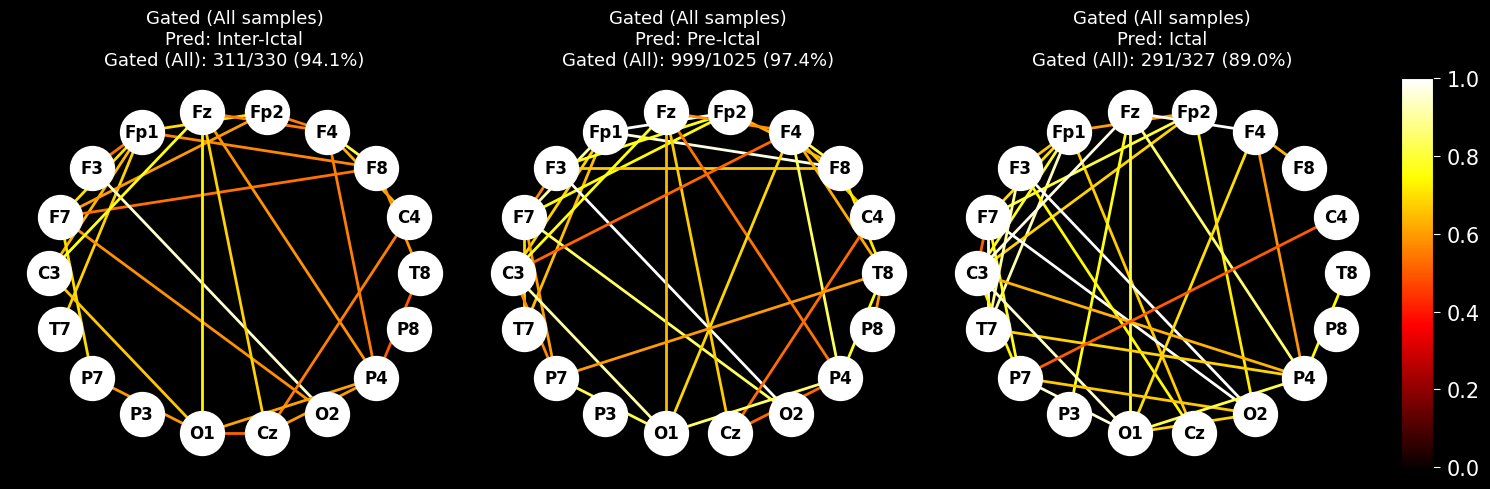


Analyzing Gated Predictions: chb24
Applying Uncertainty Gate tau = 0.1483899914 for patient chb24

PEARSON CORRELATION METRICS (GATED ANALYSIS) - CHB24 (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal                                  0.3752                                    0.5230                                0.2127
Pred: Pre-Ictal                                    0.3617                                    0.3124                                0.0652
Pred: Ictal                                        0.7015                                   -0.2580                               -0.2921

SPEARMAN CORRELATION METRICS (GATED ANALYSIS) - CHB24 (Threshold = 0.5)
                   Gated (Correct) vs Gated (All samples)  Gated (Incorrect) vs Gated (All samples)  Gated (Incorrect) vs Gated (Correct)
Pred: Inter-Ictal                                  0.8087         

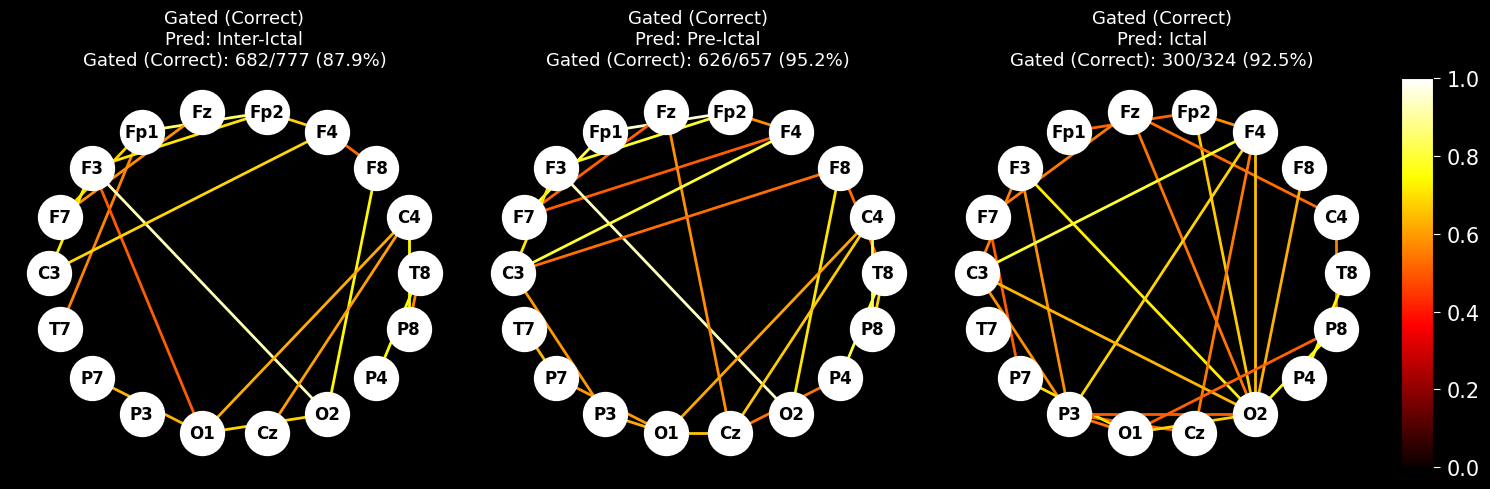

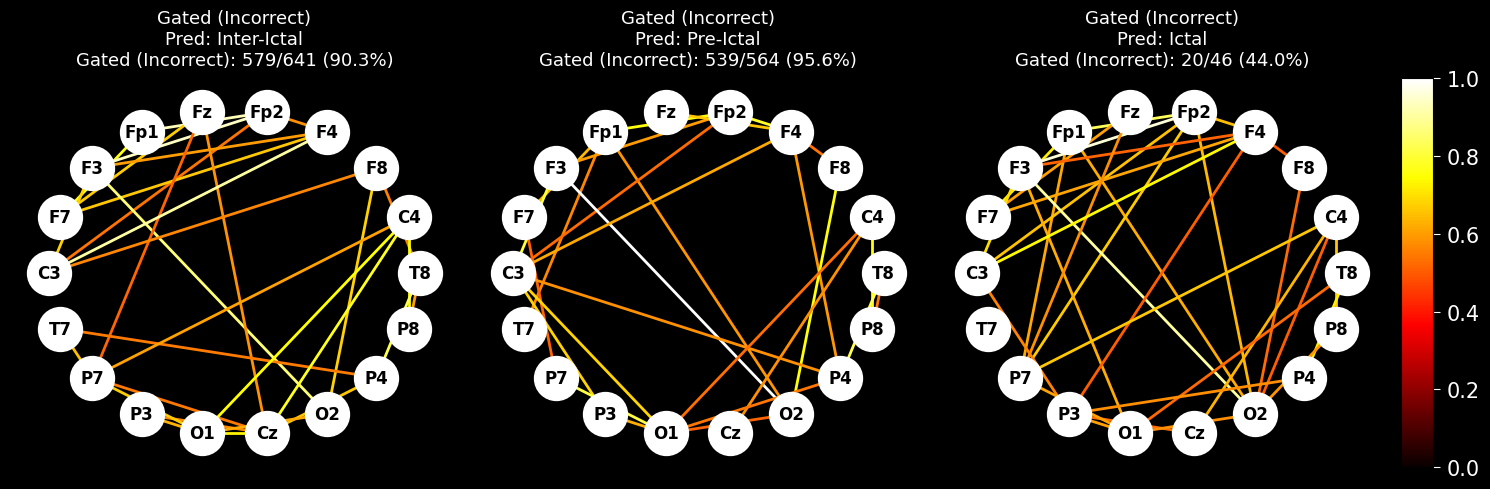

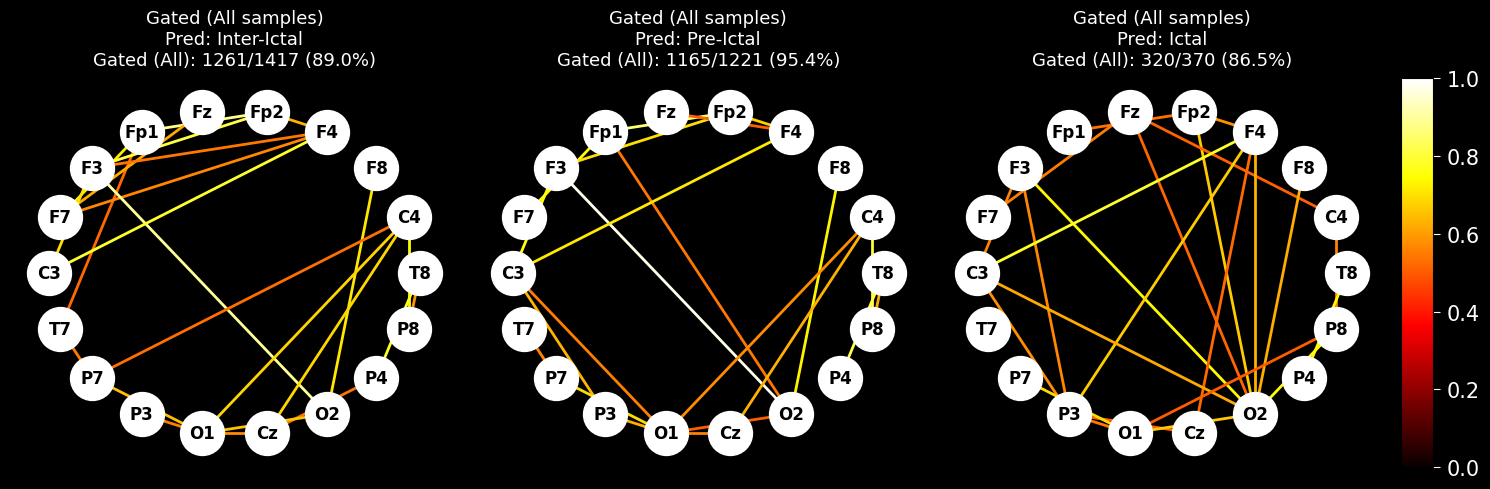

In [ ]:
import os
import json
import ast
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import torch_geometric
import scipy.stats as stats  
import pandas as pd          

# ==========================================
# 1. GRAPH HELPER FUNCTIONS & MAPPINGS
# ==========================================

def create_graph_from_dict(input_dict, self_loops=False, threshold=0.0):
    """Helper function to create a graph from a dictionary of edges."""
    g = nx.Graph()
    nodes = np.arange(18)
    g.add_nodes_from(nodes)
    for edge, value in input_dict.items():
        if value < threshold:
            continue
        if self_loops:
            g.add_edge(*edge, strength=value)
        else:
            if edge[0] != edge[1]:
                g.add_edge(*edge, strength=value)
    return g

def reverse_dict(d):
    return {v: k for k, v in d.items()}

# Channel Setup
ch_names_current = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "T7", "C3", "Cz", "C4", "T8", "P7", "P3", "P4", "P8", "O1", "O2"]
ch_dict_current = {ch_name: idx for idx, ch_name in enumerate(ch_names_current)}
ch_names_target = ["T8", "C4", "F8", "F4", "Fp2", "Fz", "Fp1", "F3", "F7", "C3", "T7", "P7", "P3", "O1", "Cz", "O2", "P4", "P8"]

ch_dict_target = reverse_dict({ch_name: ch_dict_current[ch_name] for ch_name in ch_names_target})
ch_dict_current_rev = reverse_dict(ch_dict_current)
channel_mapping = reverse_dict(dict(zip(ch_dict_current_rev.keys(), ch_dict_target.keys())))
custom_labels = {n: ch_names_current[n] for n in range(len(ch_names_current))}

# ==========================================
# 2. RENDER PIPELINE
# ==========================================

def render_attention_graphs(masks_list, save_path, title_prefix="", subtitles=None):
    """Renders the ISBI layout (Interictal, Preictal, Ictal) and saves the figure."""
    fig, axes = plt.subplots(ncols=4, nrows=1, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1, 0.07]})
    axes = axes.ravel()
    cmap = plt.cm.hot
    
    titles = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    if subtitles is None:
        subtitles = ["", "", ""]
        
    for n, dict_att in enumerate(masks_list):
        torch_geometric.seed_everything(42)
        g = create_graph_from_dict(dict_att, threshold=0.5)
        edge_opacities = [strength for strength in nx.get_edge_attributes(g, "strength").values()]
        
        pos_circular = nx.circular_layout(g)
        pos_custom = {idx: pos_circular[channel_mapping[idx]] for idx in range(len(ch_names_current))}
        
        nx.draw(
            g,
            with_labels=True,
            labels=custom_labels,
            pos=pos_custom,
            font_weight="bold",
            edge_color=edge_opacities,
            width=2,
            node_size=1000,
            node_color="white",
            edge_cmap=cmap,
            ax=axes[n],
            edge_vmin=0,
            edge_vmax=1,
        )
        full_title = f"{title_prefix}\n{titles[n]}\n{subtitles[n]}" if subtitles[n] else f"{title_prefix}\n{titles[n]}"
        axes[n].set_title(full_title, color="white", fontsize=13, pad=10)

    cax = axes[-1]
    colorbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=cax)
    color = "white"
    colorbar.ax.yaxis.set_tick_params(color=color, labelcolor=color, size=5, labelrotation=0)
    colorbar.ax.tick_params(axis='y', which='major', pad=5, labelsize=15)
    
    fig.set_facecolor("black")
    fig.tight_layout()
    
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, facecolor=fig.get_facecolor())
    plt.show()

# ==========================================
# 3. TOPOLOGY SHIFT QUANTIFICATION
# ==========================================

def compute_matrix_correlation(dict1, dict2, threshold=0.5):
    """
    Computes Pearson and Spearman correlation between two edge dictionaries 
    strictly on the filtered masks (edges >= 0.5).
    """
    filtered_dict1 = {e: v for e, v in dict1.items() if v >= threshold}
    filtered_dict2 = {e: v for e, v in dict2.items() if v >= threshold}
    
    valid_edges = set(filtered_dict1.keys()).union(set(filtered_dict2.keys()))
    valid_edges = sorted(list(valid_edges))
    
    if len(valid_edges) < 2:
        return 0.0, 0.0
        
    vec1 = np.array([filtered_dict1.get(e, 0.0) for e in valid_edges])
    vec2 = np.array([filtered_dict2.get(e, 0.0) for e in valid_edges])
    
    if np.std(vec1) == 0 or np.std(vec2) == 0:
        return 0.0, 0.0
        
    pearson_corr, _ = stats.pearsonr(vec1, vec2)
    spearman_corr, _ = stats.spearmanr(vec1, vec2)
    
    return pearson_corr, spearman_corr

def save_topology_metrics(all_list, correct_list, incorrect_list, save_dir, patient):
    """Calculates and saves topology correlations as Pandas DataFrames per patient."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_correct_all, s_correct_all = compute_matrix_correlation(correct_list[i], all_list[i], threshold=0.5)
        p_incorrect_all, s_incorrect_all = compute_matrix_correlation(incorrect_list[i], all_list[i], threshold=0.5)
        p_incorrect_correct, s_incorrect_correct = compute_matrix_correlation(incorrect_list[i], correct_list[i], threshold=0.5)
        
        pearson_dict[cls] = {
            "Gated (Correct) vs Gated (All samples)": round(p_correct_all, 4),
            "Gated (Incorrect) vs Gated (All samples)": round(p_incorrect_all, 4),
            "Gated (Incorrect) vs Gated (Correct)": round(p_incorrect_correct, 4)
        }
        
        spearman_dict[cls] = {
            "Gated (Correct) vs Gated (All samples)": round(s_correct_all, 4),
            "Gated (Incorrect) vs Gated (All samples)": round(s_incorrect_all, 4),
            "Gated (Incorrect) vs Gated (Correct)": round(s_incorrect_correct, 4)
        }
    
    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS (GATED ANALYSIS) - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS (GATED ANALYSIS) - {patient.upper()} (Threshold = 0.5)")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save as CSVs with patient name
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_gated_{patient}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_gated_{patient}.csv"))
    
    # Save as a formatted text file with patient name
    with open(os.path.join(save_dir, f"topology_correlation_metrics_gated_{patient}.txt"), 'w') as f:
        f.write(f"Topology Shift Quantification Metrics (Gated Analysis) - {patient.upper()} (Threshold = 0.5)\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Topology metrics saved as tables to: {save_dir} for {patient}")
    
    return df_pearson, df_spearman

# ==========================================
# 4. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_samples(att_dir, unc_dir, threshold_file, patient):
    """
    Loads MC Dropout samples, applies Uncertainty Gate, and splits by correctness.
    Averages the masks and divides counts appropriately.
    """
    if not os.path.exists(threshold_file):
        raise FileNotFoundError(f"Cannot find threshold file at: {threshold_file}")
        
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        if not content:
            raise ValueError(f"The file {threshold_file} is empty!")
        tau = float(content)
        
    print(f"Applying Uncertainty Gate tau = {tau:.10f} for patient {patient}")

    folds = sorted([f for f in os.listdir(att_dir) if f.startswith("fold_")])
    
    # Dictionaries for Edge Accumulation grouped by Predict Label (0:Pre, 1:Ict, 2:Inter)
    all_dicts = {0: {}, 1: {}, 2: {}}
    correct_dicts = {0: {}, 1: {}, 2: {}}
    incorrect_dicts = {0: {}, 1: {}, 2: {}}
    
    # Counters for normalization
    count_total_all = {0: 0, 1: 0, 2: 0}
    count_total_correct = {0: 0, 1: 0, 2: 0}
    count_total_incorrect = {0: 0, 1: 0, 2: 0}
    
    count_retained_all = {0: 0, 1: 0, 2: 0}
    count_retained_correct = {0: 0, 1: 0, 2: 0}
    count_retained_incorrect = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        json_path = os.path.join(att_dir, fold, f"{patient}.json")
        npz_path = os.path.join(unc_dir, fold, f"{patient}_per_sample_data.npz")
        
        if not os.path.exists(json_path) or not os.path.exists(npz_path):
            continue
            
        with open(json_path, "r") as f:
            samples = json.load(f)
            
        unc_data = np.load(npz_path)
        pred_labels = unc_data["pred_labels"]
        epistemic_arr = unc_data["epistemic_entropy"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            edges = sample["edge_index"]
            masks = sample["edge_mask_base"]
            
            # Group by predicted label (from NPZ)
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            is_retained = (epistemic_arr[i] < tau)
            
            # Update Total Counts
            count_total_all[pred_label] += 1
            if is_correct:
                count_total_correct[pred_label] += 1
            else:
                count_total_incorrect[pred_label] += 1
                
            # Filter out dropped samples
            if not is_retained:
                continue
                
            # Update Retained Counts
            count_retained_all[pred_label] += 1
            if is_correct:
                count_retained_correct[pred_label] += 1
            else:
                count_retained_incorrect[pred_label] += 1
                
            # Accumulate Edges for Gated Samples
            for idx in range(len(masks)):
                u, v = edges[0][idx], edges[1][idx]
                edge_tup = tuple(sorted([u, v]))
                val = masks[idx]
                
                all_dicts[pred_label][edge_tup] = all_dicts[pred_label].get(edge_tup, 0) + val
                
                if is_correct:
                    correct_dicts[pred_label][edge_tup] = correct_dicts[pred_label].get(edge_tup, 0) + val
                else:
                    incorrect_dicts[pred_label][edge_tup] = incorrect_dicts[pred_label].get(edge_tup, 0) + val

    # Calculate final averages for GATED elements
    final_all = [
        {k: v / max(1, count_retained_all[2]) for k, v in all_dicts[2].items()},
        {k: v / max(1, count_retained_all[0]) for k, v in all_dicts[0].items()},
        {k: v / max(1, count_retained_all[1]) for k, v in all_dicts[1].items()}
    ]

    final_correct = [
        {k: v / max(1, count_retained_correct[2]) for k, v in correct_dicts[2].items()},
        {k: v / max(1, count_retained_correct[0]) for k, v in correct_dicts[0].items()},
        {k: v / max(1, count_retained_correct[1]) for k, v in correct_dicts[1].items()}
    ]
    
    final_incorrect = [
        {k: v / max(1, count_retained_incorrect[2]) for k, v in incorrect_dicts[2].items()},
        {k: v / max(1, count_retained_incorrect[0]) for k, v in incorrect_dicts[0].items()},
        {k: v / max(1, count_retained_incorrect[1]) for k, v in incorrect_dicts[1].items()}
    ]
    
    # -------------------------------------------------------------------------
    # SCALE LOGIC: Apply 10x division scaling for OOD counts
    # -------------------------------------------------------------------------
    def scale_down(num): 
        return math.floor((num / 10.0) + 0.5)
    
    all_stats = [
        f"Gated (All): {scale_down(count_retained_all[2])}/{scale_down(count_total_all[2])} ({(count_retained_all[2]/max(1, count_total_all[2]))*100:.1f}%)" if count_total_all[2] > 0 else "N/A",
        f"Gated (All): {scale_down(count_retained_all[0])}/{scale_down(count_total_all[0])} ({(count_retained_all[0]/max(1, count_total_all[0]))*100:.1f}%)" if count_total_all[0] > 0 else "N/A",
        f"Gated (All): {scale_down(count_retained_all[1])}/{scale_down(count_total_all[1])} ({(count_retained_all[1]/max(1, count_total_all[1]))*100:.1f}%)" if count_total_all[1] > 0 else "N/A"
    ]

    correct_stats = [
        f"Gated (Correct): {scale_down(count_retained_correct[2])}/{scale_down(count_total_correct[2])} ({(count_retained_correct[2]/max(1, count_total_correct[2]))*100:.1f}%)" if count_total_correct[2] > 0 else "N/A",
        f"Gated (Correct): {scale_down(count_retained_correct[0])}/{scale_down(count_total_correct[0])} ({(count_retained_correct[0]/max(1, count_total_correct[0]))*100:.1f}%)" if count_total_correct[0] > 0 else "N/A",
        f"Gated (Correct): {scale_down(count_retained_correct[1])}/{scale_down(count_total_correct[1])} ({(count_retained_correct[1]/max(1, count_total_correct[1]))*100:.1f}%)" if count_total_correct[1] > 0 else "N/A"
    ]
    
    incorrect_stats = [
        f"Gated (Incorrect): {scale_down(count_retained_incorrect[2])}/{scale_down(count_total_incorrect[2])} ({(count_retained_incorrect[2]/max(1, count_total_incorrect[2]))*100:.1f}%)" if count_total_incorrect[2] > 0 else "N/A",
        f"Gated (Incorrect): {scale_down(count_retained_incorrect[0])}/{scale_down(count_total_incorrect[0])} ({(count_retained_incorrect[0]/max(1, count_total_incorrect[0]))*100:.1f}%)" if count_total_incorrect[0] > 0 else "N/A",
        f"Gated (Incorrect): {scale_down(count_retained_incorrect[1])}/{scale_down(count_total_incorrect[1])} ({(count_retained_incorrect[1]/max(1, count_total_incorrect[1]))*100:.1f}%)" if count_total_incorrect[1] > 0 else "N/A"
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# 5. EXECUTION PIPELINE
# ==========================================

def run_analysis(att_dir, unc_dir, threshold_file, patient, save_dir):
    print(f"\n{'='*50}\nAnalyzing Gated Predictions: {patient}\n{'='*50}")

    try:
        all_masks, correct_masks, incorrect_masks, all_stats, correct_stats, incorrect_stats = process_mc_dropout_samples(
            att_dir=att_dir, 
            unc_dir=unc_dir,
            threshold_file=threshold_file,
            patient=patient
        )
        
        if all_masks is not None:
            df_pearson, df_spearman = save_topology_metrics(
                all_masks, 
                correct_masks, 
                incorrect_masks, 
                save_dir, 
                patient
            )

            # Plot 1: Gated (Correct)
            render_attention_graphs(
                correct_masks, 
                save_path=f"{save_dir}/connectivity_gated_correct_{patient}.pdf",
                title_prefix="Gated (Correct)",
                subtitles=correct_stats
            )
            
            # Plot 2: Gated (Incorrect)
            render_attention_graphs(
                incorrect_masks, 
                save_path=f"{save_dir}/connectivity_gated_incorrect_{patient}.pdf",
                title_prefix="Gated (Incorrect)",
                subtitles=incorrect_stats
            )
            
            # Plot 3: Gated (All Samples)
            render_attention_graphs(
                all_masks, 
                save_path=f"{save_dir}/connectivity_gated_all_{patient}.pdf",
                title_prefix="Gated (All samples)",
                subtitles=all_stats
            )
            
    except Exception as e:
        print(f"Error processing analysis for {patient}: {e}")


if __name__ == "__main__":
    # --- CONFIGURATION ---
    DIR_DROPOUT_ATT = "/dropout-edge-mask/save_edge_mask_ood_full"
    DIR_DROPOUT_UNC = "/dropout-results/save_unc_metrics_ood"
    
    THRESHOLD_FILE = "/epistemic_threshold.txt"
    SAVE_DIR_PLOTS = "/plots/attention_gated_analysis_ood"
    
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    
    for patient in OOD_PATIENTS:
        run_analysis(
            att_dir=DIR_DROPOUT_ATT, 
            unc_dir=DIR_DROPOUT_UNC, 
            threshold_file=THRESHOLD_FILE, 
            patient=patient,
            save_dir=SAVE_DIR_PLOTS
        )

## GNNExplainer ID Correct

In [ ]:
import os
import math
import torch
import numpy as np
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION AND CONSTANTS
# ==========================================

LOOKBACK = 600

# Base Directories (In-Distribution Data)
DIR_DROPOUT_ID = "/mc-dropout-node-mask/save_node_mask"
DIR_DROPOUT_UNC_ID = "/dropout-results/save_unc_metrics"

# File Paths
THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/feature_importances_correct_id"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_feature_correlation(arr1, arr2):
    """
    Calculates Pearson and Spearman correlation coefficients between two arrays.
    Returns 0.0 for both metrics if either array has zero variance, preventing division by zero errors.
    """
    if np.std(arr1) == 0 or np.std(arr2) == 0:
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(ungated_list, retained_list, dropped_list, save_dir, display_name, count_correct, count_retained):
    """Calculates and saves feature importance correlations as Pandas DataFrames."""
    classes = ["Inter-Ictal", "Pre-Ictal", "Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of correct predictions that passed the uncertainty gate
        correct_count = count_correct[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, correct_count)) * 100:.1f}%"
        
        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_feature_correlation(ungated_list[i], retained_list[i])
        pearson_rd, spearman_rd = compute_feature_correlation(retained_list[i], dropped_list[i])
        
        pearson_dict[cls] = {
            "Ungated vs Gated (Retained)": round(pearson_ur, 4), 
            "Gated (Retained) vs Gated (Dropped)": round(pearson_rd, 4), 
            "Retained %": ret_pct
        }
            
        spearman_dict[cls] = {
            "Ungated vs Gated (Retained)": round(spearman_ur, 4), 
            "Gated (Retained) vs Gated (Dropped)": round(spearman_rd, 4), 
            "Retained %": ret_pct
        }

    # Convert mapping dictionaries to pandas DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the aggregated results
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS - FEATURE IMPORTANCE ({display_name})")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE ({display_name})")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save the DataFrames to CSV files
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_{display_name}.csv"))
    
    # Save a consolidated, human-readable text file
    with open(os.path.join(save_dir, f"feature_correlation_metrics_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics - {display_name}\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout(mask_dir, unc_dir, threshold_file, target_file, unc_file):
    """
    Reads PyTorch mask tensors and NumPy uncertainty arrays to isolate correct predictions.
    Separates the data into ungated, retained, and dropped categories based on the epistemic threshold.
    """
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f: 
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty.")
        
    tau = float(content)
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")
    
    # Initialize accumulators for 18 nodes and 10 features across 3 prediction classes
    ungated_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    retained_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    dropped_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Counters to track prediction totals per class
    count_correct = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Process each fold directory iteratively
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        is_correct_arr = unc_data["is_correct"]
        epistemic_arr = unc_data["epistemic_entropy"]
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            mask = sample["node_mask_base"]
            pred_label = pred_labels[i]
            
            # Enforce Correctness
            if pred_label != true_label or not is_correct_arr[i]: 
                continue
            
            # Accumulate the baseline (Ungated) metrics
            count_correct[true_label] += 1
            ungated_masks[true_label] += mask
            
            # Route data based on the uncertainty gate
            if epistemic_arr[i] < tau:
                retained_masks[true_label] += mask
                count_retained[true_label] += 1
            else:
                dropped_masks[true_label] += mask
                count_dropped[true_label] += 1

    # Average the masks and flatten across the 18 nodes (dim=0)
    # Order: Inter=2, Pre=0, Ict=1
    final_ungated = [
        (ungated_masks[2] / max(1, count_correct[2])).sum(dim=0).numpy(),
        (ungated_masks[0] / max(1, count_correct[0])).sum(dim=0).numpy(),
        (ungated_masks[1] / max(1, count_correct[1])).sum(dim=0).numpy()
    ]
    
    final_retained = [
        (retained_masks[2] / max(1, count_retained[2])).sum(dim=0).numpy(),
        (retained_masks[0] / max(1, count_retained[0])).sum(dim=0).numpy(),
        (retained_masks[1] / max(1, count_retained[1])).sum(dim=0).numpy()
    ]
    
    final_dropped = [
        (dropped_masks[2] / max(1, count_dropped[2])).sum(dim=0).numpy(),
        (dropped_masks[0] / max(1, count_dropped[0])).sum(dim=0).numpy(),
        (dropped_masks[1] / max(1, count_dropped[1])).sum(dim=0).numpy()
    ]
    
    return final_ungated, final_retained, final_dropped, count_correct, count_retained

# ==========================================
# 4. EXECUTION PIPELINE
# ==========================================

def run_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    """
    Constructs the necessary file paths and triggers the extraction and saving pipeline 
    for a specific dataset.
    """
    if is_ood:
        t_file = f"{target_name}.pt"
        u_file = f"{target_name}_per_sample_data.npz"
        d_name = target_name
    else:
        t_file = "test_data.pt"
        u_file = "per_sample_data.npz"
        d_name = "ID_Data"
    
    print("\n" + "="*80)
    print(f"Processing Feature Importances for: {d_name}")
    print("="*80)
    print("Running MC Dropout (Ungated vs Gated)...")
    
    try:
        ungated_imp, retained_imp, dropped_imp, count_correct, count_retained = process_mc_dropout(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            threshold_file=THRESHOLD_FILE, 
            target_file=t_file, 
            unc_file=u_file
        )
        
        if ungated_imp is not None:
            save_feature_metrics(
                ungated_list=ungated_imp, 
                retained_list=retained_imp, 
                dropped_list=dropped_imp, 
                save_dir=SAVE_DIR, 
                display_name=d_name, 
                count_correct=count_correct, 
                count_retained=count_retained
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {d_name}: {e}")

if __name__ == "__main__":
    
    # Execute the analysis strictly for In-Distribution (ID) Data
    run_analysis(
        mc_dir=DIR_DROPOUT_ID, 
        unc_dir=DIR_DROPOUT_UNC_ID, 
        target_name="", 
        is_ood=False
    )


Processing Feature Importances for: ID_Data
Running MC Dropout (Ungated vs Gated)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (ID_Data)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                       0.9999                               0.9512      93.7%
Pre-Ictal                         0.9999                               0.9021      95.8%
Ictal                             0.9998                               0.9537      95.3%

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (ID_Data)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                          1.0                               0.9273      93.7%
Pre-Ictal                            1.0                               0.8667      95.8%
Ictal                                1.0                               0.9515      95.3%


Feature correlation

## GNNExplainer ID Incorrect

In [ ]:
import os
import math
import torch
import numpy as np
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION AND CONSTANTS
# ==========================================

LOOKBACK = 600

# Base Directories (In-Distribution Data)
DIR_DROPOUT_ID = "/mc-dropout-node-mask/save_node_mask"
DIR_DROPOUT_UNC_ID = "/dropout-results/save_unc_metrics"

# File Paths
THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/feature_importances_incorrect_id"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_feature_correlation(arr1, arr2):
    """
    Calculates Pearson and Spearman correlation coefficients between two arrays.
    Returns 0.0 for both metrics if either array has zero variance, preventing division by zero errors.
    """
    if np.std(arr1) == 0 or np.std(arr2) == 0:
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(ungated_list, retained_list, dropped_list, save_dir, display_name, count_incorrect, count_retained):
    """Calculates and saves feature importance correlations as Pandas DataFrames."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of incorrect predictions that passed the uncertainty gate
        incorrect_count = count_incorrect[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, incorrect_count)) * 100:.1f}%"
        
        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_feature_correlation(ungated_list[i], retained_list[i])
        pearson_rd, spearman_rd = compute_feature_correlation(retained_list[i], dropped_list[i])
        
        pearson_dict[cls] = {
            "Ungated vs Incorrect (Retained)": round(pearson_ur, 4), 
            "Incorrect (Retained) vs Incorrect (Dropped)": round(pearson_rd, 4), 
            "Retained %": ret_pct
        }
            
        spearman_dict[cls] = {
            "Ungated vs Incorrect (Retained)": round(spearman_ur, 4), 
            "Incorrect (Retained) vs Incorrect (Dropped)": round(spearman_rd, 4), 
            "Retained %": ret_pct
        }

    # Convert mapping dictionaries to pandas DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the aggregated results
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE ({display_name})")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE ({display_name})")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save the DataFrames to CSV files
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_incorrect_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_incorrect_{display_name}.csv"))
    
    # Save a consolidated, human-readable text file
    with open(os.path.join(save_dir, f"feature_correlation_metrics_incorrect_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics (Incorrect Preds) - {display_name}\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_incorrect(mask_dir, unc_dir, threshold_file, target_file, unc_file, is_ood):
    """
    Reads PyTorch mask tensors and NumPy uncertainty arrays to isolate incorrect predictions.
    Separates the data into ungated, retained, and dropped categories based on the epistemic threshold.
    """
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f: 
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty.")
        
    tau = float(content)
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")
    
    # Initialize accumulators for 18 nodes and 10 features across 3 prediction classes
    ungated_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    retained_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    dropped_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Counters to track prediction totals per class
    count_incorrect = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Process each fold directory iteratively
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        is_correct_arr = unc_data["is_correct"]
        epistemic_arr = unc_data["epistemic_entropy"]
        pred_labels_arr = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            # Filter specifically for incorrect predictions
            if is_correct_arr[i]: 
                continue
                
            pred_label = pred_labels_arr[i]
            mask = sample["node_mask_base"]
            
            # Accumulate the baseline (Ungated) metrics
            count_incorrect[pred_label] += 1
            ungated_masks[pred_label] += mask
            
            # Route data based on the uncertainty gate
            if epistemic_arr[i] < tau:
                retained_masks[pred_label] += mask
                count_retained[pred_label] += 1
            else:
                dropped_masks[pred_label] += mask
                count_dropped[pred_label] += 1

    # Average the masks and flatten across the 18 nodes (dim=0)
    # Order: Inter=2, Pre=0, Ict=1
    final_ungated = [
        (ungated_masks[2] / max(1, count_incorrect[2])).sum(dim=0).numpy(),
        (ungated_masks[0] / max(1, count_incorrect[0])).sum(dim=0).numpy(),
        (ungated_masks[1] / max(1, count_incorrect[1])).sum(dim=0).numpy()
    ]
    
    final_retained = [
        (retained_masks[2] / max(1, count_retained[2])).sum(dim=0).numpy(),
        (retained_masks[0] / max(1, count_retained[0])).sum(dim=0).numpy(),
        (retained_masks[1] / max(1, count_retained[1])).sum(dim=0).numpy()
    ]
    
    final_dropped = [
        (dropped_masks[2] / max(1, count_dropped[2])).sum(dim=0).numpy(),
        (dropped_masks[0] / max(1, count_dropped[0])).sum(dim=0).numpy(),
        (dropped_masks[1] / max(1, count_dropped[1])).sum(dim=0).numpy()
    ]
    
    return final_ungated, final_retained, final_dropped, count_incorrect, count_retained

# ==========================================
# 4. EXECUTION PIPELINE
# ==========================================

def run_incorrect_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    """
    Constructs the necessary file paths and triggers the extraction and saving pipeline 
    for a specific dataset.
    """
    if is_ood:
        t_file = f"{target_name}.pt"
        u_file = f"{target_name}_per_sample_data.npz"
        d_name = target_name
    else:
        t_file = "test_data.pt"
        u_file = "per_sample_data.npz"
        d_name = "ID_Data"
    
    print("\n" + "="*80)
    print(f"Processing INCORRECT Feature Importances for: {d_name}")
    print("="*80)
    print("Running Uncertainty-Gated MC Dropout (Incorrect Predictions)...")
    
    try:
        ungated_imp, retained_imp, dropped_imp, count_incorrect, count_retained = process_mc_dropout_incorrect(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            threshold_file=THRESHOLD_FILE, 
            target_file=t_file, 
            unc_file=u_file, 
            is_ood=is_ood
        )
        
        if ungated_imp is not None:
            save_feature_metrics(
                ungated_list=ungated_imp, 
                retained_list=retained_imp, 
                dropped_list=dropped_imp, 
                save_dir=SAVE_DIR, 
                display_name=d_name, 
                count_incorrect=count_incorrect, 
                count_retained=count_retained
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {d_name}: {e}")

if __name__ == "__main__":
    
    # Execute the analysis strictly for In-Distribution (ID) Data
    run_incorrect_analysis(
        mc_dir=DIR_DROPOUT_ID, 
        unc_dir=DIR_DROPOUT_UNC_ID, 
        target_name="", 
        is_ood=False
    )


Processing INCORRECT Feature Importances for: ID_Data
Running Uncertainty-Gated MC Dropout (Incorrect Predictions)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE (ID_Data)
                   Ungated vs Incorrect (Retained)  Incorrect (Retained) vs Incorrect (Dropped) Retained %
Pred: Inter-Ictal                           1.0000                                       0.9732      93.9%
Pred: Pre-Ictal                             1.0000                                       0.9581      96.2%
Pred: Ictal                                 0.9793                                       0.8957      55.3%

SPEARMAN CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE (ID_Data)
                   Ungated vs Incorrect (Retained)  Incorrect (Retained) vs Incorrect (Dropped) Retained %
Pred: Inter-Ictal                           1.0000                                       0.9515      93.9%
Pred: Pre-Ictal                   

## GNNExplainer OOD Correct

In [ ]:
import os
import math
import torch
import numpy as np
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION AND CONSTANTS
# ==========================================

LOOKBACK = 600

# Base Directories for Out-Of-Distribution (OOD) Data
DIR_DROPOUT_OOD = "/mc-dropout-node-mask/save_node_mask_ood"
DIR_DROPOUT_UNC_OOD = "/dropout-results/save_unc_metrics_ood"

# File Paths
THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/feature_importances_correct_ood"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_feature_correlation(arr1, arr2):
    """
    Calculates Pearson and Spearman correlation coefficients between two arrays.
    Returns 0.0 for both metrics if either array has zero variance, preventing division by zero errors.
    """
    if np.std(arr1) == 0 or np.std(arr2) == 0:
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(ungated_list, retained_list, dropped_list, save_dir, display_name, count_correct, count_retained):
    """Generates and saves correlation matrices for correct predictions."""
    classes = ["Inter-Ictal", "Pre-Ictal", "Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of correct predictions that passed the uncertainty gate
        correct_count = count_correct[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, correct_count)) * 100:.1f}%"

        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_feature_correlation(ungated_list[i], retained_list[i])
        pearson_rd, spearman_rd = compute_feature_correlation(retained_list[i], dropped_list[i])
        
        pearson_dict[cls] = {
            "Ungated vs Gated (Retained)": round(pearson_ur, 4),
            "Gated (Retained) vs Gated (Dropped)": round(pearson_rd, 4),
            "Retained %": ret_pct
        }

        spearman_dict[cls] = {
            "Ungated vs Gated (Retained)": round(spearman_ur, 4),
            "Gated (Retained) vs Gated (Dropped)": round(spearman_rd, 4),
            "Retained %": ret_pct
        }

    # Convert mapping dictionaries to pandas DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the aggregated results
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save the DataFrames to CSV files
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_{display_name}.csv"))
    
    # Save a consolidated, human-readable text file
    with open(os.path.join(save_dir, f"feature_correlation_metrics_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics - {display_name.upper()}\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir} for {display_name}")
    
    return df_pearson, df_spearman

# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout(mask_dir, unc_dir, threshold_file, target_file, unc_file):
    """
    Reads PyTorch mask tensors and NumPy uncertainty arrays to isolate correct predictions.
    Separates the data into ungated, retained, and dropped categories based on the epistemic threshold.
    """
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty.")
        
    tau = float(content)
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")
    
    # Initialize accumulators for 18 nodes and 10 features across 3 prediction classes
    ungated_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    retained_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    dropped_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Counters to track prediction totals per class
    count_correct = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Process each fold directory iteratively
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        is_correct_arr = unc_data["is_correct"]
        epistemic_arr = unc_data["epistemic_entropy"]
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            mask = sample["node_mask_base"]
            pred_label = pred_labels[i]
            
            # Enforce Correctness
            if pred_label != true_label or not is_correct_arr[i]: 
                continue
            
            # Accumulate the baseline (Ungated) metrics
            count_correct[true_label] += 1
            ungated_masks[true_label] += mask
            
            # Route data based on the uncertainty gate
            if epistemic_arr[i] < tau:
                retained_masks[true_label] += mask
                count_retained[true_label] += 1
            else:
                dropped_masks[true_label] += mask
                count_dropped[true_label] += 1

    # Average the masks and flatten across the 18 nodes (dim=0)
    # Order: Inter=2, Pre=0, Ict=1
    final_ungated = [
        (ungated_masks[2] / max(1, count_correct[2])).sum(dim=0).numpy(),
        (ungated_masks[0] / max(1, count_correct[0])).sum(dim=0).numpy(),
        (ungated_masks[1] / max(1, count_correct[1])).sum(dim=0).numpy()
    ]
    
    final_retained = [
        (retained_masks[2] / max(1, count_retained[2])).sum(dim=0).numpy(),
        (retained_masks[0] / max(1, count_retained[0])).sum(dim=0).numpy(),
        (retained_masks[1] / max(1, count_retained[1])).sum(dim=0).numpy()
    ]
    
    final_dropped = [
        (dropped_masks[2] / max(1, count_dropped[2])).sum(dim=0).numpy(),
        (dropped_masks[0] / max(1, count_dropped[0])).sum(dim=0).numpy(),
        (dropped_masks[1] / max(1, count_dropped[1])).sum(dim=0).numpy()
    ]
    
    return final_ungated, final_retained, final_dropped, count_correct, count_retained

# ==========================================
# 4. EXECUTION PIPELINE
# ==========================================

def run_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    """
    Constructs the necessary file paths and triggers the extraction and saving pipeline 
    for a specific dataset or patient.
    """
    if is_ood:
        t_file = f"{target_name}.pt"
        u_file = f"{target_name}_per_sample_data.npz"
        d_name = target_name
    else:
        t_file = "test_data.pt"
        u_file = "per_sample_data.npz"
        d_name = "ID_Data"
    
    print("\n" + "="*80)
    print(f"Processing Feature Importances for: {d_name}")
    print("="*80)
    print("Running MC Dropout (Ungated vs Gated)...")
    
    try:
        ungated_imp, retained_imp, dropped_imp, count_correct, count_retained = process_mc_dropout(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            threshold_file=THRESHOLD_FILE, 
            target_file=t_file, 
            unc_file=u_file
        )
        
        if ungated_imp is not None:
            save_feature_metrics(
                ungated_list=ungated_imp, 
                retained_list=retained_imp, 
                dropped_list=dropped_imp, 
                save_dir=SAVE_DIR, 
                display_name=d_name, 
                count_correct=count_correct, 
                count_retained=count_retained
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {d_name}: {e}")

if __name__ == "__main__":
    
    # Execute the analysis strictly over the Out-Of-Distribution patient list
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    
    for patient in OOD_PATIENTS:
        run_analysis(
            mc_dir=DIR_DROPOUT_OOD, 
            unc_dir=DIR_DROPOUT_UNC_OOD, 
            target_name=patient, 
            is_ood=True
        )


Processing Feature Importances for: chb22
Running MC Dropout (Ungated vs Gated)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (CHB22)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                       0.9999                               0.9590      92.7%
Pre-Ictal                         1.0000                               0.9247      98.6%
Ictal                             0.9998                               0.9132      94.8%

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (CHB22)
             Ungated vs Gated (Retained)  Gated (Retained) vs Gated (Dropped) Retained %
Inter-Ictal                          1.0                               0.9273      92.7%
Pre-Ictal                            1.0                               0.9152      98.6%
Ictal                                1.0                               0.8909      94.8%


Feature correlation metri

## GNNExplainer OOD Incorrect

In [ ]:
import os
import math
import torch
import numpy as np
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION AND CONSTANTS
# ==========================================

LOOKBACK = 600

# Base Directories for Out-Of-Distribution (OOD) Data
DIR_DROPOUT_OOD = "/mc-dropout-node-mask/save_node_mask_ood"
DIR_DROPOUT_UNC_OOD = "/dropout-results/save_unc_metrics_ood"

# File Paths
THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR = "/metrics/feature_importances_incorrect_ood"

# Ensure output directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. CORE PROCESSING FUNCTIONS
# ==========================================

def compute_feature_correlation(arr1, arr2):
    """
    Calculates Pearson and Spearman correlation coefficients between two arrays.
    Returns 0.0 for both metrics if either array has zero variance, preventing division by zero errors.
    """
    if np.std(arr1) == 0 or np.std(arr2) == 0: 
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(ungated_list, retained_list, dropped_list, save_dir, display_name, count_incorrect, count_retained):
    """Generates and saves correlation matrices for incorrect predictions."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1]
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        # Calculate the percentage of incorrect predictions that passed the uncertainty gate
        incorrect_count = count_incorrect[keys[i]]
        retained_count = count_retained[keys[i]]
        ret_pct = f"{(retained_count / max(1, incorrect_count)) * 100:.1f}%"
        
        # Compute correlations across the different gating stages
        pearson_ur, spearman_ur = compute_feature_correlation(ungated_list[i], retained_list[i])
        pearson_rd, spearman_rd = compute_feature_correlation(retained_list[i], dropped_list[i])
        
        pearson_dict[cls] = {
            "Ungated vs Incorrect (Retained)": round(pearson_ur, 4), 
            "Incorrect (Retained) vs Incorrect (Dropped)": round(pearson_rd, 4), 
            "Retained %": ret_pct
        }
            
        spearman_dict[cls] = {
            "Ungated vs Incorrect (Retained)": round(spearman_ur, 4), 
            "Incorrect (Retained) vs Incorrect (Dropped)": round(spearman_rd, 4), 
            "Retained %": ret_pct
        }

    # Convert mapping dictionaries to pandas DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the aggregated results
    print("\n" + "="*80)
    print(f"PEARSON CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*80)
    print(df_pearson.to_string())
    
    print("\n" + "="*80)
    print(f"SPEARMAN CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*80)
    print(df_spearman.to_string())
    print("\n")
    
    # Save the DataFrames to CSV files
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_incorrect_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_incorrect_{display_name}.csv"))
    
    # Save a consolidated, human-readable text file
    with open(os.path.join(save_dir, f"feature_correlation_metrics_incorrect_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics (Incorrect Preds) - {display_name.upper()}\n")
        f.write("="*80 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir} for {display_name}")
    
    return df_pearson, df_spearman

# ==========================================
# 3. DATA PROCESSING PIPELINE
# ==========================================

def process_mc_dropout_incorrect(mask_dir, unc_dir, threshold_file, target_file, unc_file):
    """
    Reads PyTorch mask tensors and NumPy uncertainty arrays to isolate incorrect predictions.
    Separates the data into ungated, retained, and dropped categories based on the epistemic threshold.
    """
    # Read the established epistemic uncertainty threshold
    with open(threshold_file, "r") as f:
        content = f.read().strip()
        
    if not content:
        raise ValueError(f"The file {threshold_file} is empty.")
        
    tau = float(content)
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")
    
    # Initialize accumulators for 18 nodes and 10 features across 3 prediction classes
    ungated_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    retained_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    dropped_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Counters to track prediction totals per class
    count_incorrect = {0: 0, 1: 0, 2: 0}
    count_retained = {0: 0, 1: 0, 2: 0}
    count_dropped = {0: 0, 1: 0, 2: 0}
    
    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Process each fold directory iteratively
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        # Ensure both required files exist before attempting to load
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        is_correct_arr = unc_data["is_correct"]
        epistemic_arr = unc_data["epistemic_entropy"]
        pred_labels_arr = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            # Filter specifically for incorrect predictions
            if is_correct_arr[i]: 
                continue
                
            pred_label = pred_labels_arr[i]
            mask = sample["node_mask_base"]
            
            # Accumulate the baseline (Ungated) metrics
            count_incorrect[pred_label] += 1
            ungated_masks[pred_label] += mask
            
            # Route data based on the uncertainty gate
            if epistemic_arr[i] < tau:
                retained_masks[pred_label] += mask
                count_retained[pred_label] += 1
            else:
                dropped_masks[pred_label] += mask
                count_dropped[pred_label] += 1

    # Average the masks and flatten across the 18 nodes (dim=0)
    # Order: Inter=2, Pre=0, Ict=1
    final_ungated = [
        (ungated_masks[2] / max(1, count_incorrect[2])).sum(dim=0).numpy(),
        (ungated_masks[0] / max(1, count_incorrect[0])).sum(dim=0).numpy(),
        (ungated_masks[1] / max(1, count_incorrect[1])).sum(dim=0).numpy()
    ]
    
    final_retained = [
        (retained_masks[2] / max(1, count_retained[2])).sum(dim=0).numpy(),
        (retained_masks[0] / max(1, count_retained[0])).sum(dim=0).numpy(),
        (retained_masks[1] / max(1, count_retained[1])).sum(dim=0).numpy()
    ]
    
    final_dropped = [
        (dropped_masks[2] / max(1, count_dropped[2])).sum(dim=0).numpy(),
        (dropped_masks[0] / max(1, count_dropped[0])).sum(dim=0).numpy(),
        (dropped_masks[1] / max(1, count_dropped[1])).sum(dim=0).numpy()
    ]
    
    return final_ungated, final_retained, final_dropped, count_incorrect, count_retained

# ==========================================
# 4. EXECUTION PIPELINE
# ==========================================

def run_incorrect_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    """
    Constructs the necessary file paths and triggers the extraction and saving pipeline 
    for a specific dataset or patient.
    """
    if is_ood:
        t_file = f"{target_name}.pt"
        u_file = f"{target_name}_per_sample_data.npz"
        d_name = target_name
    else:
        t_file = "test_data.pt"
        u_file = "per_sample_data.npz"
        d_name = "ID_Data"
    
    print("\n" + "="*80)
    print(f"Processing INCORRECT Feature Importances for: {d_name}")
    print("="*80)
    print("Running Uncertainty-Gated MC Dropout (Incorrect Predictions)...")
    
    try:
        ungated_imp, retained_imp, dropped_imp, count_incorrect, count_retained = process_mc_dropout_incorrect(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            threshold_file=THRESHOLD_FILE, 
            target_file=t_file, 
            unc_file=u_file
        )
        
        if ungated_imp is not None:
            save_feature_metrics(
                ungated_list=ungated_imp, 
                retained_list=retained_imp, 
                dropped_list=dropped_imp, 
                save_dir=SAVE_DIR, 
                display_name=d_name, 
                count_incorrect=count_incorrect, 
                count_retained=count_retained
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {d_name}: {e}")

if __name__ == "__main__":
    
    # Execute the analysis strictly over the Out-Of-Distribution patient list
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    
    for patient in OOD_PATIENTS:
        run_incorrect_analysis(
            mc_dir=DIR_DROPOUT_OOD, 
            unc_dir=DIR_DROPOUT_UNC_OOD, 
            target_name=patient, 
            is_ood=True
        )


Processing INCORRECT Feature Importances for: chb22
Running Uncertainty-Gated MC Dropout (Incorrect Predictions)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE (CHB22)
                   Ungated vs Incorrect (Retained)  Incorrect (Retained) vs Incorrect (Dropped) Retained %
Pred: Inter-Ictal                           0.9997                                       0.9848      83.6%
Pred: Pre-Ictal                             1.0000                                       0.9088      96.8%
Pred: Ictal                                 0.9832                                       0.8608      67.7%

SPEARMAN CORRELATION METRICS (INCORRECT) - FEATURE IMPORTANCE (CHB22)
                   Ungated vs Incorrect (Retained)  Incorrect (Retained) vs Incorrect (Dropped) Retained %
Pred: Inter-Ictal                           0.9879                                       0.9515      83.6%
Pred: Pre-Ictal                         

## GNNExplainer - ID (Ungated All samples vs Ungated (Correct) Vs Ungated (Incorrect)


Processing Feature Importances for: ID_Data
Running MC Dropout (All vs Correct vs Incorrect)...

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (ID_Data)
                   All samples vs Correct  All samples vs Incorrect  Correct vs Incorrect
Pred: Inter-Ictal                  0.9998                    0.9982                0.9967
Pred: Pre-Ictal                    0.9996                    0.9980                0.9957
Pred: Ictal                        0.9995                    0.8313                0.8138

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (ID_Data)
                   All samples vs Correct  All samples vs Incorrect  Correct vs Incorrect
Pred: Inter-Ictal                     1.0                    0.9879                0.9879
Pred: Pre-Ictal                       1.0                    0.9879                0.9879
Pred: Ictal                           1.0                    0.8303                0.8303


Feature correlation metrics saved as tables to: /plots/featu

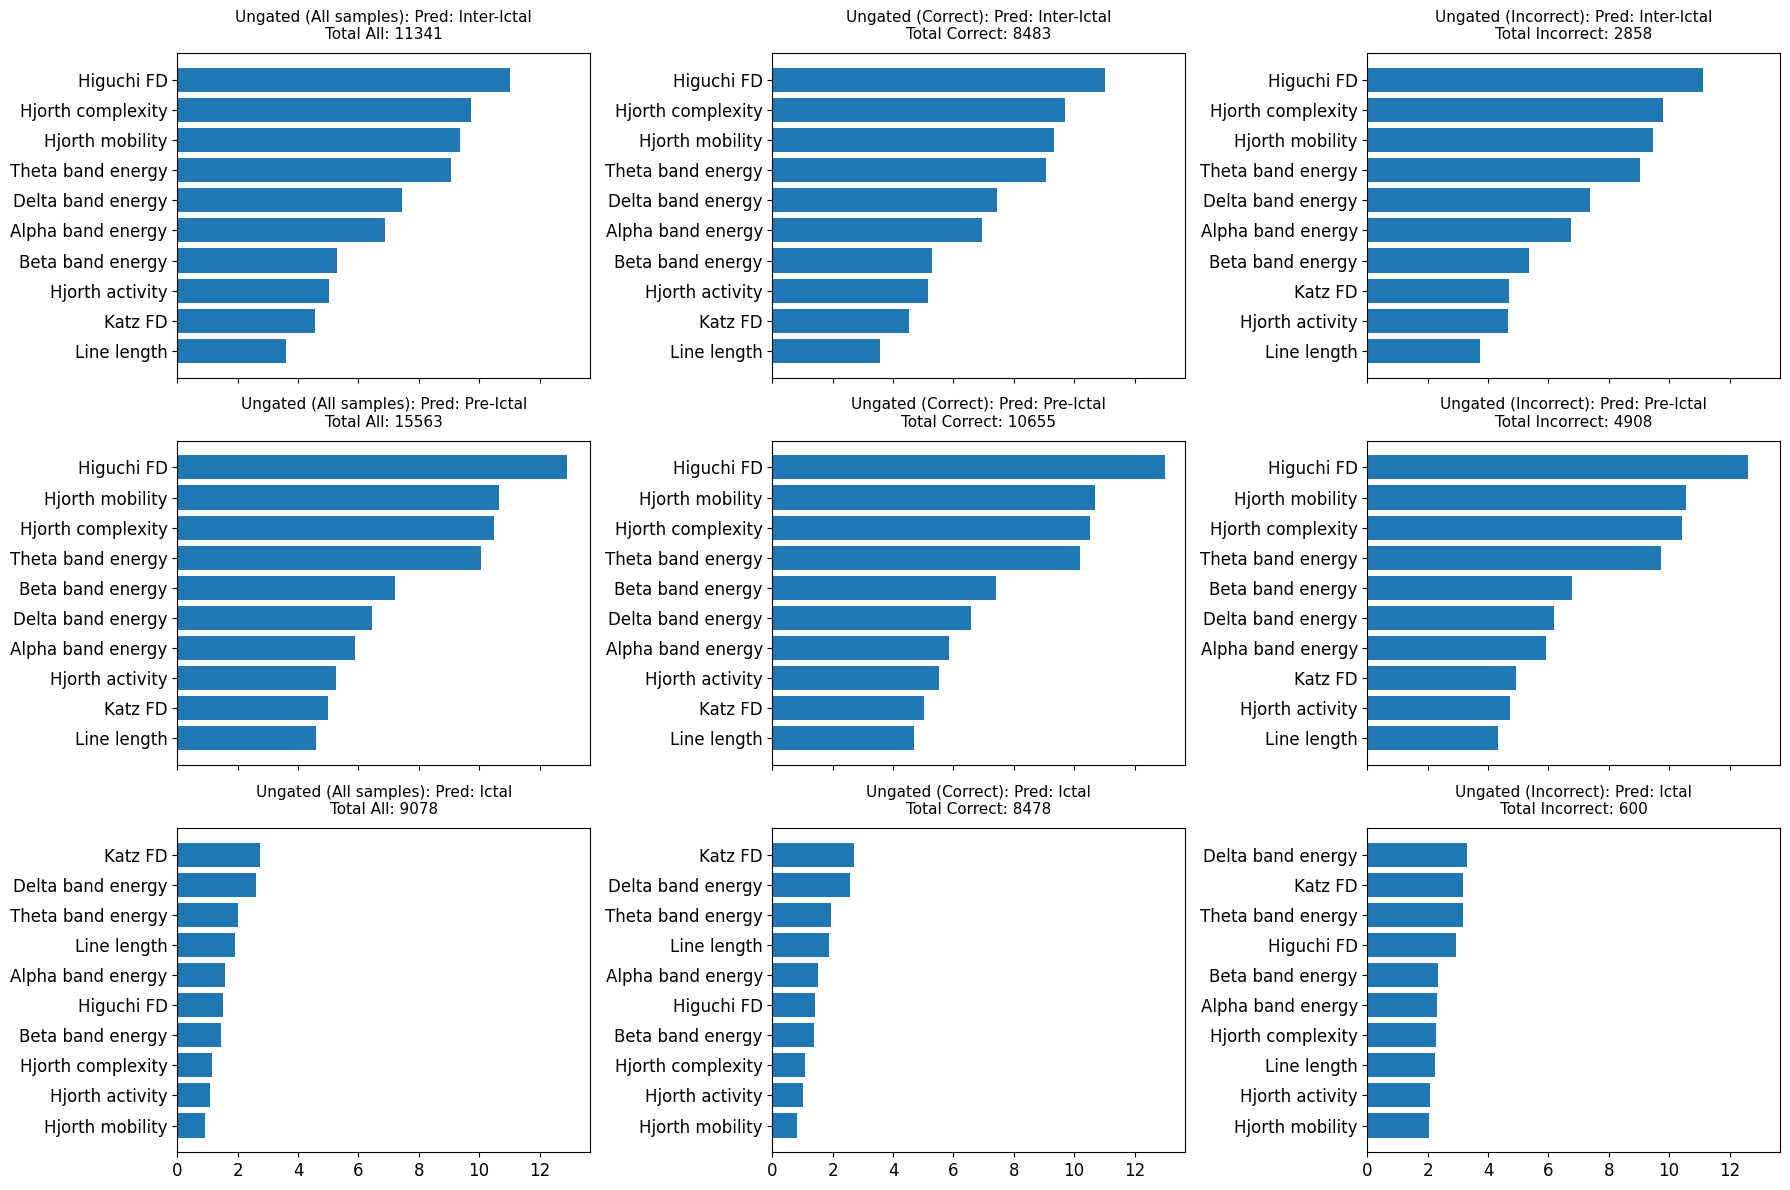

In [ ]:
import os
import json
import ast
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
LOOKBACK = 600

# Directories (Update these to exact paths)
DIR_DROPOUT_ID = "/mc-dropout-node-mask/save_node_mask"
DIR_DROPOUT_UNC_ID = "/dropout-results/save_unc_metrics"

SAVE_DIR_PLOTS = f"/plots/feature_importances_id_ungated"

FEATURE_LABELS = np.array([
    'Hjorth activity', 'Hjorth mobility', 'Hjorth complexity',
    "Line length", "Katz FD", "Higuchi FD", "Delta band energy",
    "Theta band energy", "Alpha band energy", "Beta band energy"
])

os.makedirs(SAVE_DIR_PLOTS, exist_ok=True)

# ==========================================
# FEATURE CORRELATION METRICS
# ==========================================
def compute_feature_correlation(arr1, arr2):
    """Computes Pearson and Spearman correlation between two feature importance arrays."""
    if np.std(arr1) == 0 or np.std(arr2) == 0:
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(all_list, correct_list, incorrect_list, save_dir, display_name):
    """Calculates and saves feature importance correlations as Pandas DataFrames."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1]
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_ac, s_ac = compute_feature_correlation(all_list[i], correct_list[i])
        p_ai, s_ai = compute_feature_correlation(all_list[i], incorrect_list[i])
        p_ci, s_ci = compute_feature_correlation(correct_list[i], incorrect_list[i])
        
        pearson_dict[cls] = {
            "All samples vs Correct": round(p_ac, 4),
            "All samples vs Incorrect": round(p_ai, 4),
            "Correct vs Incorrect": round(p_ci, 4)
        }
        
        spearman_dict[cls] = {
            "All samples vs Correct": round(s_ac, 4),
            "All samples vs Incorrect": round(s_ai, 4),
            "Correct vs Incorrect": round(s_ci, 4)
        }
    
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    print("\n" + "="*60)
    print(f"PEARSON CORRELATION METRICS - FEATURE IMPORTANCE ({display_name})")
    print("="*60)
    print(df_pearson.to_string())
    
    print("\n" + "="*60)
    print(f"SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE ({display_name})")
    print("="*60)
    print(df_spearman.to_string())
    print("\n")
    
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_{display_name}.csv"))
    
    with open(os.path.join(save_dir, f"feature_correlation_metrics_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics - {display_name}\n")
        f.write("="*60 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

# ==========================================
# PLOTTING HELPER FUNCTIONS
# ==========================================
def show_importances(scores, labels, ax, title=""):
    """Plots a horizontal bar chart of feature importances."""
    fontsize = 12
    sorted_indices = np.argsort(scores)
    sorted_scores = scores[sorted_indices]
    sorted_labels = labels[sorted_indices]

    ax.barh(range(len(sorted_scores)), sorted_scores)
    ax.set_yticks(range(len(sorted_scores)), sorted_labels)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.set_title(title, fontsize=11, pad=10)

def render_unified_feature_graphs(all_imp, correct_imp, incorrect_imp, save_path, display_name, all_stats, correct_stats, incorrect_stats):
    """Renders a 3x3 grid: Rows=Classes, Cols=[All, Correct, Incorrect]."""
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), sharex=True)
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    for i in range(3):
        # Column 0: All
        show_importances(all_imp[i], FEATURE_LABELS, axes[i, 0], 
                         title=f"Ungated (All samples): {classes[i]}\n{all_stats[i]}")
        # Column 1: Correct
        show_importances(correct_imp[i], FEATURE_LABELS, axes[i, 1], 
                         title=f"Ungated (Correct): {classes[i]}\n{correct_stats[i]}")
        # Column 2: Incorrect
        show_importances(incorrect_imp[i], FEATURE_LABELS, axes[i, 2], 
                         title=f"Ungated (Incorrect): {classes[i]}\n{incorrect_stats[i]}")

    plt.tight_layout()
    fig.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show() 
    plt.close()

# ==========================================
# MC DROPOUT PROCESSING (ALL VS CORRECT VS INCORRECT)
# ==========================================

def process_mc_dropout(mask_dir, unc_dir, target_file, unc_file, is_ood):
    """Cross-references PT masks with NPZ metrics and splits by Correctness completely un-gated."""
    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Accumulators [18 nodes, 10 features]
    all_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    correct_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    incorrect_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Counters
    count_all = {0: 0, 1: 0, 2: 0}       
    count_correct = {0: 0, 1: 0, 2: 0}
    count_incorrect = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            mask = sample["node_mask_base"] 
            
            # Grouping by pred_label as specified
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            
            # Accumulate Ungated All
            count_all[pred_label] += 1
            all_masks[pred_label] += mask
            
            # Apply Correct/Incorrect Split
            if is_correct:
                correct_masks[pred_label] += mask
                count_correct[pred_label] += 1
            else:
                incorrect_masks[pred_label] += mask
                count_incorrect[pred_label] += 1

    # Average masks, then sum across 18 nodes (dim=0) to get 10 features
    final_all = [
        (all_masks[2] / max(1, count_all[2])).sum(dim=0).numpy(), 
        (all_masks[0] / max(1, count_all[0])).sum(dim=0).numpy(), 
        (all_masks[1] / max(1, count_all[1])).sum(dim=0).numpy()  
    ]

    final_correct = [
        (correct_masks[2] / max(1, count_correct[2])).sum(dim=0).numpy(), 
        (correct_masks[0] / max(1, count_correct[0])).sum(dim=0).numpy(), 
        (correct_masks[1] / max(1, count_correct[1])).sum(dim=0).numpy()  
    ]
    
    final_incorrect = [
        (incorrect_masks[2] / max(1, count_incorrect[2])).sum(dim=0).numpy(),
        (incorrect_masks[0] / max(1, count_incorrect[0])).sum(dim=0).numpy(),
        (incorrect_masks[1] / max(1, count_incorrect[1])).sum(dim=0).numpy()
    ]
    
    # SCALE LOGIC: Apply 10x division ONLY if it is OOD data
    def scale_down(num): 
        return math.floor((num / 10.0) + 0.5) if is_ood else num
    
    all_stats = [
        f"Total All: {scale_down(count_all[2])}",
        f"Total All: {scale_down(count_all[0])}",
        f"Total All: {scale_down(count_all[1])}"
    ]

    correct_stats = [
        f"Total Correct: {scale_down(count_correct[2])}",
        f"Total Correct: {scale_down(count_correct[0])}",
        f"Total Correct: {scale_down(count_correct[1])}"
    ]
    
    incorrect_stats = [
        f"Total Incorrect: {scale_down(count_incorrect[2])}",
        f"Total Incorrect: {scale_down(count_incorrect[0])}",
        f"Total Incorrect: {scale_down(count_incorrect[1])}"
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# EXECUTION PIPELINE
# ==========================================
def run_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    target_file = f"{target_name}.pt" if is_ood else "test_data.pt"
    unc_file = f"{target_name}_per_sample_data.npz" if is_ood else "per_sample_data.npz"
    display_name = target_name if is_ood else "ID_Data"
    
    print(f"\n{'='*50}\nProcessing Feature Importances for: {display_name}\n{'='*50}")
    print("Running MC Dropout (All vs Correct vs Incorrect)...")
    try:
        all_imp, correct_imp, incorrect_imp, all_stats, correct_stats, incorrect_stats = process_mc_dropout(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            target_file=target_file,
            unc_file=unc_file,
            is_ood=is_ood
        )
        
        if all_imp is not None:
            # Calculate and save the feature correlations
            save_feature_metrics(
                all_list=all_imp, 
                correct_list=correct_imp, 
                incorrect_list=incorrect_imp, 
                save_dir=SAVE_DIR_PLOTS, 
                display_name=display_name
            )
            
            # Generate the unified 3x3 plot 
            render_unified_feature_graphs(
                all_imp=all_imp, 
                correct_imp=correct_imp, 
                incorrect_imp=incorrect_imp,
                save_path=os.path.join(SAVE_DIR_PLOTS, f"unified_feature_importances_{display_name}.pdf"),
                display_name=display_name,
                all_stats=all_stats, 
                correct_stats=correct_stats, 
                incorrect_stats=incorrect_stats
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {display_name}: {e}")

if __name__ == "__main__":
    # 1. Run strictly for ID Data (No OOD Logic)
    run_analysis(
        mc_dir=DIR_DROPOUT_ID, 
        unc_dir=DIR_DROPOUT_UNC_ID, 
        target_name="", 
        is_ood=False
    )

## GNNExplainer - ID (Gated All samples vs Gated (Correct) Vs Gated (Incorrect)


Processing Feature Importances for: ID_Data
Running MC Dropout (All vs Correct vs Incorrect)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (ID_Data)
                   All samples vs Correct  All samples vs Incorrect  Correct vs Incorrect
Pred: Inter-Ictal                  0.9998                    0.9983                0.9970
Pred: Pre-Ictal                    0.9996                    0.9983                0.9962
Pred: Ictal                        0.9999                    0.9101                0.9042

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (ID_Data)
                   All samples vs Correct  All samples vs Incorrect  Correct vs Incorrect
Pred: Inter-Ictal                     1.0                    0.9879                0.9879
Pred: Pre-Ictal                       1.0                    0.9879                0.9879
Pred: Ictal                           1.0                    0.8667                0.8667




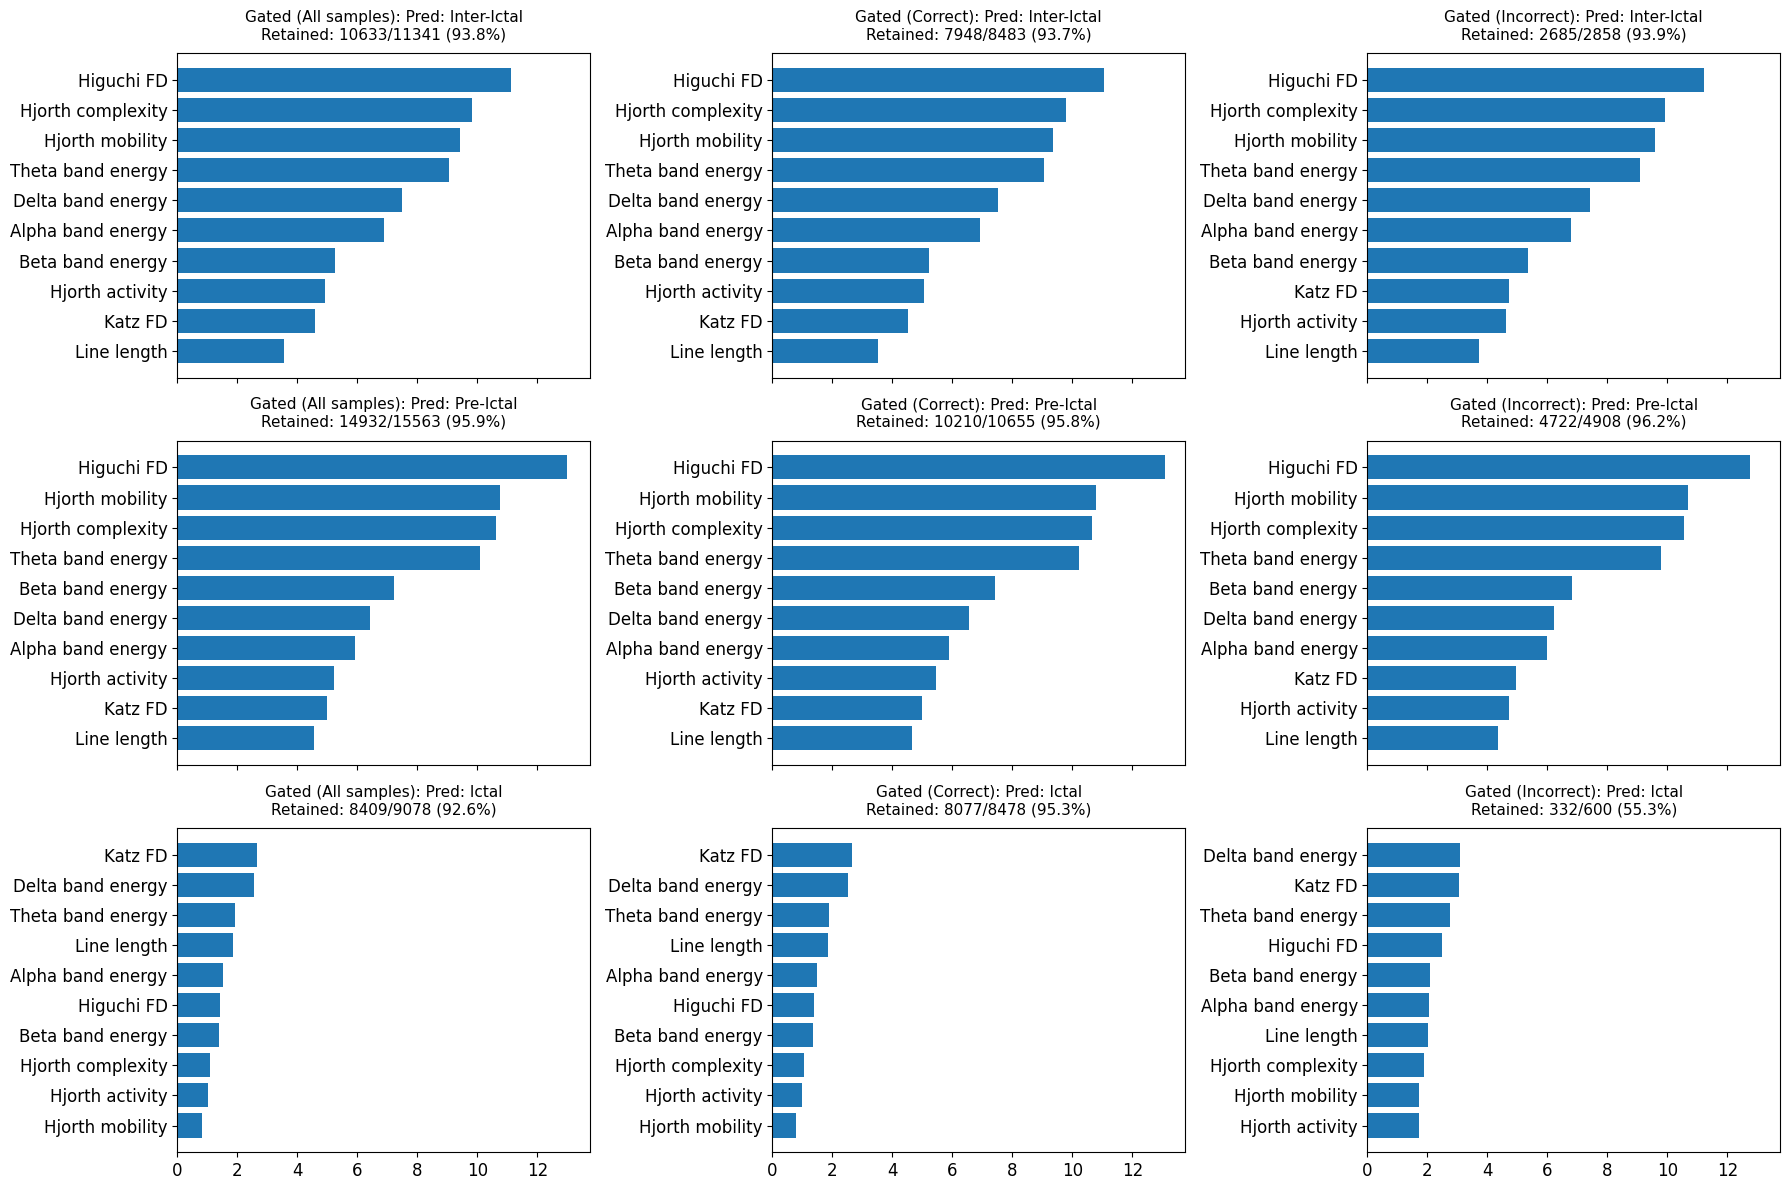

In [ ]:
import os
import json
import ast
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
LOOKBACK = 600

# Directories (Update these to exact paths)
DIR_DROPOUT_ID = "/mc-dropout-node-mask/save_node_mask"
DIR_DROPOUT_UNC_ID = "/dropout-results/save_unc_metrics"

THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR_PLOTS = f"/plots/feature_importances_id_gated"

FEATURE_LABELS = np.array([
    'Hjorth activity', 'Hjorth mobility', 'Hjorth complexity',
    "Line length", "Katz FD", "Higuchi FD", "Delta band energy",
    "Theta band energy", "Alpha band energy", "Beta band energy"
])

os.makedirs(SAVE_DIR_PLOTS, exist_ok=True)

# ==========================================
# FEATURE CORRELATION METRICS
# ==========================================
def compute_feature_correlation(arr1, arr2):
    """Computes Pearson and Spearman correlation between two feature importance arrays."""
    if np.std(arr1) == 0 or np.std(arr2) == 0:
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(all_list, correct_list, incorrect_list, save_dir, display_name):
    """Calculates and saves feature importance correlations as Pandas DataFrames."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1]
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_ac, s_ac = compute_feature_correlation(all_list[i], correct_list[i])
        p_ai, s_ai = compute_feature_correlation(all_list[i], incorrect_list[i])
        p_ci, s_ci = compute_feature_correlation(correct_list[i], incorrect_list[i])
        
        pearson_dict[cls] = {
            "All samples vs Correct": round(p_ac, 4),
            "All samples vs Incorrect": round(p_ai, 4),
            "Correct vs Incorrect": round(p_ci, 4)
        }
        
        spearman_dict[cls] = {
            "All samples vs Correct": round(s_ac, 4),
            "All samples vs Incorrect": round(s_ai, 4),
            "Correct vs Incorrect": round(s_ci, 4)
        }
    
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    print("\n" + "="*60)
    print(f"PEARSON CORRELATION METRICS - FEATURE IMPORTANCE ({display_name})")
    print("="*60)
    print(df_pearson.to_string())
    
    print("\n" + "="*60)
    print(f"SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE ({display_name})")
    print("="*60)
    print(df_spearman.to_string())
    print("\n")
    
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_{display_name}.csv"))
    
    with open(os.path.join(save_dir, f"feature_correlation_metrics_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics - {display_name}\n")
        f.write("="*60 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir}")
    
    return df_pearson, df_spearman

# ==========================================
# PLOTTING HELPER FUNCTIONS
# ==========================================
def show_importances(scores, labels, ax, title=""):
    """Plots a horizontal bar chart of feature importances."""
    fontsize = 12
    sorted_indices = np.argsort(scores)
    sorted_scores = scores[sorted_indices]
    sorted_labels = labels[sorted_indices]

    ax.barh(range(len(sorted_scores)), sorted_scores)
    ax.set_yticks(range(len(sorted_scores)), sorted_labels)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.set_title(title, fontsize=11, pad=10)

def render_unified_feature_graphs(all_imp, correct_imp, incorrect_imp, save_path, display_name, all_stats, correct_stats, incorrect_stats):
    """Renders a 3x3 grid: Rows=Classes, Cols=[All, Correct, Incorrect]."""
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), sharex=True)
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    for i in range(3):
        # Column 0: All
        show_importances(all_imp[i], FEATURE_LABELS, axes[i, 0], 
                         title=f"Gated (All samples): {classes[i]}\n{all_stats[i]}")
        # Column 1: Correct
        show_importances(correct_imp[i], FEATURE_LABELS, axes[i, 1], 
                         title=f"Gated (Correct): {classes[i]}\n{correct_stats[i]}")
        # Column 2: Incorrect
        show_importances(incorrect_imp[i], FEATURE_LABELS, axes[i, 2], 
                         title=f"Gated (Incorrect): {classes[i]}\n{incorrect_stats[i]}")

    plt.tight_layout()
    fig.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show() 
    plt.close()

# ==========================================
# MC DROPOUT PROCESSING (ALL VS CORRECT VS INCORRECT)
# ==========================================

def process_mc_dropout(mask_dir, unc_dir, threshold_file, target_file, unc_file, is_ood):
    """Cross-references PT masks with NPZ metrics, applies uncertainty gating, and splits by Correctness."""
    if not os.path.exists(threshold_file):
        raise FileNotFoundError(f"Cannot find threshold file at: {threshold_file}")
        
    with open(threshold_file, "r") as f:
        tau = float(f.read().strip())
        
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")

    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Accumulators [18 nodes, 10 features]
    all_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    correct_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    incorrect_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Ungated Counters (for percentage tracking)
    count_all_ungated = {0: 0, 1: 0, 2: 0}       
    count_correct_ungated = {0: 0, 1: 0, 2: 0}
    count_incorrect_ungated = {0: 0, 1: 0, 2: 0}

    # Gated Counters
    count_all_gated = {0: 0, 1: 0, 2: 0}       
    count_correct_gated = {0: 0, 1: 0, 2: 0}
    count_incorrect_gated = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        pred_labels = unc_data["pred_labels"]
        epistemic_arr = unc_data["epistemic_entropy"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            mask = sample["node_mask_base"] 
            
            # Grouping by pred_label as specified
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            
            # Accumulate Ungated Pre-Gate counts for percentage baseline
            count_all_ungated[pred_label] += 1
            if is_correct:
                count_correct_ungated[pred_label] += 1
            else:
                count_incorrect_ungated[pred_label] += 1

            # Apply Uncertainty Gate
            if epistemic_arr[i] >= tau:
                continue
                
            # Accumulate Gated All
            count_all_gated[pred_label] += 1
            all_masks[pred_label] += mask
            
            # Apply Correct/Incorrect Split post-gate
            if is_correct:
                correct_masks[pred_label] += mask
                count_correct_gated[pred_label] += 1
            else:
                incorrect_masks[pred_label] += mask
                count_incorrect_gated[pred_label] += 1

    # Average masks, then sum across 18 nodes (dim=0) to get 10 features
    final_all = [
        (all_masks[2] / max(1, count_all_gated[2])).sum(dim=0).numpy(), 
        (all_masks[0] / max(1, count_all_gated[0])).sum(dim=0).numpy(), 
        (all_masks[1] / max(1, count_all_gated[1])).sum(dim=0).numpy()  
    ]

    final_correct = [
        (correct_masks[2] / max(1, count_correct_gated[2])).sum(dim=0).numpy(), 
        (correct_masks[0] / max(1, count_correct_gated[0])).sum(dim=0).numpy(), 
        (correct_masks[1] / max(1, count_correct_gated[1])).sum(dim=0).numpy()  
    ]
    
    final_incorrect = [
        (incorrect_masks[2] / max(1, count_incorrect_gated[2])).sum(dim=0).numpy(),
        (incorrect_masks[0] / max(1, count_incorrect_gated[0])).sum(dim=0).numpy(),
        (incorrect_masks[1] / max(1, count_incorrect_gated[1])).sum(dim=0).numpy()
    ]
    
    # SCALE LOGIC: Apply 10x division ONLY if it is OOD data
    def scale_down(num): 
        return math.floor((num / 10.0) + 0.5) if is_ood else num
    
    all_stats = [
        f"Retained: {scale_down(count_all_gated[2])}/{scale_down(count_all_ungated[2])} ({(count_all_gated[2]/max(1, count_all_ungated[2]))*100:.1f}%)",
        f"Retained: {scale_down(count_all_gated[0])}/{scale_down(count_all_ungated[0])} ({(count_all_gated[0]/max(1, count_all_ungated[0]))*100:.1f}%)",
        f"Retained: {scale_down(count_all_gated[1])}/{scale_down(count_all_ungated[1])} ({(count_all_gated[1]/max(1, count_all_ungated[1]))*100:.1f}%)"
    ]

    correct_stats = [
        f"Retained: {scale_down(count_correct_gated[2])}/{scale_down(count_correct_ungated[2])} ({(count_correct_gated[2]/max(1, count_correct_ungated[2]))*100:.1f}%)",
        f"Retained: {scale_down(count_correct_gated[0])}/{scale_down(count_correct_ungated[0])} ({(count_correct_gated[0]/max(1, count_correct_ungated[0]))*100:.1f}%)",
        f"Retained: {scale_down(count_correct_gated[1])}/{scale_down(count_correct_ungated[1])} ({(count_correct_gated[1]/max(1, count_correct_ungated[1]))*100:.1f}%)"
    ]
    
    incorrect_stats = [
        f"Retained: {scale_down(count_incorrect_gated[2])}/{scale_down(count_incorrect_ungated[2])} ({(count_incorrect_gated[2]/max(1, count_incorrect_ungated[2]))*100:.1f}%)",
        f"Retained: {scale_down(count_incorrect_gated[0])}/{scale_down(count_incorrect_ungated[0])} ({(count_incorrect_gated[0]/max(1, count_incorrect_ungated[0]))*100:.1f}%)",
        f"Retained: {scale_down(count_incorrect_gated[1])}/{scale_down(count_incorrect_ungated[1])} ({(count_incorrect_gated[1]/max(1, count_incorrect_ungated[1]))*100:.1f}%)"
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# EXECUTION PIPELINE
# ==========================================
def run_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    target_file = f"{target_name}.pt" if is_ood else "test_data.pt"
    unc_file = f"{target_name}_per_sample_data.npz" if is_ood else "per_sample_data.npz"
    display_name = target_name if is_ood else "ID_Data"
    
    print(f"\n{'='*50}\nProcessing Feature Importances for: {display_name}\n{'='*50}")
    print("Running MC Dropout (All vs Correct vs Incorrect)...")
    try:
        all_imp, correct_imp, incorrect_imp, all_stats, correct_stats, incorrect_stats = process_mc_dropout(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            threshold_file=THRESHOLD_FILE,
            target_file=target_file,
            unc_file=unc_file,
            is_ood=is_ood
        )
        
        if all_imp is not None:
            # Calculate and save the feature correlations
            save_feature_metrics(
                all_list=all_imp, 
                correct_list=correct_imp, 
                incorrect_list=incorrect_imp, 
                save_dir=SAVE_DIR_PLOTS, 
                display_name=display_name
            )
            
            # Generate the unified 3x3 plot 
            render_unified_feature_graphs(
                all_imp=all_imp, 
                correct_imp=correct_imp, 
                incorrect_imp=incorrect_imp,
                save_path=os.path.join(SAVE_DIR_PLOTS, f"unified_feature_importances_{display_name}.pdf"),
                display_name=display_name,
                all_stats=all_stats, 
                correct_stats=correct_stats, 
                incorrect_stats=incorrect_stats
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {display_name}: {e}")

if __name__ == "__main__":
    # 1. Run strictly for ID Data (No OOD Logic)
    run_analysis(
        mc_dir=DIR_DROPOUT_ID, 
        unc_dir=DIR_DROPOUT_UNC_ID, 
        target_name="", 
        is_ood=False
    )

## GNNExplainer - OOD (Ungated All samples vs Ungated (Correct) Vs Ungated (Incorrect)


Processing Feature Importances for: chb22
Running MC Dropout processing (Ungated Analysis)...

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (CHB22)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9780                    0.9757   
Pred: Pre-Ictal                    0.9978                    0.9972   
Pred: Ictal                        0.9987                    0.7170   

                   Correct vs Incorrect  
Pred: Inter-Ictal                0.9086  
Pred: Pre-Ictal                  0.9901  
Pred: Ictal                      0.6801  

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (CHB22)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9879                    0.9394   
Pred: Pre-Ictal                    1.0000                    0.9879   
Pred: Ictal                        0.9879                    0.6364   

                   Correct vs Incorrect  
Pred: In

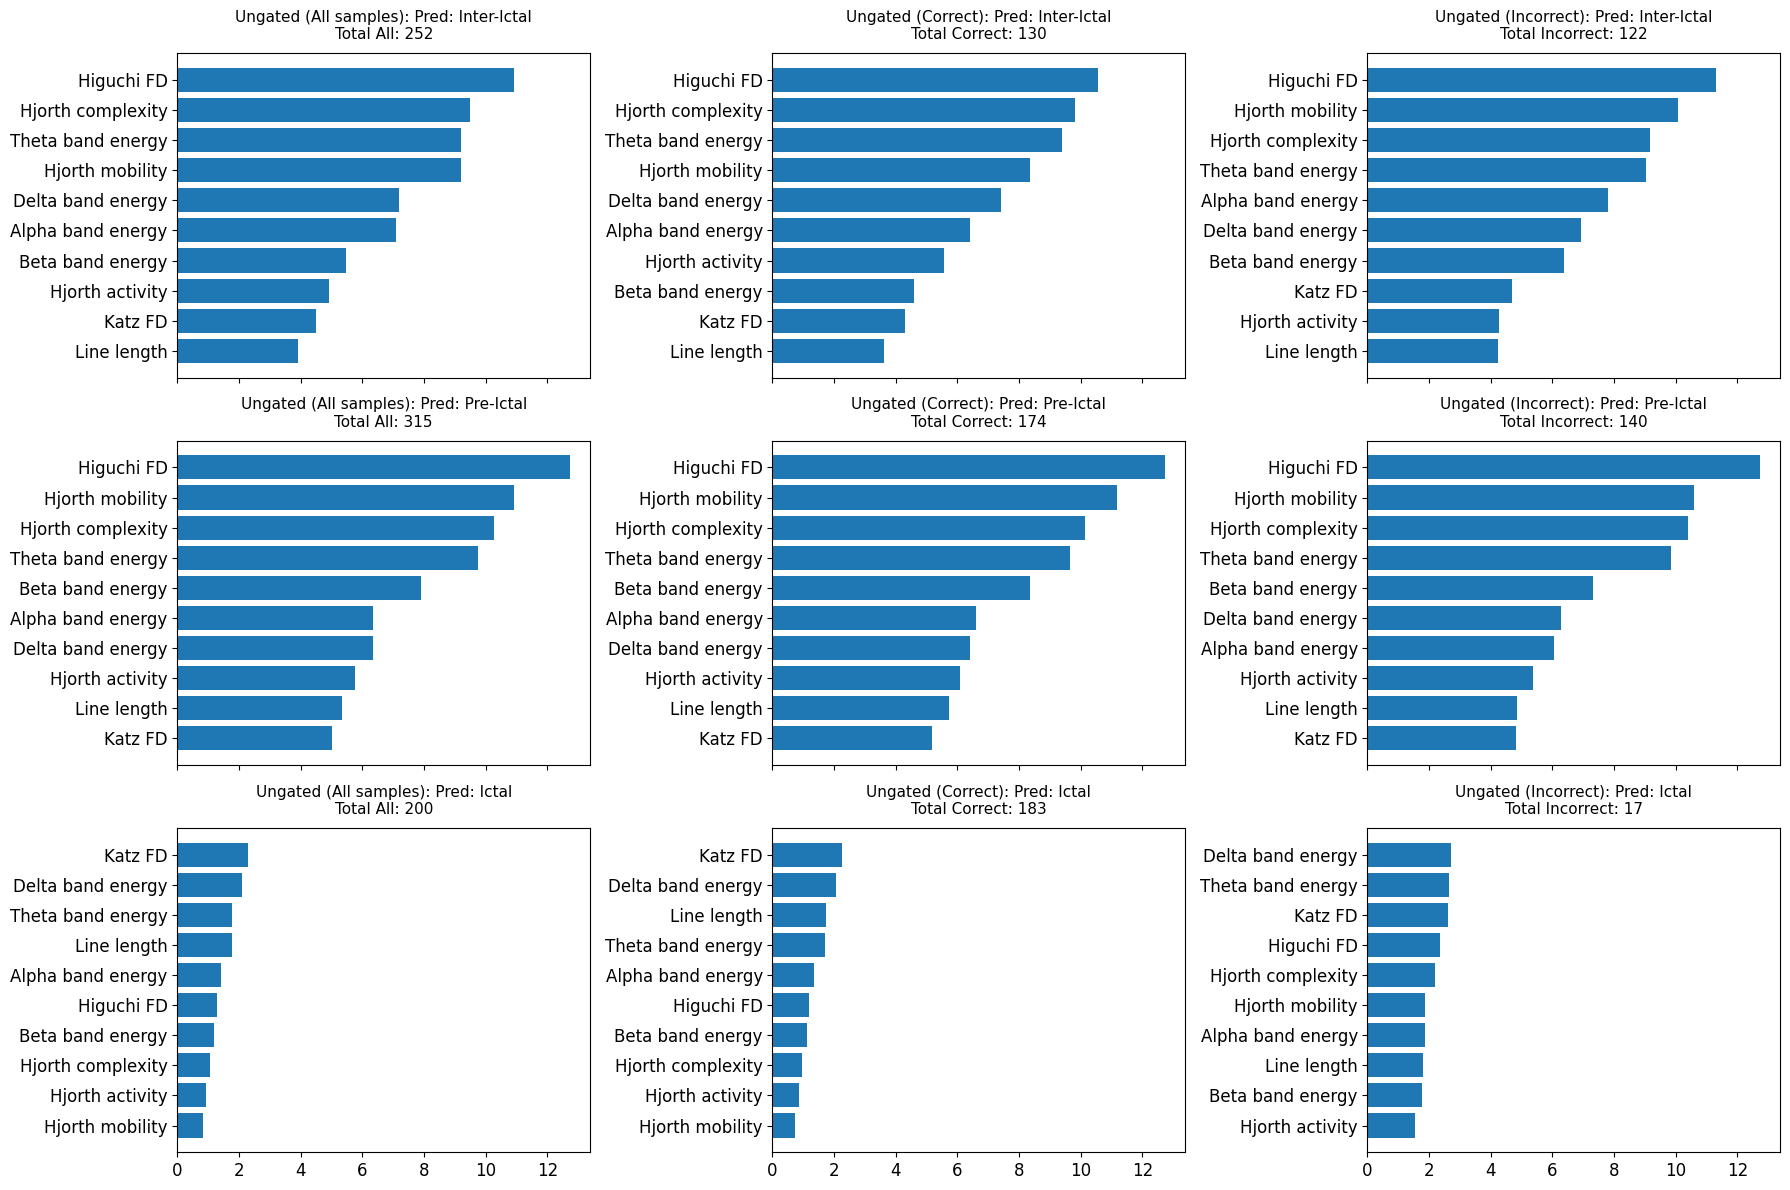


Processing Feature Importances for: chb23
Running MC Dropout processing (Ungated Analysis)...

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (CHB23)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9852                    0.9433   
Pred: Pre-Ictal                    0.9984                    0.9974   
Pred: Ictal                        0.9999                    0.8708   

                   Correct vs Incorrect  
Pred: Inter-Ictal                0.8724  
Pred: Pre-Ictal                  0.9917  
Pred: Ictal                      0.8646  

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (CHB23)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9879                    0.9273   
Pred: Pre-Ictal                    1.0000                    0.9879   
Pred: Ictal                        1.0000                    0.9152   

                   Correct vs Incorrect  
Pred: In

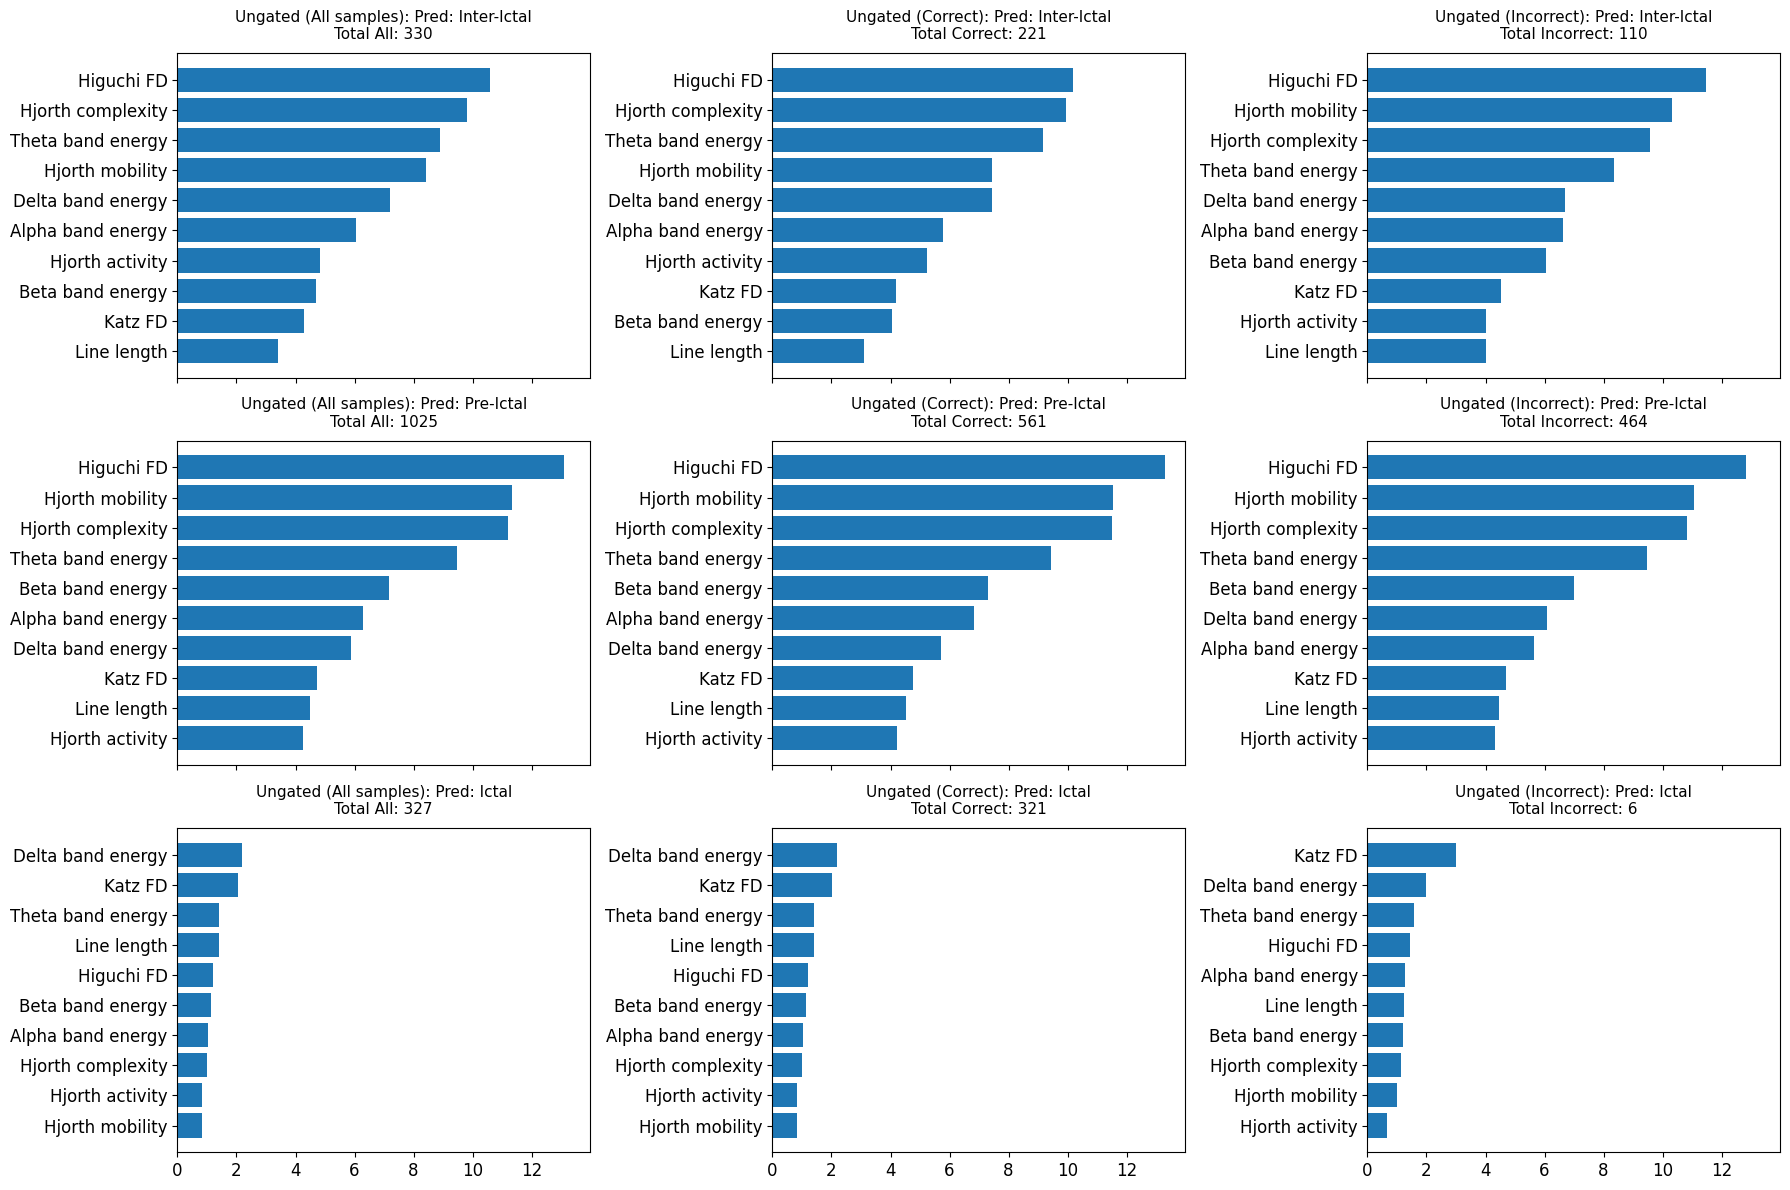


Processing Feature Importances for: chb24
Running MC Dropout processing (Ungated Analysis)...

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (CHB24)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9911                    0.9888   
Pred: Pre-Ictal                    0.9971                    0.9950   
Pred: Ictal                        0.9986                    0.7506   

                   Correct vs Incorrect  
Pred: Inter-Ictal                0.9600  
Pred: Pre-Ictal                  0.9846  
Pred: Ictal                      0.7139  

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (CHB24)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9879                    0.9758   
Pred: Pre-Ictal                    0.9758                    0.9758   
Pred: Ictal                        0.9758                    0.7091   

                   Correct vs Incorrect  
Pred: In

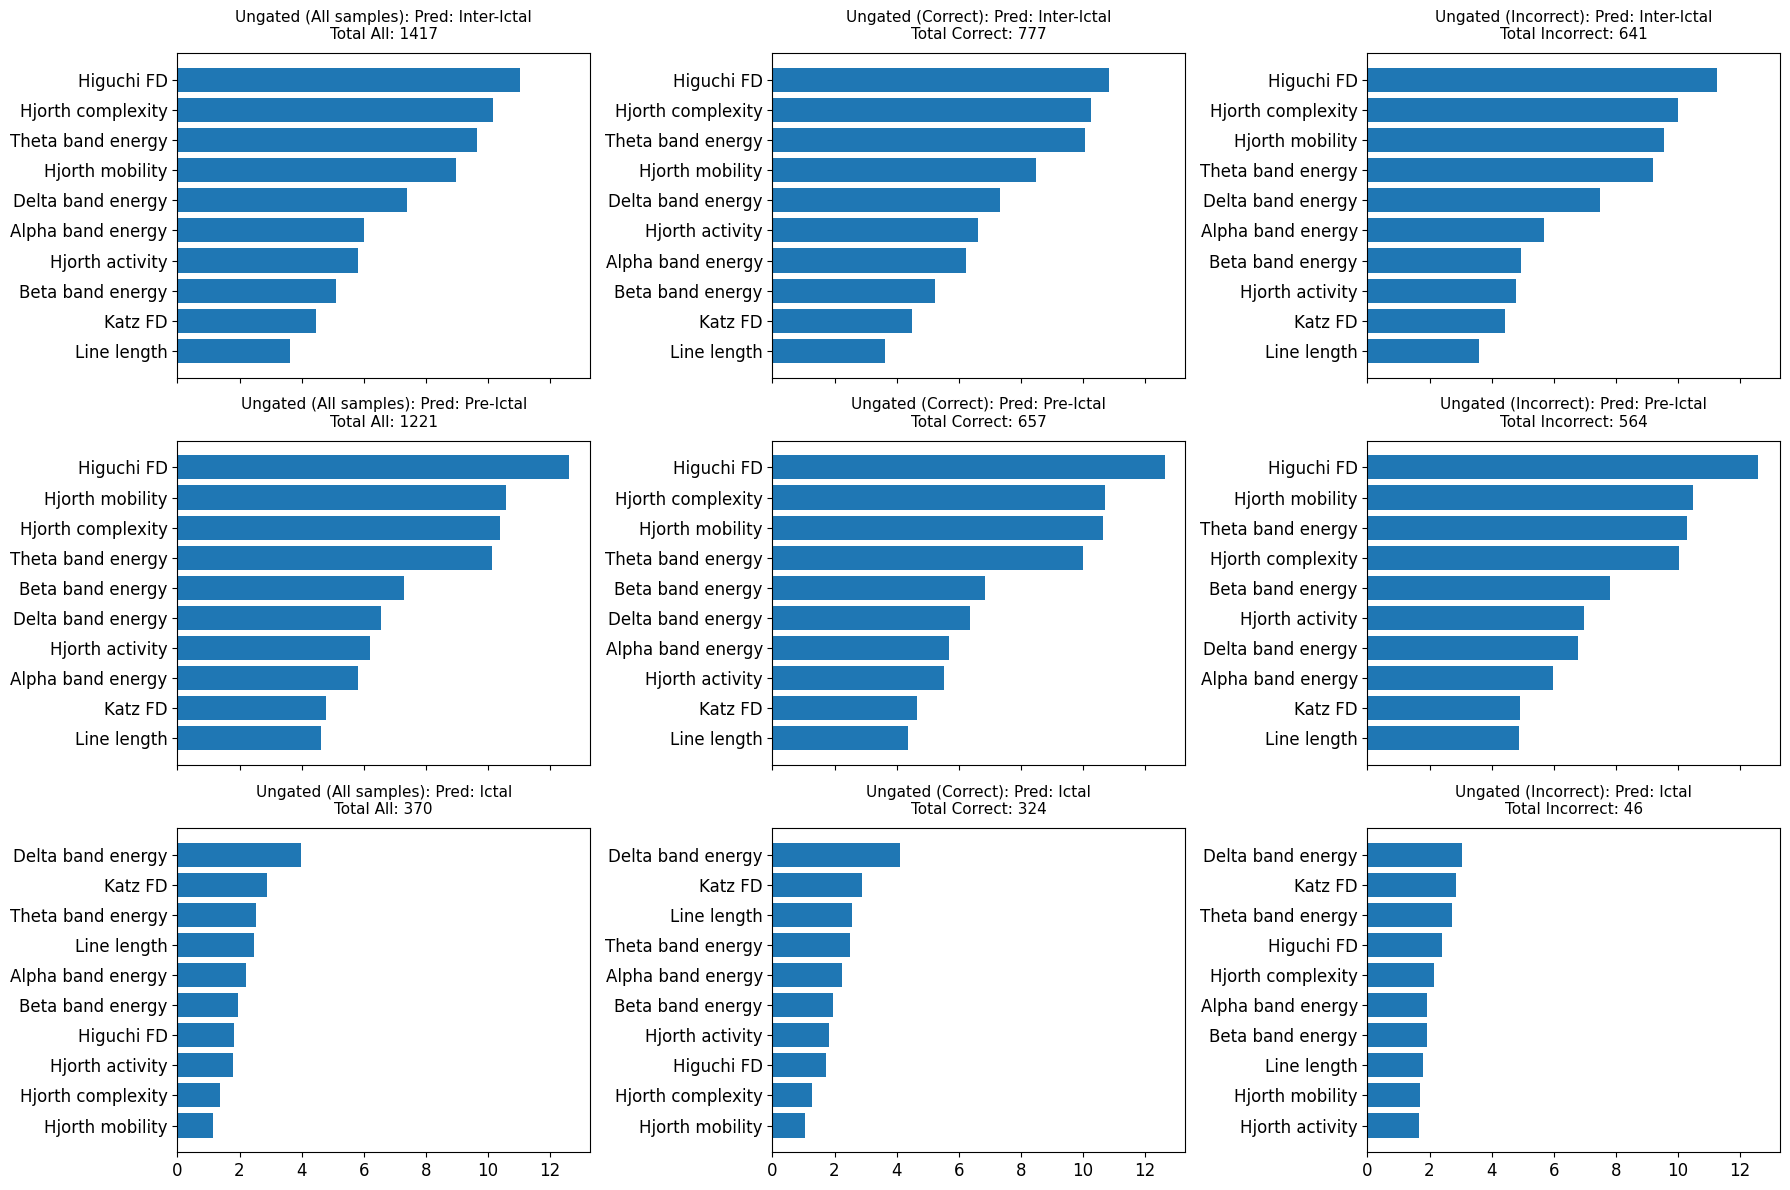

In [ ]:
import os
import json
import ast
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
LOOKBACK = 600

# Base Directories for OOD
DIR_DROPOUT_OOD = "/mc-dropout-node-mask/save_node_mask_ood"
DIR_DROPOUT_UNC_OOD = "/dropout-results/save_unc_metrics_ood"

SAVE_DIR_PLOTS = f"/plots/feature_importances_ood_ungated"

FEATURE_LABELS = np.array([
    'Hjorth activity', 'Hjorth mobility', 'Hjorth complexity',
    "Line length", "Katz FD", "Higuchi FD", "Delta band energy",
    "Theta band energy", "Alpha band energy", "Beta band energy"
])

os.makedirs(SAVE_DIR_PLOTS, exist_ok=True)

# ==========================================
# FEATURE CORRELATION METRICS
# ==========================================
def compute_feature_correlation(arr1, arr2):
    """Computes Pearson and Spearman correlation between two feature importance arrays."""
    if np.std(arr1) == 0 or np.std(arr2) == 0:
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(all_list, correct_list, incorrect_list, save_dir, display_name):
    """Calculates and saves feature importance correlations as Pandas DataFrames per patient."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1] 
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_ac, s_ac = compute_feature_correlation(all_list[i], correct_list[i])
        p_ai, s_ai = compute_feature_correlation(all_list[i], incorrect_list[i])
        p_ci, s_ci = compute_feature_correlation(correct_list[i], incorrect_list[i])
        
        pearson_dict[cls] = {
            "All samples vs Correct": round(p_ac, 4),
            "All samples vs Incorrect": round(p_ai, 4),
            "Correct vs Incorrect": round(p_ci, 4)
        }
        
        spearman_dict[cls] = {
            "All samples vs Correct": round(s_ac, 4),
            "All samples vs Incorrect": round(s_ai, 4),
            "Correct vs Incorrect": round(s_ci, 4)
        }
    
    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*60)
    print(f"PEARSON CORRELATION METRICS - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*60)
    print(df_pearson)
    
    print("\n" + "="*60)
    print(f"SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*60)
    print(df_spearman)
    print("\n")
    
    # Save as CSVs with patient name
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_{display_name}.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, f"feature_correlation_metrics_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics - {display_name.upper()}\n")
        f.write("="*60 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir} for {display_name}")
    
    return df_pearson, df_spearman

# ==========================================
# PLOTTING HELPER FUNCTIONS
# ==========================================
def show_importances(scores, labels, ax, title=""):
    """Plots a horizontal bar chart of feature importances."""
    fontsize = 12
    sorted_indices = np.argsort(scores)
    sorted_scores = scores[sorted_indices]
    sorted_labels = labels[sorted_indices]

    ax.barh(range(len(sorted_scores)), sorted_scores)
    ax.set_yticks(range(len(sorted_scores)), sorted_labels)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.set_title(title, fontsize=11, pad=10)

def render_unified_feature_graphs(all_imp, correct_imp, incorrect_imp, save_path, display_name, all_stats, correct_stats, incorrect_stats):
    """Renders a 3x3 grid: Rows=Classes, Cols=[All, Correct, Incorrect]."""
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), sharex=True)
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    for i in range(3):
        # Column 0: All samples
        show_importances(all_imp[i], FEATURE_LABELS, axes[i, 0], 
                         title=f"Ungated (All samples): {classes[i]}\n{all_stats[i]}")
        # Column 1: Correct
        show_importances(correct_imp[i], FEATURE_LABELS, axes[i, 1], 
                         title=f"Ungated (Correct): {classes[i]}\n{correct_stats[i]}")
        # Column 2: Incorrect
        show_importances(incorrect_imp[i], FEATURE_LABELS, axes[i, 2], 
                         title=f"Ungated (Incorrect): {classes[i]}\n{incorrect_stats[i]}")

    plt.tight_layout()
    fig.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show() 
    plt.close()


# ==========================================
# MC DROPOUT PROCESSING 
# ==========================================

def process_mc_dropout(mask_dir, unc_dir, target_file, unc_file, is_ood):
    """Cross-references PT masks with NPZ metrics, processes total ungated averages, and splits by correctness."""
    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Accumulators [18 nodes, 10 features]
    all_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    correct_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    incorrect_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Counters (Tracking based on predicted labels)
    count_all = {0: 0, 1: 0, 2: 0}       
    count_correct = {0: 0, 1: 0, 2: 0}
    count_incorrect = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        pred_labels = unc_data["pred_labels"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            mask = sample["node_mask_base"] 
            
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            
            # Accumulate All
            count_all[pred_label] += 1
            all_masks[pred_label] += mask
            
            # Check correctness split
            if is_correct:
                correct_masks[pred_label] += mask
                count_correct[pred_label] += 1
            else:
                incorrect_masks[pred_label] += mask
                count_incorrect[pred_label] += 1

    # Average masks, then sum across 18 nodes (dim=0) to get 10 features
    final_all = [
        (all_masks[2] / max(1, count_all[2])).sum(dim=0).numpy(), 
        (all_masks[0] / max(1, count_all[0])).sum(dim=0).numpy(), 
        (all_masks[1] / max(1, count_all[1])).sum(dim=0).numpy()  
    ]

    final_correct = [
        (correct_masks[2] / max(1, count_correct[2])).sum(dim=0).numpy(), 
        (correct_masks[0] / max(1, count_correct[0])).sum(dim=0).numpy(), 
        (correct_masks[1] / max(1, count_correct[1])).sum(dim=0).numpy()  
    ]
    
    final_incorrect = [
        (incorrect_masks[2] / max(1, count_incorrect[2])).sum(dim=0).numpy(),
        (incorrect_masks[0] / max(1, count_incorrect[0])).sum(dim=0).numpy(),
        (incorrect_masks[1] / max(1, count_incorrect[1])).sum(dim=0).numpy()
    ]
    
    # -------------------------------------------------------------------------
    # SCALE LOGIC: Apply 10x division scaling for OOD counts
    # -------------------------------------------------------------------------
    def scale_down(num): 
        return math.floor((num / 10.0) + 0.5) if is_ood else num
    
    all_stats = [
        f"Total All: {scale_down(count_all[2])}" if count_all[2] > 0 else "N/A",
        f"Total All: {scale_down(count_all[0])}" if count_all[0] > 0 else "N/A",
        f"Total All: {scale_down(count_all[1])}" if count_all[1] > 0 else "N/A"
    ]

    correct_stats = [
        f"Total Correct: {scale_down(count_correct[2])}" if count_correct[2] > 0 else "N/A",
        f"Total Correct: {scale_down(count_correct[0])}" if count_correct[0] > 0 else "N/A",
        f"Total Correct: {scale_down(count_correct[1])}" if count_correct[1] > 0 else "N/A"
    ]
    
    incorrect_stats = [
        f"Total Incorrect: {scale_down(count_incorrect[2])}" if count_incorrect[2] > 0 else "N/A",
        f"Total Incorrect: {scale_down(count_incorrect[0])}" if count_incorrect[0] > 0 else "N/A",
        f"Total Incorrect: {scale_down(count_incorrect[1])}" if count_incorrect[1] > 0 else "N/A"
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# EXECUTION PIPELINE
# ==========================================
def run_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    target_file = f"{target_name}.pt" if is_ood else "test_data.pt"
    unc_file = f"{target_name}_per_sample_data.npz" if is_ood else "per_sample_data.npz"
    display_name = target_name if is_ood else "ID_Data"
    
    print(f"\n{'='*50}\nProcessing Feature Importances for: {display_name}\n{'='*50}")
    print("Running MC Dropout processing (Ungated Analysis)...")
    try:
        all_imp, correct_imp, incorrect_imp, all_stats, correct_stats, incorrect_stats = process_mc_dropout(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            target_file=target_file,
            unc_file=unc_file,
            is_ood=is_ood
        )
        
        if all_imp is not None:
            # Calculate and save the feature correlations
            save_feature_metrics(
                all_list=all_imp, 
                correct_list=correct_imp, 
                incorrect_list=incorrect_imp, 
                save_dir=SAVE_DIR_PLOTS, 
                display_name=display_name
            )
            
            # Generate the unified 3x3 plot 
            render_unified_feature_graphs(
                all_imp=all_imp, 
                correct_imp=correct_imp, 
                incorrect_imp=incorrect_imp,
                save_path=os.path.join(SAVE_DIR_PLOTS, f"unified_feature_importances_{display_name}.pdf"),
                display_name=display_name,
                all_stats=all_stats, 
                correct_stats=correct_stats, 
                incorrect_stats=incorrect_stats
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {display_name}: {e}")

if __name__ == "__main__":
    
    # 2. Run strictly for OOD Data
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    for patient in OOD_PATIENTS:
        run_analysis(
            mc_dir=DIR_DROPOUT_OOD, 
            unc_dir=DIR_DROPOUT_UNC_OOD, 
            target_name=patient, 
            is_ood=True
        )

## GNNExplainer - OOD (Gated All samples vs Gated (Correct) Vs Gated (Incorrect)


Processing Feature Importances for: chb22
Running MC Dropout processing (Gated Analysis)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (CHB22)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9782                    0.9706   
Pred: Pre-Ictal                    0.9977                    0.9970   
Pred: Ictal                        0.9995                    0.7766   

                   Correct vs Incorrect  
Pred: Inter-Ictal                0.8995  
Pred: Pre-Ictal                  0.9894  
Pred: Ictal                      0.7555  

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (CHB22)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9879                    0.9152   
Pred: Pre-Ictal                    1.0000                    0.9879   
Pred: Ictal                        1.0000                    0.7

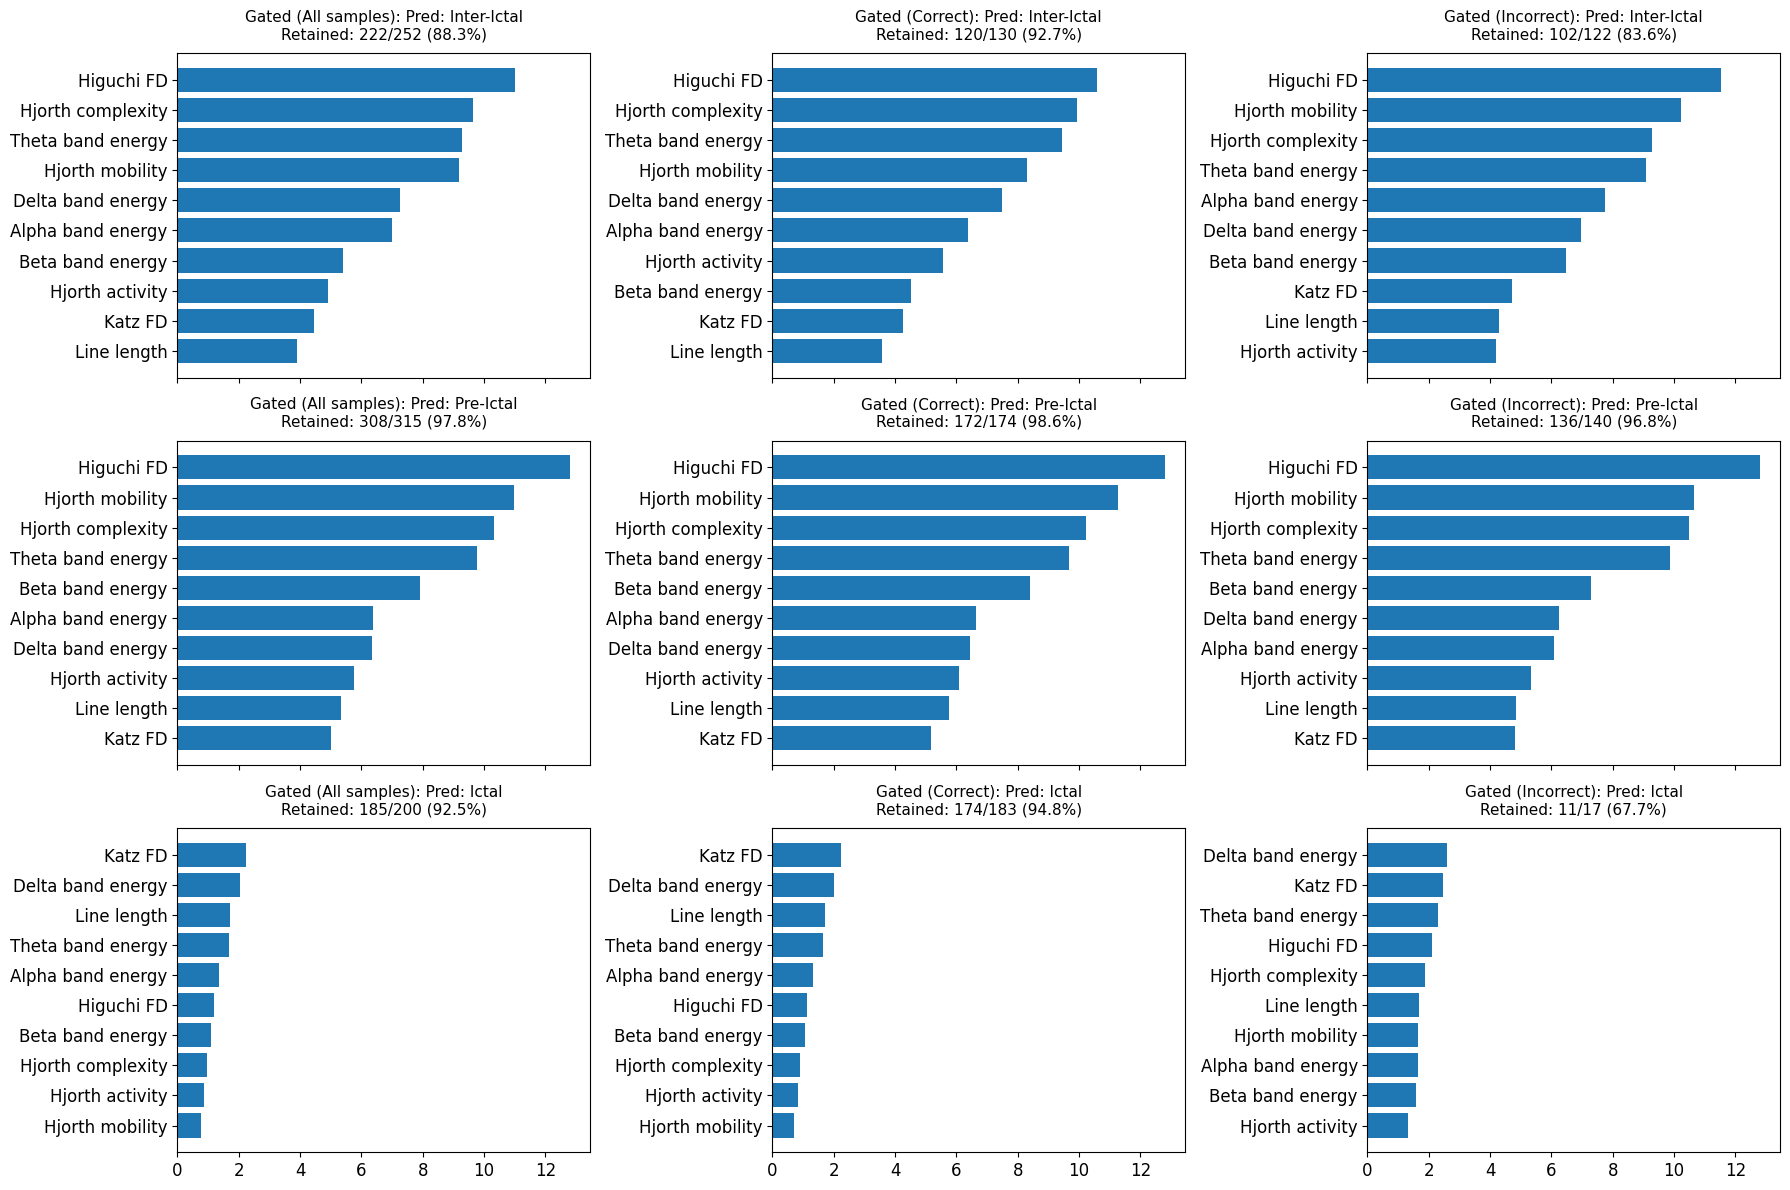


Processing Feature Importances for: chb23
Running MC Dropout processing (Gated Analysis)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (CHB23)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9848                    0.9384   
Pred: Pre-Ictal                    0.9987                    0.9977   
Pred: Ictal                        1.0000                    0.9008   

                   Correct vs Incorrect  
Pred: Inter-Ictal                0.8640  
Pred: Pre-Ictal                  0.9928  
Pred: Ictal                      0.8968  

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (CHB23)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9758                    0.8788   
Pred: Pre-Ictal                    1.0000                    0.9879   
Pred: Ictal                        1.0000                    0.9

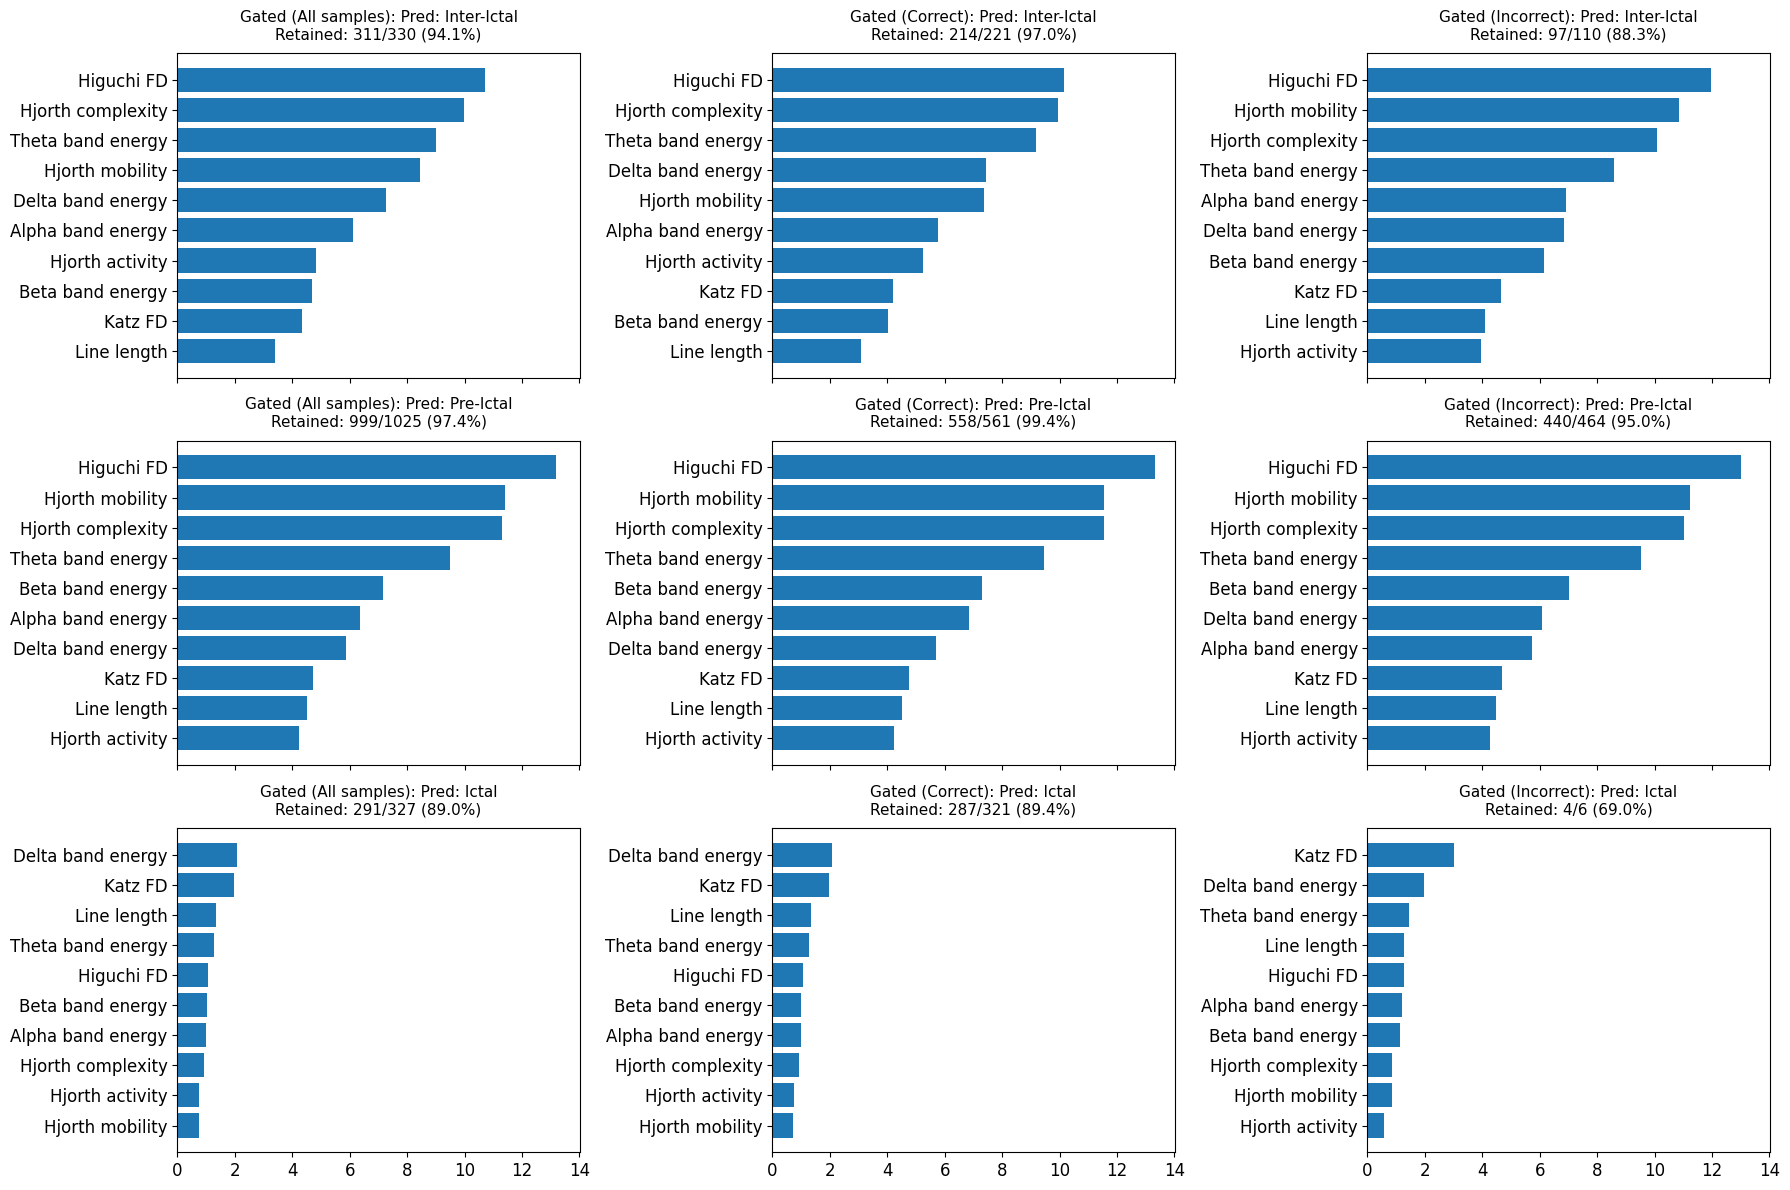


Processing Feature Importances for: chb24
Running MC Dropout processing (Gated Analysis)...
Applying Uncertainty Gate with threshold tau = 0.1483899914

PEARSON CORRELATION METRICS - FEATURE IMPORTANCE (CHB24)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9913                    0.9894   
Pred: Pre-Ictal                    0.9975                    0.9957   
Pred: Ictal                        0.9997                    0.8605   

                   Correct vs Incorrect  
Pred: Inter-Ictal                0.9616  
Pred: Pre-Ictal                  0.9865  
Pred: Ictal                      0.8482  

SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE (CHB24)
                   All samples vs Correct  All samples vs Incorrect  \
Pred: Inter-Ictal                  0.9879                    0.9758   
Pred: Pre-Ictal                    0.9758                    0.9758   
Pred: Ictal                        1.0000                    0.7

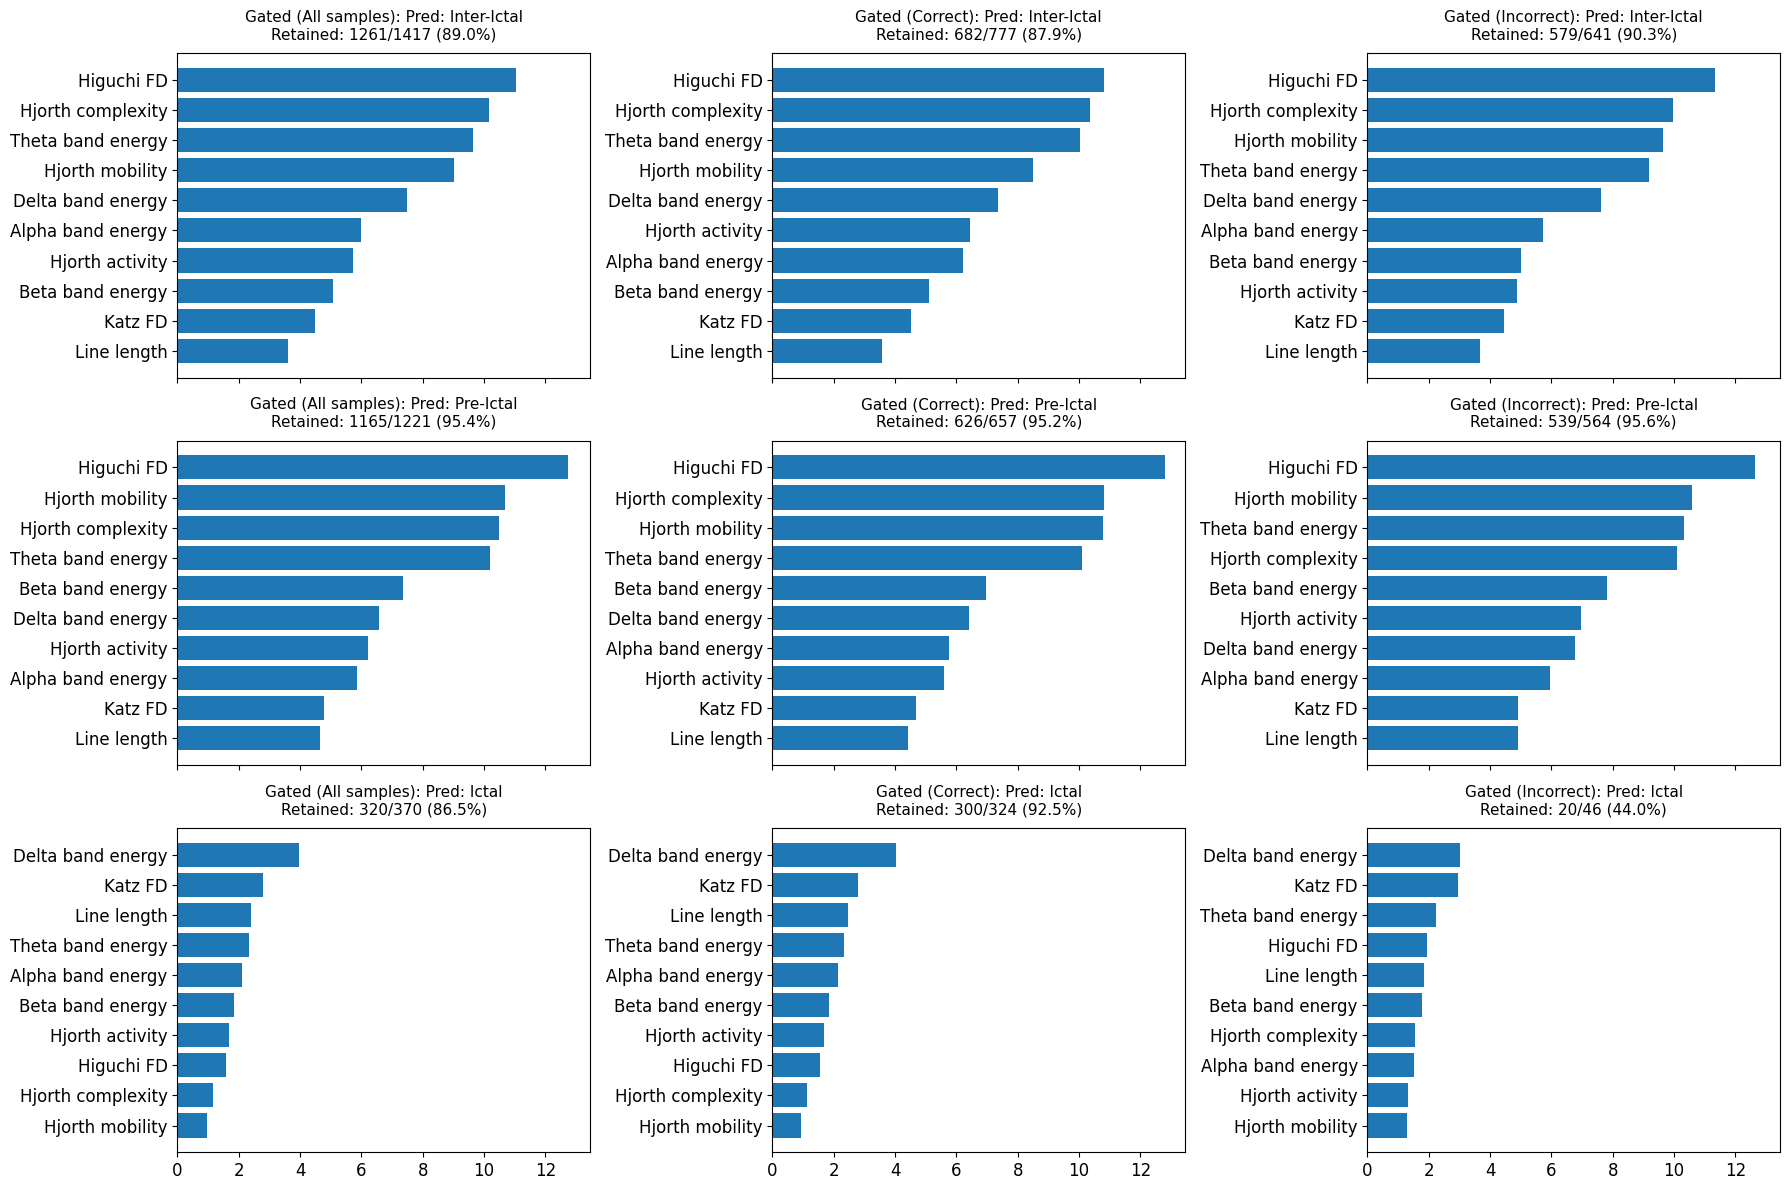

In [ ]:
import os
import json
import ast
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
import scipy.stats as stats
import pandas as pd

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
LOOKBACK = 600

# Base Directories for OOD
DIR_DROPOUT_OOD = "/mc-dropout-node-mask/save_node_mask_ood"
DIR_DROPOUT_UNC_OOD = "/dropout-results/save_unc_metrics_ood"

THRESHOLD_FILE = "/epistemic_threshold.txt"
SAVE_DIR_PLOTS = f"/plots/feature_importances_ood_gated"

FEATURE_LABELS = np.array([
    'Hjorth activity', 'Hjorth mobility', 'Hjorth complexity',
    "Line length", "Katz FD", "Higuchi FD", "Delta band energy",
    "Theta band energy", "Alpha band energy", "Beta band energy"
])

os.makedirs(SAVE_DIR_PLOTS, exist_ok=True)

# ==========================================
# FEATURE CORRELATION METRICS
# ==========================================
def compute_feature_correlation(arr1, arr2):
    """Computes Pearson and Spearman correlation between two feature importance arrays."""
    if np.std(arr1) == 0 or np.std(arr2) == 0:
        return 0.0, 0.0
    
    pearson_corr, _ = stats.pearsonr(arr1, arr2)
    spearman_corr, _ = stats.spearmanr(arr1, arr2)
    
    return pearson_corr, spearman_corr

def save_feature_metrics(all_list, correct_list, incorrect_list, save_dir, display_name):
    """Calculates and saves feature importance correlations as Pandas DataFrames per patient."""
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    keys = [2, 0, 1] 
    
    os.makedirs(save_dir, exist_ok=True)
    
    pearson_dict = {}
    spearman_dict = {}
    
    for i, cls in enumerate(classes):
        p_ac, s_ac = compute_feature_correlation(all_list[i], correct_list[i])
        p_ai, s_ai = compute_feature_correlation(all_list[i], incorrect_list[i])
        p_ci, s_ci = compute_feature_correlation(correct_list[i], incorrect_list[i])
        
        pearson_dict[cls] = {
            "All samples vs Correct": round(p_ac, 4),
            "All samples vs Incorrect": round(p_ai, 4),
            "Correct vs Incorrect": round(p_ci, 4)
        }
        
        spearman_dict[cls] = {
            "All samples vs Correct": round(s_ac, 4),
            "All samples vs Incorrect": round(s_ai, 4),
            "Correct vs Incorrect": round(s_ci, 4)
        }
    
    # Create DataFrames
    df_pearson = pd.DataFrame.from_dict(pearson_dict, orient='index')
    df_spearman = pd.DataFrame.from_dict(spearman_dict, orient='index')
    
    # Print the DataFrames
    print("\n" + "="*60)
    print(f"PEARSON CORRELATION METRICS - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*60)
    print(df_pearson)
    
    print("\n" + "="*60)
    print(f"SPEARMAN CORRELATION METRICS - FEATURE IMPORTANCE ({display_name.upper()})")
    print("="*60)
    print(df_spearman)
    print("\n")
    
    # Save as CSVs with patient name
    df_pearson.to_csv(os.path.join(save_dir, f"pearson_metrics_features_{display_name}.csv"))
    df_spearman.to_csv(os.path.join(save_dir, f"spearman_metrics_features_{display_name}.csv"))
    
    # Save as a formatted text file
    with open(os.path.join(save_dir, f"feature_correlation_metrics_{display_name}.txt"), 'w') as f:
        f.write(f"Feature Importance Correlation Metrics - {display_name.upper()}\n")
        f.write("="*60 + "\n\n")
        f.write("--- Pearson Correlation ---\n")
        f.write(df_pearson.to_string())
        f.write("\n\n--- Spearman Correlation ---\n")
        f.write(df_spearman.to_string())
        
    print(f"Feature correlation metrics saved as tables to: {save_dir} for {display_name}")
    
    return df_pearson, df_spearman

# ==========================================
# PLOTTING HELPER FUNCTIONS
# ==========================================
def show_importances(scores, labels, ax, title=""):
    """Plots a horizontal bar chart of feature importances."""
    fontsize = 12
    sorted_indices = np.argsort(scores)
    sorted_scores = scores[sorted_indices]
    sorted_labels = labels[sorted_indices]

    ax.barh(range(len(sorted_scores)), sorted_scores)
    ax.set_yticks(range(len(sorted_scores)), sorted_labels)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.set_title(title, fontsize=11, pad=10)

def render_unified_feature_graphs(all_imp, correct_imp, incorrect_imp, save_path, display_name, all_stats, correct_stats, incorrect_stats):
    """Renders a 3x3 grid: Rows=Classes, Cols=[All, Correct, Incorrect]."""
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), sharex=True)
    classes = ["Pred: Inter-Ictal", "Pred: Pre-Ictal", "Pred: Ictal"]
    
    for i in range(3):
        # Column 0: All samples
        show_importances(all_imp[i], FEATURE_LABELS, axes[i, 0], 
                         title=f"Gated (All samples): {classes[i]}\n{all_stats[i]}")
        # Column 1: Correct
        show_importances(correct_imp[i], FEATURE_LABELS, axes[i, 1], 
                         title=f"Gated (Correct): {classes[i]}\n{correct_stats[i]}")
        # Column 2: Incorrect
        show_importances(incorrect_imp[i], FEATURE_LABELS, axes[i, 2], 
                         title=f"Gated (Incorrect): {classes[i]}\n{incorrect_stats[i]}")

    plt.tight_layout()
    fig.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show() 
    plt.close()

# ==========================================
# MC DROPOUT PROCESSING 
# ==========================================

def process_mc_dropout(mask_dir, unc_dir, threshold_file, target_file, unc_file, is_ood):
    """Cross-references PT masks with NPZ metrics, applies uncertainty gating, and splits by correctness."""
    if not os.path.exists(threshold_file):
        raise FileNotFoundError(f"Cannot find threshold file at: {threshold_file}")
        
    with open(threshold_file, "r") as f:
        tau = float(f.read().strip())
        
    print(f"Applying Uncertainty Gate with threshold tau = {tau:.10f}")

    folds = sorted([f for f in os.listdir(mask_dir) if f.startswith("fold_")])
    
    # Accumulators [18 nodes, 10 features]
    all_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    correct_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    incorrect_masks = {0: torch.zeros(18, 10), 1: torch.zeros(18, 10), 2: torch.zeros(18, 10)}
    
    # Ungated Counters (for percentage tracking)
    count_all_ungated = {0: 0, 1: 0, 2: 0}       
    count_correct_ungated = {0: 0, 1: 0, 2: 0}
    count_incorrect_ungated = {0: 0, 1: 0, 2: 0}

    # Gated Counters (Tracking based on predicted labels)
    count_all_gated = {0: 0, 1: 0, 2: 0}       
    count_correct_gated = {0: 0, 1: 0, 2: 0}
    count_incorrect_gated = {0: 0, 1: 0, 2: 0}
    
    for fold in folds:
        pt_path = os.path.join(mask_dir, fold, target_file)
        npz_path = os.path.join(unc_dir, fold, unc_file)
        
        if not os.path.exists(pt_path) or not os.path.exists(npz_path): 
            continue
            
        samples = torch.load(pt_path, weights_only=False)
        unc_data = np.load(npz_path)
        
        pred_labels = unc_data["pred_labels"]
        epistemic_arr = unc_data["epistemic_entropy"]
        
        for i, sample in enumerate(samples):
            true_label = sample["true_label"]
            mask = sample["node_mask_base"] 
            
            pred_label = pred_labels[i]
            is_correct = (pred_label == true_label)
            
            # Accumulate Ungated Pre-Gate counts for percentage baseline
            count_all_ungated[pred_label] += 1
            if is_correct:
                count_correct_ungated[pred_label] += 1
            else:
                count_incorrect_ungated[pred_label] += 1

            # Apply Uncertainty Gate
            if epistemic_arr[i] >= tau:
                continue

            # Accumulate Gated All
            count_all_gated[pred_label] += 1
            all_masks[pred_label] += mask
            
            # Check correctness split post-gate
            if is_correct:
                correct_masks[pred_label] += mask
                count_correct_gated[pred_label] += 1
            else:
                incorrect_masks[pred_label] += mask
                count_incorrect_gated[pred_label] += 1

    # Average masks, then sum across 18 nodes (dim=0) to get 10 features
    final_all = [
        (all_masks[2] / max(1, count_all_gated[2])).sum(dim=0).numpy(), 
        (all_masks[0] / max(1, count_all_gated[0])).sum(dim=0).numpy(), 
        (all_masks[1] / max(1, count_all_gated[1])).sum(dim=0).numpy()  
    ]

    final_correct = [
        (correct_masks[2] / max(1, count_correct_gated[2])).sum(dim=0).numpy(), 
        (correct_masks[0] / max(1, count_correct_gated[0])).sum(dim=0).numpy(), 
        (correct_masks[1] / max(1, count_correct_gated[1])).sum(dim=0).numpy()  
    ]
    
    final_incorrect = [
        (incorrect_masks[2] / max(1, count_incorrect_gated[2])).sum(dim=0).numpy(),
        (incorrect_masks[0] / max(1, count_incorrect_gated[0])).sum(dim=0).numpy(),
        (incorrect_masks[1] / max(1, count_incorrect_gated[1])).sum(dim=0).numpy()
    ]
    
    # -------------------------------------------------------------------------
    # SCALE LOGIC: Apply 10x division scaling for OOD counts
    # -------------------------------------------------------------------------
    def scale_down(num): 
        return math.floor((num / 10.0) + 0.5) if is_ood else num

    def format_retained_stats(gated, ungated):
        g = scale_down(gated)
        u = scale_down(ungated)
        if u == 0:
            return "N/A"
        return f"Retained: {g}/{u} ({(gated/max(1, ungated))*100:.1f}%)"
    
    all_stats = [
        format_retained_stats(count_all_gated[2], count_all_ungated[2]),
        format_retained_stats(count_all_gated[0], count_all_ungated[0]),
        format_retained_stats(count_all_gated[1], count_all_ungated[1])
    ]

    correct_stats = [
        format_retained_stats(count_correct_gated[2], count_correct_ungated[2]),
        format_retained_stats(count_correct_gated[0], count_correct_ungated[0]),
        format_retained_stats(count_correct_gated[1], count_correct_ungated[1])
    ]
    
    incorrect_stats = [
        format_retained_stats(count_incorrect_gated[2], count_incorrect_ungated[2]),
        format_retained_stats(count_incorrect_gated[0], count_incorrect_ungated[0]),
        format_retained_stats(count_incorrect_gated[1], count_incorrect_ungated[1])
    ]
    
    return final_all, final_correct, final_incorrect, all_stats, correct_stats, incorrect_stats

# ==========================================
# EXECUTION PIPELINE
# ==========================================
def run_analysis(mc_dir, unc_dir, target_name="", is_ood=False):
    target_file = f"{target_name}.pt" if is_ood else "test_data.pt"
    unc_file = f"{target_name}_per_sample_data.npz" if is_ood else "per_sample_data.npz"
    display_name = target_name if is_ood else "ID_Data"
    
    print(f"\n{'='*50}\nProcessing Feature Importances for: {display_name}\n{'='*50}")
    print("Running MC Dropout processing (Gated Analysis)...")
    try:
        all_imp, correct_imp, incorrect_imp, all_stats, correct_stats, incorrect_stats = process_mc_dropout(
            mask_dir=mc_dir, 
            unc_dir=unc_dir, 
            threshold_file=THRESHOLD_FILE,
            target_file=target_file,
            unc_file=unc_file,
            is_ood=is_ood
        )
        
        if all_imp is not None:
            # Calculate and save the feature correlations
            save_feature_metrics(
                all_list=all_imp, 
                correct_list=correct_imp, 
                incorrect_list=incorrect_imp, 
                save_dir=SAVE_DIR_PLOTS, 
                display_name=display_name
            )
            
            # Generate the unified 3x3 plot 
            render_unified_feature_graphs(
                all_imp=all_imp, 
                correct_imp=correct_imp, 
                incorrect_imp=incorrect_imp,
                save_path=os.path.join(SAVE_DIR_PLOTS, f"unified_feature_importances_{display_name}.pdf"),
                display_name=display_name,
                all_stats=all_stats, 
                correct_stats=correct_stats, 
                incorrect_stats=incorrect_stats
            )
            
    except Exception as e:
        print(f"Error processing MC Dropout for {display_name}: {e}")

if __name__ == "__main__":
    
    # 2. Run strictly for OOD Data
    OOD_PATIENTS = ["chb22", "chb23", "chb24"]
    for patient in OOD_PATIENTS:
        run_analysis(
            mc_dir=DIR_DROPOUT_OOD, 
            unc_dir=DIR_DROPOUT_UNC_OOD, 
            target_name=patient, 
            is_ood=True
        )

## Ablation Results

### Classification Performance

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define  root directories for the models
MC_TEMP_MODEL_DIR = "/ablation/ablation"
MC_DROPOUT_DIR = "/dropout-results"

# Define the exact JSON filenames based on  script's output
ID_METRICS_FILE = "summary_results.json" # Replace with actual prefix if different
OOD_PATIENTS = ["chb22", "chb23", "chb24"]

def load_and_format_metrics(json_path):
    """Loads JSON metrics and formats them as 'Mean ± Std' in percentages."""
    if not os.path.exists(json_path):
        print(f"Warning: File not found - {json_path}")
        return {}
        
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Multiply by 100 and format to 2 decimal places
    formatted = {
        "AUROC (%)": f"{data['final_mean_AUROC']*100:.2f} ± {data['final_AUROC_std']*100:.2f}",
        "F1-Score (%)": f"{data['final_mean_F1-score']*100:.2f} ± {data['final_F1-score_std']*100:.2f}",
        "Sensitivity (%)": f"{data['final_mean_Sensitivity']*100:.2f} ± {data['final_Sensitivity_std']*100:.2f}",
        "Specificity (%)": f"{data['final_Specificity']*100:.2f} ± {data['final_Specificity_std']*100:.2f}",
        "Balanced Acc (%)": f"{data['final_Balanced Accuracy']*100:.2f} ± {data['final_Balanced Accuracy_std']*100:.2f}"
    }
    return formatted

def build_metrics_tables():
    id_rows = []
    ood_rows = []
    
    models = {
        "MC-Dropout-Temp": MC_TEMP_MODEL_DIR,
        "MC-Dropout": MC_DROPOUT_DIR
    }
    
    for model_name, base_path in models.items():
        # 1. Process ID Data
        id_json_path = os.path.join(base_path, "save_conf_metrics", ID_METRICS_FILE)
        id_metrics = load_and_format_metrics(id_json_path)
        if id_metrics:
            id_metrics["Model"] = model_name
            id_metrics["Evaluation"] = "ID (10-Fold)"
            id_rows.append(id_metrics)
            
        # 2. Process OOD Data
        for patient in OOD_PATIENTS:
            # e.g., summary_results_chb22.json
            ood_json_name = f"{ID_METRICS_FILE.replace('.json', '')}_{patient}.json" 
            ood_json_path = os.path.join(base_path, "save_conf_metrics_ood", ood_json_name)
            
            ood_metrics = load_and_format_metrics(ood_json_path)
            if ood_metrics:
                ood_metrics["Model"] = model_name
                ood_metrics["Evaluation"] = f"{patient}" # Simplified evaluation label for the OOD table
                ood_rows.append(ood_metrics)

    # Define column order
    cols = ["Model", "Evaluation", "AUROC (%)", "F1-Score (%)", "Sensitivity (%)", "Specificity (%)", "Balanced Acc (%)"]
    
    # Create DataFrames
    id_df = pd.DataFrame(id_rows)[cols] if id_rows else pd.DataFrame(columns=cols)
    ood_df = pd.DataFrame(ood_rows)[cols] if ood_rows else pd.DataFrame(columns=cols)
    
    # Optional: Sort OOD table by Patient then Model to make comparisons easier
    if not ood_df.empty:
        ood_df = ood_df.sort_values(by=["Evaluation", "Model"]).reset_index(drop=True)
    
    return id_df, ood_df

# Run and display the tables
id_metrics_df, ood_metrics_df = build_metrics_tables()

print("="*80)
print("TABLE 1: IN-DISTRIBUTION (ID) CLASSIFICATION PERFORMANCE")
print("="*80)
print(id_metrics_df.to_markdown(index=False))
print("\n")

print("="*80)
print("TABLE 2: OUT-OF-DISTRIBUTION (OOD) CLASSIFICATION PERFORMANCE")
print("="*80)
print(ood_metrics_df.to_markdown(index=False))

TABLE 1: IN-DISTRIBUTION (ID) CLASSIFICATION PERFORMANCE
| Model           | Evaluation   | AUROC (%)    | F1-Score (%)   | Sensitivity (%)   | Specificity (%)   | Balanced Acc (%)   |
|:----------------|:-------------|:-------------|:---------------|:------------------|:------------------|:-------------------|
| MC-Dropout-Temp | ID (10-Fold) | 91.39 ± 0.56 | 76.75 ± 1.30   | 76.75 ± 1.30      | 88.38 ± 0.65      | 78.47 ± 1.14       |
| MC-Dropout      | ID (10-Fold) | 91.39 ± 0.56 | 76.75 ± 1.30   | 76.75 ± 1.30      | 88.37 ± 0.65      | 78.47 ± 1.14       |


TABLE 2: OUT-OF-DISTRIBUTION (OOD) CLASSIFICATION PERFORMANCE
| Model           | Evaluation   | AUROC (%)    | F1-Score (%)   | Sensitivity (%)   | Specificity (%)   | Balanced Acc (%)   |
|:----------------|:-------------|:-------------|:---------------|:------------------|:------------------|:-------------------|
| MC-Dropout      | chb22        | 80.51 ± 1.61 | 63.63 ± 2.32   | 63.63 ± 2.32      | 81.81 ± 1.16      | 67.3

### Uncertainty Calibration Performance

In [ ]:
import os
import json
import pandas as pd

# Define  root directories
MC_TEMP_MODEL_DIR = "/ablation/ablation"
MC_DROPOUT_DIR = "/dropout-results"

# Define filenames
ID_UNC_FILE = "summary_unc_results.json"
OOD_PATIENTS = ["chb22", "chb23", "chb24"]

def load_and_format_unc_metrics(json_path):
    """Loads JSON metrics and formats them as 'Mean ± Std' to 3 decimal places."""
    if not os.path.exists(json_path):
        return {}
        
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    formatted = {
        "ECE (↓)": f"{data['final_mean_ECE']:.3f} ± {data['final_ECE_std']:.3f}",
        "NLL (↓)": f"{data['final_mean_NLL']:.3f} ± {data['final_NLL_std']:.3f}",
        "AURC (↓)": f"{data['final_mean_AURC']:.3f} ± {data['final_AURC_std']:.3f}",
        "Total Ent.": f"{data['final_mean_Total_Entropy']:.3f} ± {data['final_Total_Entropy_std']:.3f}",
        "Aleatoric Ent.": f"{data['final_mean_Aleatoric_Entropy']:.3f} ± {data['final_Aleatoric_Entropy_std']:.3f}",
        "Epistemic Ent.": f"{data['final_mean_Epistemic_Entropy']:.3f} ± {data['final_Epistemic_Entropy_std']:.3f}"
    }
    return formatted

def build_uncertainty_tables():
    id_rows, ood_rows = [], []
    models = {"MC-Dropout-Temp": MC_TEMP_MODEL_DIR, "MC-Dropout": MC_DROPOUT_DIR}
    
    for model_name, base_path in models.items():
        # 1. Process ID Data
        id_json_path = os.path.join(base_path, "save_unc_metrics", ID_UNC_FILE)
        id_metrics = load_and_format_unc_metrics(id_json_path)
        if id_metrics:
            id_metrics["Model"] = model_name
            id_metrics["Evaluation"] = "ID (10-Fold)"
            id_rows.append(id_metrics)
            
        # 2. Process OOD Data
        for patient in OOD_PATIENTS:
            ood_json_name = f"{ID_UNC_FILE.replace('.json', '')}_{patient}.json" 
            ood_json_path = os.path.join(base_path, "save_unc_metrics_ood", ood_json_name)
            ood_metrics = load_and_format_unc_metrics(ood_json_path)
            if ood_metrics:
                ood_metrics["Model"] = model_name
                ood_metrics["Evaluation"] = patient
                ood_rows.append(ood_metrics)

    cols = ["Model", "Evaluation", "ECE (↓)", "NLL (↓)", "AURC (↓)", "Total Ent.", "Aleatoric Ent.", "Epistemic Ent."]
    
    id_df = pd.DataFrame(id_rows)[cols] if id_rows else pd.DataFrame(columns=cols)
    ood_df = pd.DataFrame(ood_rows)[cols] if ood_rows else pd.DataFrame(columns=cols)
    
    if not ood_df.empty:
        ood_df = ood_df.sort_values(by=["Evaluation", "Model"]).reset_index(drop=True)
    
    return id_df, ood_df

id_unc_df, ood_unc_df = build_uncertainty_tables()

print("="*100)
print("TABLE 3: IN-DISTRIBUTION (ID) UNCERTAINTY & CALIBRATION")
print("="*100)
print(id_unc_df.to_markdown(index=False))
print("\n")

print("="*100)
print("TABLE 4: OUT-OF-DISTRIBUTION (OOD) UNCERTAINTY & CALIBRATION")
print("="*100)
print(ood_unc_df.to_markdown(index=False))

TABLE 3: IN-DISTRIBUTION (ID) UNCERTAINTY & CALIBRATION
| Model           | Evaluation   | ECE (↓)       | NLL (↓)       | AURC (↓)      | Total Ent.    | Aleatoric Ent.   | Epistemic Ent.   |
|:----------------|:-------------|:--------------|:--------------|:--------------|:--------------|:-----------------|:-----------------|
| MC-Dropout-Temp | ID (10-Fold) | 0.038 ± 0.010 | 0.497 ± 0.015 | 0.085 ± 0.006 | 0.537 ± 0.022 | 0.487 ± 0.025    | 0.049 ± 0.004    |
| MC-Dropout      | ID (10-Fold) | 0.038 ± 0.011 | 0.496 ± 0.016 | 0.085 ± 0.006 | 0.536 ± 0.022 | 0.486 ± 0.026    | 0.050 ± 0.004    |


TABLE 4: OUT-OF-DISTRIBUTION (OOD) UNCERTAINTY & CALIBRATION
| Model           | Evaluation   | ECE (↓)       | NLL (↓)       | AURC (↓)      | Total Ent.    | Aleatoric Ent.   | Epistemic Ent.   |
|:----------------|:-------------|:--------------|:--------------|:--------------|:--------------|:-----------------|:-----------------|
| MC-Dropout      | chb22        | 0.112 ± 0.019 | 0.721 ± 

## Ablation average Uncertainty Performance

In [ ]:
import os
import json
import pandas as pd
import numpy as np

# Define  root directories
MC_TEMP_MODEL_DIR = "/ablation/ablation"
MC_DROPOUT_DIR = "/dropout-results"

# Define filenames
ID_UNC_FILE = "summary_unc_results.json"
OOD_PATIENTS = ["chb22", "chb23", "chb24"]

# Map column names to the exact JSON keys
METRIC_KEYS = {
    "ECE (↓)": ("final_mean_ECE", "final_ECE_std"),
    "NLL (↓)": ("final_mean_NLL", "final_NLL_std"),
    "AURC (↓)": ("final_mean_AURC", "final_AURC_std"),
    "Total Ent.": ("final_mean_Total_Entropy", "final_Total_Entropy_std"),
    "Aleatoric Ent.": ("final_mean_Aleatoric_Entropy", "final_Aleatoric_Entropy_std"),
    "Epistemic Ent.": ("final_mean_Epistemic_Entropy", "final_Epistemic_Entropy_std")
}

def load_raw_json(json_path):
    """Loads raw JSON data without string formatting."""
    if not os.path.exists(json_path):
        return None
    with open(json_path, 'r') as f:
        return json.load(f)

def build_uncertainty_tables():
    id_rows, ood_rows = [], []
    models = {"MC-Dropout-Temp": MC_TEMP_MODEL_DIR, "MC-Dropout": MC_DROPOUT_DIR}
    
    for model_name, base_path in models.items():
        # ==========================================
        # 1. Process ID Data (Single File)
        # ==========================================
        id_json_path = os.path.join(base_path, "save_unc_metrics", ID_UNC_FILE)
        id_data = load_raw_json(id_json_path)
        
        if id_data:
            row = {"Model": model_name, "Evaluation": "ID (10-Fold)"}
            for display_name, (mean_key, std_key) in METRIC_KEYS.items():
                row[display_name] = f"{id_data[mean_key]:.3f} ± {id_data[std_key]:.3f}"
            id_rows.append(row)
            
        # ==========================================
        # 2. Process OOD Data (Average across patients)
        # ==========================================
        ood_patient_data = []
        for patient in OOD_PATIENTS:
            ood_json_name = f"{ID_UNC_FILE.replace('.json', '')}_{patient}.json" 
            ood_json_path = os.path.join(base_path, "save_unc_metrics_ood", ood_json_name)
            
            # Load raw float data for each patient
            data = load_raw_json(ood_json_path)
            if data:
                ood_patient_data.append(data)
        
        # If we successfully loaded patient data, calculate the averages
        if ood_patient_data:
            avg_row = {"Model": model_name, "Evaluation": "OOD (Average)"}
            
            for display_name, (mean_key, std_key) in METRIC_KEYS.items():
                # Calculate the average of the means and stds across all 3 patients
                avg_mean = np.mean([p[mean_key] for p in ood_patient_data])
                avg_std = np.mean([p[std_key] for p in ood_patient_data])
                
                # Format as string for the table
                avg_row[display_name] = f"{avg_mean:.3f} ± {avg_std:.3f}"
                
            ood_rows.append(avg_row)

    # Build DataFrames
    cols = ["Model", "Evaluation"] + list(METRIC_KEYS.keys())
    
    id_df = pd.DataFrame(id_rows, columns=cols)
    ood_df = pd.DataFrame(ood_rows, columns=cols)
    
    return id_df, ood_df

# Generate and print tables
id_unc_df, ood_unc_df = build_uncertainty_tables()

print("="*100)
print("TABLE 3: IN-DISTRIBUTION (ID) UNCERTAINTY & CALIBRATION")
print("="*100)
print(id_unc_df.to_markdown(index=False))
print("\n")

print("="*100)
print("TABLE 4: OUT-OF-DISTRIBUTION (OOD) UNCERTAINTY & CALIBRATION (AVERAGED)")
print("="*100)
print(ood_unc_df.to_markdown(index=False))

TABLE 3: IN-DISTRIBUTION (ID) UNCERTAINTY & CALIBRATION
| Model           | Evaluation   | ECE (↓)       | NLL (↓)       | AURC (↓)      | Total Ent.    | Aleatoric Ent.   | Epistemic Ent.   |
|:----------------|:-------------|:--------------|:--------------|:--------------|:--------------|:-----------------|:-----------------|
| MC-Dropout-Temp | ID (10-Fold) | 0.038 ± 0.010 | 0.497 ± 0.015 | 0.085 ± 0.006 | 0.537 ± 0.022 | 0.487 ± 0.025    | 0.049 ± 0.004    |
| MC-Dropout      | ID (10-Fold) | 0.038 ± 0.011 | 0.496 ± 0.016 | 0.085 ± 0.006 | 0.536 ± 0.022 | 0.486 ± 0.026    | 0.050 ± 0.004    |


TABLE 4: OUT-OF-DISTRIBUTION (OOD) UNCERTAINTY & CALIBRATION (AVERAGED)
| Model           | Evaluation    | ECE (↓)       | NLL (↓)       | AURC (↓)      | Total Ent.    | Aleatoric Ent.   | Epistemic Ent.   |
|:----------------|:--------------|:--------------|:--------------|:--------------|:--------------|:-----------------|:-----------------|
| MC-Dropout-Temp | OOD (Average) | 0.099 ± 0.

## Ablation - average uncertainty performance

In [ ]:
import os
import json
import pandas as pd
import numpy as np

# Define  root directories for the models
MC_TEMP_MODEL_DIR = "/ablation/ablation"
MC_DROPOUT_DIR = "/dropout-results"

# Define the exact JSON filenames based on  script's output
ID_METRICS_FILE = "summary_results.json" 
OOD_PATIENTS = ["chb22", "chb23", "chb24"]

# Map column names to the exact JSON keys based on  original script
METRIC_KEYS = {
    "AUROC (%)": ("final_mean_AUROC", "final_AUROC_std"),
    "F1-Score (%)": ("final_mean_F1-score", "final_F1-score_std"),
    "Sensitivity (%)": ("final_mean_Sensitivity", "final_Sensitivity_std"),
    "Specificity (%)": ("final_Specificity", "final_Specificity_std"),
    "Balanced Acc (%)": ("final_Balanced Accuracy", "final_Balanced Accuracy_std")
}

def load_raw_json(json_path):
    """Loads raw JSON data without string formatting."""
    if not os.path.exists(json_path):
        return None
    with open(json_path, 'r') as f:
        return json.load(f)

def build_metrics_tables():
    id_rows, ood_rows = [], []
    
    models = {
        "MC-Dropout-Temp": MC_TEMP_MODEL_DIR,
        "MC-Dropout": MC_DROPOUT_DIR
    }
    
    for model_name, base_path in models.items():
        # ==========================================
        # 1. Process ID Data (Single File)
        # ==========================================
        id_json_path = os.path.join(base_path, "save_conf_metrics", ID_METRICS_FILE)
        id_data = load_raw_json(id_json_path)
        
        if id_data:
            row = {"Model": model_name, "Evaluation": "ID (10-Fold)"}
            for display_name, (mean_key, std_key) in METRIC_KEYS.items():
                # Multiply by 100 for percentage representation
                row[display_name] = f"{id_data[mean_key]*100:.2f} ± {id_data[std_key]*100:.2f}"
            id_rows.append(row)
            
        # ==========================================
        # 2. Process OOD Data (Average across patients)
        # ==========================================
        ood_patient_data = []
        for patient in OOD_PATIENTS:
            ood_json_name = f"{ID_METRICS_FILE.replace('.json', '')}_{patient}.json" 
            ood_json_path = os.path.join(base_path, "save_conf_metrics_ood", ood_json_name)
            
            # Load raw float data for each patient
            data = load_raw_json(ood_json_path)
            if data:
                ood_patient_data.append(data)
        
        # If we successfully loaded patient data, calculate the averages
        if ood_patient_data:
            avg_row = {"Model": model_name, "Evaluation": "OOD (Average)"}
            
            for display_name, (mean_key, std_key) in METRIC_KEYS.items():
                # Calculate the average of the means and stds across all 3 patients
                avg_mean = np.mean([p[mean_key] for p in ood_patient_data])
                avg_std = np.mean([p[std_key] for p in ood_patient_data])
                
                # Format as string for the table (multiply by 100 for percentages)
                avg_row[display_name] = f"{avg_mean*100:.2f} ± {avg_std*100:.2f}"
                
            ood_rows.append(avg_row)

    # Build DataFrames
    cols = ["Model", "Evaluation"] + list(METRIC_KEYS.keys())
    
    id_df = pd.DataFrame(id_rows, columns=cols)
    ood_df = pd.DataFrame(ood_rows, columns=cols)
    
    return id_df, ood_df

# Run and display the tables
id_metrics_df, ood_metrics_df = build_metrics_tables()

print("="*80)
print("TABLE 1: IN-DISTRIBUTION (ID) CLASSIFICATION PERFORMANCE")
print("="*80)
print(id_metrics_df.to_markdown(index=False))
print("\n")

print("="*80)
print("TABLE 2: OUT-OF-DISTRIBUTION (OOD) CLASSIFICATION PERFORMANCE (AVERAGED)")
print("="*80)
print(ood_metrics_df.to_markdown(index=False))

TABLE 1: IN-DISTRIBUTION (ID) CLASSIFICATION PERFORMANCE
| Model           | Evaluation   | AUROC (%)    | F1-Score (%)   | Sensitivity (%)   | Specificity (%)   | Balanced Acc (%)   |
|:----------------|:-------------|:-------------|:---------------|:------------------|:------------------|:-------------------|
| MC-Dropout-Temp | ID (10-Fold) | 91.39 ± 0.56 | 76.75 ± 1.30   | 76.75 ± 1.30      | 88.38 ± 0.65      | 78.47 ± 1.14       |
| MC-Dropout      | ID (10-Fold) | 91.39 ± 0.56 | 76.75 ± 1.30   | 76.75 ± 1.30      | 88.37 ± 0.65      | 78.47 ± 1.14       |


TABLE 2: OUT-OF-DISTRIBUTION (OOD) CLASSIFICATION PERFORMANCE (AVERAGED)
| Model           | Evaluation    | AUROC (%)    | F1-Score (%)   | Sensitivity (%)   | Specificity (%)   | Balanced Acc (%)   |
|:----------------|:--------------|:-------------|:---------------|:------------------|:------------------|:-------------------|
| MC-Dropout-Temp | OOD (Average) | 80.55 ± 1.59 | 62.55 ± 2.24   | 62.55 ± 2.24      | 81.27 ± 1.